# Beyond BLAST Notebook

In [1]:
using Base.Threads
println("Threads available: ", Threads.nthreads())

Threads available: 8


In [2]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Revise 
using HDF5, NPZ, DataInterpolations, Interpolations, FastChebInterp
using BenchmarkTools, FFTW, FastTransforms, Dates, TOML, Plots, Plots.Measures
using QuadGK, LaTeXStrings, Tullio, StaticArrays, LoopVectorization, LinearAlgebra
using Unitful, SpecialFunctions, DifferentialEquations, Cosmology, NumericalIntegration
using CSV, DataFrames, JSON, OrderedCollections
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)
;

[ Info: Precompiling HDF5 [f67ccb44-e63f-5c2f-98bd-6dc0ccc4ba2f]
[ Info: Precompiling DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0]
Precompiling packages...
   2202.7 ms  ✓ DataInterpolations → DataInterpolationsChainRulesCoreExt
  1 dependency successfully precompiled in 3 seconds. 37 already precompiled.
[ Info: Precompiling DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd]
┌ Warning: Module DataInterpolations with build ID fafbfcfd-5e5b-77e4-f760-a358dbe58c03 is missing from the cache.
│ This may mean DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2022
[ Info: Skipping precompilation since __precompile__(false). Importing DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd].
Precompiling packages...
    794.4 ms  ✓ FastChebInterp
  1 dependency successfully precompiled in 1 seconds. 18 already precompiled.
[ Info: Precompili

#### Including the .jl modules

In [494]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
include("blast_code/src/galaxy_galaxy.jl")
include("blast_code/src/shear_shear.jl")
include("blast_code/src/config.jl")
include("blast_code/src/paths.jl")
include("blast_code/src/plot_config.jl")
using .galaxy_galaxy
using .shear_shear
using .Blast
using .blast_tutorials

#### Defining an output folder for each run

#### Setting run parameters, plot parameters, and grids in k

In [568]:
#sets the paths for the output directories 
paths = setup_output_directories()
append_to_log(paths.output_dir, "=== Run started ===")
#sets up the cosmology grid and returns the parameters
grid_data = setup_cosmology_grid() 
#sets up the plotting theme and returns the parameters
# plot_theme = setup_plot_theme() 
#returns the k grids for the calculations
grids = Blast.generate_k_grids(grid_data.kmin, grid_data.kmax, grid_data.Nk, grid_data.Nkp, grid_data.Nkpp; sorting=false) 
#saves the run parameters in a txt file
params_run = save_run_config(
    paths.output_dir, grid_data.N, 
    grid_data.xmin, grid_data.xmax, grid_data.zmin, grid_data.zmax, grid_data.kmin, grid_data.kmax, 
    grid_data.n_cheb, grid_data.ℓ, grid_data.Nk, grid_data.Nkp, grid_data.Nkpp,
    grid_data.x, grid_data.z, 
    grids.k_grid, grids.kp_grid, grids.kpp_grid, grids.sorting)
;

Folders in place: out/runs/run_2026_07_21_132207, out/runs/run_2026_07_21_132207/plots and out/runs/run_2026_07_21_132207/quantities
Data brought to safety in folder: out/runs/run_2026_07_21_132207


In [569]:
default(
    fontfamily = "Computer Modern",
    titlefontfamily = "Computer Modern",
    legendfontfamily = "Computer Modern"
)

In [570]:
println(grids.k_grid[94])

4.767575994495733


In [571]:
#run parameters
reuse = true #if set to true, the code will load the W_tilde. 
mode = "slow"
# fast -> # Nk = Nkp = Nkpp = 150
# big ->  # Nk = Nkp = Nkpp = 350

"slow"

In [572]:
println("k_grid: ", grids.k_grid[1], " ", grids.k_grid[end])
println("kmin: ", grid_data.kmin, " ", "kmax: ", grid_data.kmax)

k_grid: 15.384615384615385 0.00035714285714227856
kmin: 0.00035714285714285714 kmax: 15.384615384615385


### Galaxy clustering factor

$bias = b(z,z^2,z^3)$
comes from [this paper](https://arxiv.org/pdf/1807.10331)

Defining the kernel/window function for a galaxy probe: the window function is \
\
$W(z) = \frac{H(z) n(z) \chi(z)^2 b(z) D(z)}{c} $ \
\
where \
\
$n(z) = A (\frac{z}{z_0})^{\alpha} exp[{-(\frac{z}{z_0})^{\beta}}] $, \
\
with $A = \frac{1.5}{z_0}$, $\alpha = 2$ and $\beta = 1.5$ \
\
$b(z) = b_0 \sqrt{1+z} $ and $b_0 = 1$ \
\
$D(z) = \frac{D(z)^{unnorm}}{D(0)^{unnorm}}$, \
\
with $D(z)^{unnorm} = E(z) \int_z^{\infty} dz' \frac{1+z'}{E(z')^3} $ 

As for the ````gal_prefactor_W_cheb````, it is obtained interpolating each factor, ````bias````, ````growth````, ````nz_norm````, ````chi```` on the ````z````, and then obtaining the total interpolated product ````W_cheb````.

As for the ````c_cheb````, I compute this similarly to Blast: I define a ````plan```` object that takes the ````W_cheb```` as input, and then returns the ````cheb_coeff```` as the output of the functions ````fast_chebcoefs````

In [574]:
W_x, bias, growth, Hubble_param, nz_norm = galaxy_galaxy.galaxy_prefactor(grid_data.x, grid_data.z, grid_data.cosmo; 
                             output_dir=paths.output_dir, plot_style = plot_theme.shared_style);
W_cheb = galaxy_galaxy.galaxy_prefactor_cheb(grid_data.xmin, grid_data.xmax, grid_data.n_cheb, grid_data.z, grid_data.x, 
                                                         bias, growth, Hubble_param, nz_norm; 
                                                         output_dir=paths.output_dir, sorting=grids.sorting);

Plots will be saved in: out/runs/run_2026_07_21_132207/plots/kernels/
Quantities will be saved in: out/runs/run_2026_07_21_132207/quantities/


print device already activated


Comoving distance vs redshift plot saved.
Bias plot saved.
Growth factor plot saved.
Hubble factor plot saved.
n(z) vs redshift plot saved.
Normalized n(z) vs redshift plot saved.
n(z) vs redshift plot saved.
W(z) plot saved.
Normalized kernel plot saved.
Unnormalized kernel plot saved.
W(z) prefactor saved: out/runs/run_2026_07_21_132207/quantities/prefac_galaxy.npy
W(z) prefactor on Chebyshev grid saved: out/runs/run_2026_07_21_132207/quantities/prefac_on_cheb_galaxy.npy


In [575]:
npzwrite(joinpath(paths.output_dir, "W_x.npy"), W_x)
append_to_log(paths.output_dir, "W_x.npy saved.")
append_to_log(paths.output_dir, "the size of W_x is $(size(W_x)).")

Is it true that

$W(\chi) \approx \sum_{n=0}^{N_{cheb}-1} c_n T_n(\chi)$ ?

It seems that the kernel computed on the grid of comoving distances $\chi$, when computed on the Chebyshev nodes, has this behaviour

In [576]:
println("Kernel on normal nodes at the end of the array: ")
println(W_x[end])
println("Kernel on Chebyshev nodes at the start of the array: ")
println(W_cheb[1])
println("Kernel on normal nodes at the start of the array: ")
println(W_x[1])
println("Kernel on Chebyshev nodes at the end of the array: ")
println(W_cheb[end])

Kernel on normal nodes at the end of the array: 
0.11956145604640839
Kernel on Chebyshev nodes at the start of the array: 
0.11956145604640839
Kernel on normal nodes at the start of the array: 
6.644684574514392e-9
Kernel on Chebyshev nodes at the end of the array: 
6.644684574514392e-9


So one could verify whether the two object are the same just by indexing in a reverse way the Chebyshev object

In [577]:
# questo diventa superfluo.
W_cheb_ord = reverse!(W_cheb); #this is the same as doing W_cheb_ord = W_cheb[end:-1:1];
c_cheb = galaxy_galaxy.compute_prefactor_chebcoeffs(W_cheb_ord; output_dir=paths.output_dir, sorting=grids.sorting);

W(z) Chebyshev coefficients saved: out/runs/run_2026_07_21_132207/quantities/W_cheb_coeff_galaxy.npy


In [578]:
println(c_cheb)
#sort = true 
# [0.9956034207954945, -0.7162984785991003, -1.0676974412511944, 1.0086595985148736, -0.008483730021097594, -0.3823253657561213, 0.20241419316233927, -0.00041461972248374316, -0.06343557827274296, 0.040751986760133245, -0.0035587085257858856, -0.010246216161551377, 0.00612735331180115, -0.00046114585413701615, -0.0011707317977223827, 0.0006737287365667999, -9.240892086824827e-5, -0.00011885366531651787, 0.00010131807768671727, -5.150448804143531e-6, -5.128047790234959e-5, 2.572414891205522e-5, 2.2560883172785942e-5, -3.3236113757767446e-5, 9.92516668646055e-6, 1.1736716931358499e-5, -9.301625183293123e-6, 2.588727550076521e-6, -1.083589676285152e-5, 1.065776283662436e-5, 1.3786630694342878e-5, -3.031726118506605e-5, 7.467029483893262e-6, 1.8781438554125163e-5, -1.3994667619558368e-5, 4.403253933235316e-6, 2.176686887090356e-6, -5.629951589967362e-6, 3.5370226147058625e-6, -1.3049318079414638e-5, 1.0208934446070638e-5, 1.0090249457933754e-5, -1.35259322765564e-5, 2.596334722606009e-6, 1.253947095648828e-5, -4.441360389766059e-6, -1.517386588497866e-5, -7.402397600388006e-6, 1.1511400757608726e-5, 1.984162618473558e-5, -3.45941056899479e-6, -9.346672938843914e-6, -5.263925290694089e-6, -9.367312170507541e-6, -5.417130228012624e-6, 2.2263895713719982e-5, 2.09915751976384e-5, -6.977598897842041e-6, -3.102823109329141e-5, -2.3899516525605256e-5, 2.6233841751381418e-5, 4.139210848778905e-5, -5.881152447579424e-6, -2.8291387410031027e-5, -2.610532472102855e-5, 6.329693133689983e-6, 4.123870145502698e-5, 8.303636530970958e-6, -1.878735729621708e-5, -2.724823532157877e-5, -1.2823816090946146e-5, 3.647374156291747e-5, 3.583577900334467e-5, -2.6015865884547234e-5, -4.258177140239447e-5, -9.062763489526745e-6, 4.975489618200547e-5, 4.112847600314274e-5, -5.648513228991026e-5, -4.936505113523848e-5, 4.067798431002192e-5, 6.074547770510902e-5, -2.2395193132740332e-5, -7.007186951443151e-5, 3.5885842601741207e-6, 7.704003787203551e-5, 9.319875162206429e-6, -8.453374481245128e-5, -1.3830509829795676e-6, 7.5406663580683e-5, -1.5120466510287536e-6, -6.521741714656078e-5, -1.103993384755459e-5, 6.742586777243195e-5, 3.518757835665557e-5, -0.00010006902337764446, -2.4340124249119064e-5, 0.0001232873014208604, -2.542290831369905e-5, -7.503306618973281e-5, 7.0499722926591205e-6, 4.824641554195924e-5, 6.56767992041124e-5, -0.00013500104435496744, -3.022896736377556e-5, 0.00021556849381486527, -0.00013639809777987028, -0.00013877442798777956, 0.00026367290824940516, -4.838217018897809e-5, -0.00022580006689972785, 0.0001772240118560448, 8.850007338890683e-5, -0.00019160325582180036, 3.791761831969707e-5, 0.00015770672464943502, -0.00015089426924482164, -6.883448387929136e-5, 0.00010504575032760836]
#sort = false 
# [0.9956034207954946, 0.7162984785991003, -1.0676974412511944, -1.0086595985148736, -0.008483730021097629, 0.3823253657561212, 0.20241419316233925, 0.000414619722483774, -0.063435578272743, -0.04075198676013327, -0.0035587085257859138, 0.010246216161551318, 0.006127353311801182, 0.000461145854137035, -0.0011707317977223835, -0.0006737287365667551, -9.240892086828621e-5, 0.0001188536653165404, 0.00010131807768668531, 5.15044880410447e-6, -5.1280477902392705e-5, -2.5724148912069588e-5, 2.2560883172770553e-5, 3.323611375780723e-5, 9.925166686503288e-6, -1.1736716931357575e-5, -9.301625183296137e-6, -2.588727550084849e-6, -1.0835896762847911e-5, -1.0657762836639225e-5, 1.3786630694365033e-5, 3.0317261185075203e-5, 7.46702948390759e-6, -1.87814385541367e-5, -1.3994667619553003e-5, -4.40325393323489e-6, 2.1766868871271293e-6, 5.6299515899770795e-6, 3.537022614672392e-6, 1.3049318079421278e-5, 1.0208934446068127e-5, -1.0090249457932226e-5, -1.3525932276570609e-5, -2.5963347226104672e-6, 1.2539470956512192e-5, 4.4413603897722685e-6, -1.5173865884972801e-5, 7.402397600410488e-6, 1.151140075761231e-5, -1.9841626184745283e-5, -3.4594105689997196e-6, 9.346672938849877e-6, -5.2639252906838315e-6, 9.367312170498934e-6, -5.41713022798345e-6, -2.226389571362617e-5, 2.0991575197524752e-5, 6.977598897609915e-6, -3.102823109333009e-5, 2.3899516525545042e-5, 2.6233841751359883e-5, -4.1392108488038654e-5, -5.881152447706638e-6, 2.8291387410119742e-5, -2.610532472099751e-5, -6.329693133681376e-6, 4.123870145502633e-5, -8.303636530991974e-6, -1.8787357296223442e-5, 2.7248235321568005e-5, -1.2823816090922446e-5, -3.647374156289761e-5, 3.5835779003360955e-5, 2.6015865884577012e-5, -4.258177140237264e-5, 9.062763489510438e-6, 4.9754896182008166e-5, -4.112847600317475e-5, -5.648513228991796e-5, 4.9365051135244137e-5, 4.067798431002714e-5, -6.074547770510596e-5, -2.2395193132741006e-5, 7.007186951441231e-5, 3.5885842601795307e-6, -7.704003787204847e-5, 9.319875162232981e-6, 8.453374481245224e-5, -1.3830509829702987e-6, -7.540666358066689e-5, -1.5120466510390497e-6, 6.521741714655394e-5, -1.1039933847555288e-5, -6.742586777241457e-5, 3.518757835665922e-5, 0.00010006902337761066, -2.4340124249120457e-5, -0.00012328730142085987, -2.542290831366946e-5, 7.503306618972767e-5, 7.049972292645735e-6, -4.8246415541964653e-5, 6.567679920410897e-5, 0.0001350010443549832, -3.0228967363810017e-5, -0.0002155684938148894, -0.00013639809777987215, 0.00013877442798785483, 0.0002636729082494482, 4.838217018899314e-5, -0.00022580006689972785, -0.00017722401185609748, 8.850007338892189e-5, 0.0001916032558219208, 3.7917618319727175e-5, -0.00015770672464949522, -0.0001508942692450625, 6.883448387941178e-5, 0.00010504575032754815]
c_cheb = [0.9956034207954946, 0.7162984785991003, -1.0676974412511944, -1.0086595985148736, -0.008483730021097629, 0.3823253657561212, 0.20241419316233925, 0.000414619722483774, -0.063435578272743, -0.04075198676013327, -0.0035587085257859138, 0.010246216161551318, 0.006127353311801182, 0.000461145854137035, -0.0011707317977223835, -0.0006737287365667551, -9.240892086828621e-5, 0.0001188536653165404, 0.00010131807768668531, 5.15044880410447e-6, -5.1280477902392705e-5, -2.5724148912069588e-5, 2.2560883172770553e-5, 3.323611375780723e-5, 9.925166686503288e-6, -1.1736716931357575e-5, -9.301625183296137e-6, -2.588727550084849e-6, -1.0835896762847911e-5, -1.0657762836639225e-5, 1.3786630694365033e-5, 3.0317261185075203e-5, 7.46702948390759e-6, -1.87814385541367e-5, -1.3994667619553003e-5, -4.40325393323489e-6, 2.1766868871271293e-6, 5.6299515899770795e-6, 3.537022614672392e-6, 1.3049318079421278e-5, 1.0208934446068127e-5, -1.0090249457932226e-5, -1.3525932276570609e-5, -2.5963347226104672e-6, 1.2539470956512192e-5, 4.4413603897722685e-6, -1.5173865884972801e-5, 7.402397600410488e-6, 1.151140075761231e-5, -1.9841626184745283e-5, -3.4594105689997196e-6, 9.346672938849877e-6, -5.2639252906838315e-6, 9.367312170498934e-6, -5.41713022798345e-6, -2.226389571362617e-5, 2.0991575197524752e-5, 6.977598897609915e-6, -3.102823109333009e-5, 2.3899516525545042e-5, 2.6233841751359883e-5, -4.1392108488038654e-5, -5.881152447706638e-6, 2.8291387410119742e-5, -2.610532472099751e-5, -6.329693133681376e-6, 4.123870145502633e-5, -8.303636530991974e-6, -1.8787357296223442e-5, 2.7248235321568005e-5, -1.2823816090922446e-5, -3.647374156289761e-5, 3.5835779003360955e-5, 2.6015865884577012e-5, -4.258177140237264e-5, 9.062763489510438e-6, 4.9754896182008166e-5, -4.112847600317475e-5, -5.648513228991796e-5, 4.9365051135244137e-5, 4.067798431002714e-5, -6.074547770510596e-5, -2.2395193132741006e-5, 7.007186951441231e-5, 3.5885842601795307e-6, -7.704003787204847e-5, 9.319875162232981e-6, 8.453374481245224e-5, -1.3830509829702987e-6, -7.540666358066689e-5, -1.5120466510390497e-6, 6.521741714655394e-5, -1.1039933847555288e-5, -6.742586777241457e-5, 3.518757835665922e-5, 0.00010006902337761066, -2.4340124249120457e-5, -0.00012328730142085987, -2.542290831366946e-5, 7.503306618972767e-5, 7.049972292645735e-6, -4.8246415541964653e-5, 6.567679920410897e-5, 0.0001350010443549832, -3.0228967363810017e-5, -0.0002155684938148894, -0.00013639809777987215, 0.00013877442798785483, 0.0002636729082494482, 4.838217018899314e-5, -0.00022580006689972785, -0.00017722401185609748, 8.850007338892189e-5, 0.0001916032558219208, 3.7917618319727175e-5, -0.00015770672464949522, -0.0001508942692450625, 6.883448387941178e-5, 0.00010504575032754815]
; #true now

[0.9956034207954946, 0.7162984785991003, -1.0676974412511944, -1.0086595985148736, -0.008483730021097629, 0.3823253657561212, 0.20241419316233925, 0.000414619722483774, -0.063435578272743, -0.04075198676013327, -0.0035587085257859138, 0.010246216161551318, 0.006127353311801182, 0.000461145854137035, -0.0011707317977223835, -0.0006737287365667551, -9.240892086828621e-5, 0.0001188536653165404, 0.00010131807768668531, 5.15044880410447e-6, -5.1280477902392705e-5, -2.5724148912069588e-5, 2.2560883172770553e-5, 3.323611375780723e-5, 9.925166686503288e-6, -1.1736716931357575e-5, -9.301625183296137e-6, -2.588727550084849e-6, -1.0835896762847911e-5, -1.0657762836639225e-5, 1.3786630694365033e-5, 3.0317261185075203e-5, 7.46702948390759e-6, -1.87814385541367e-5, -1.3994667619553003e-5, -4.40325393323489e-6, 2.1766868871271293e-6, 5.6299515899770795e-6, 3.537022614672392e-6, 1.3049318079421278e-5, 1.0208934446068127e-5, -1.0090249457932226e-5, -1.3525932276570609e-5, -2.5963347226104672e-6, 1.2539

In [579]:
println("Kernel on normal nodes at the end of the array: ")
println(W_x[end])
println("Kernel on Chebyshev nodes at the start of the array: ")
println(W_cheb[end])
println("Kernel on Chebyshev nodes at the start of the array, now reversed: ")
println(W_cheb_ord[end])

Kernel on normal nodes at the end of the array: 
0.11956145604640839
Kernel on Chebyshev nodes at the start of the array: 
0.11956145604640839
Kernel on Chebyshev nodes at the start of the array, now reversed: 
0.11956145604640839


Here I plot che object on normal nodes vs the N comoving distances $\chi$, and the object on Chebyshev nodes vs the $n_{cheb}$ comoving distances

In [580]:
#println(size(x_cheb_plot))
println(size(W_cheb_ord))
println(size(W_cheb))
println(size(W_x))
println(size(grid_data.x))

(119,)
(119,)
(32769,)
(32769,)


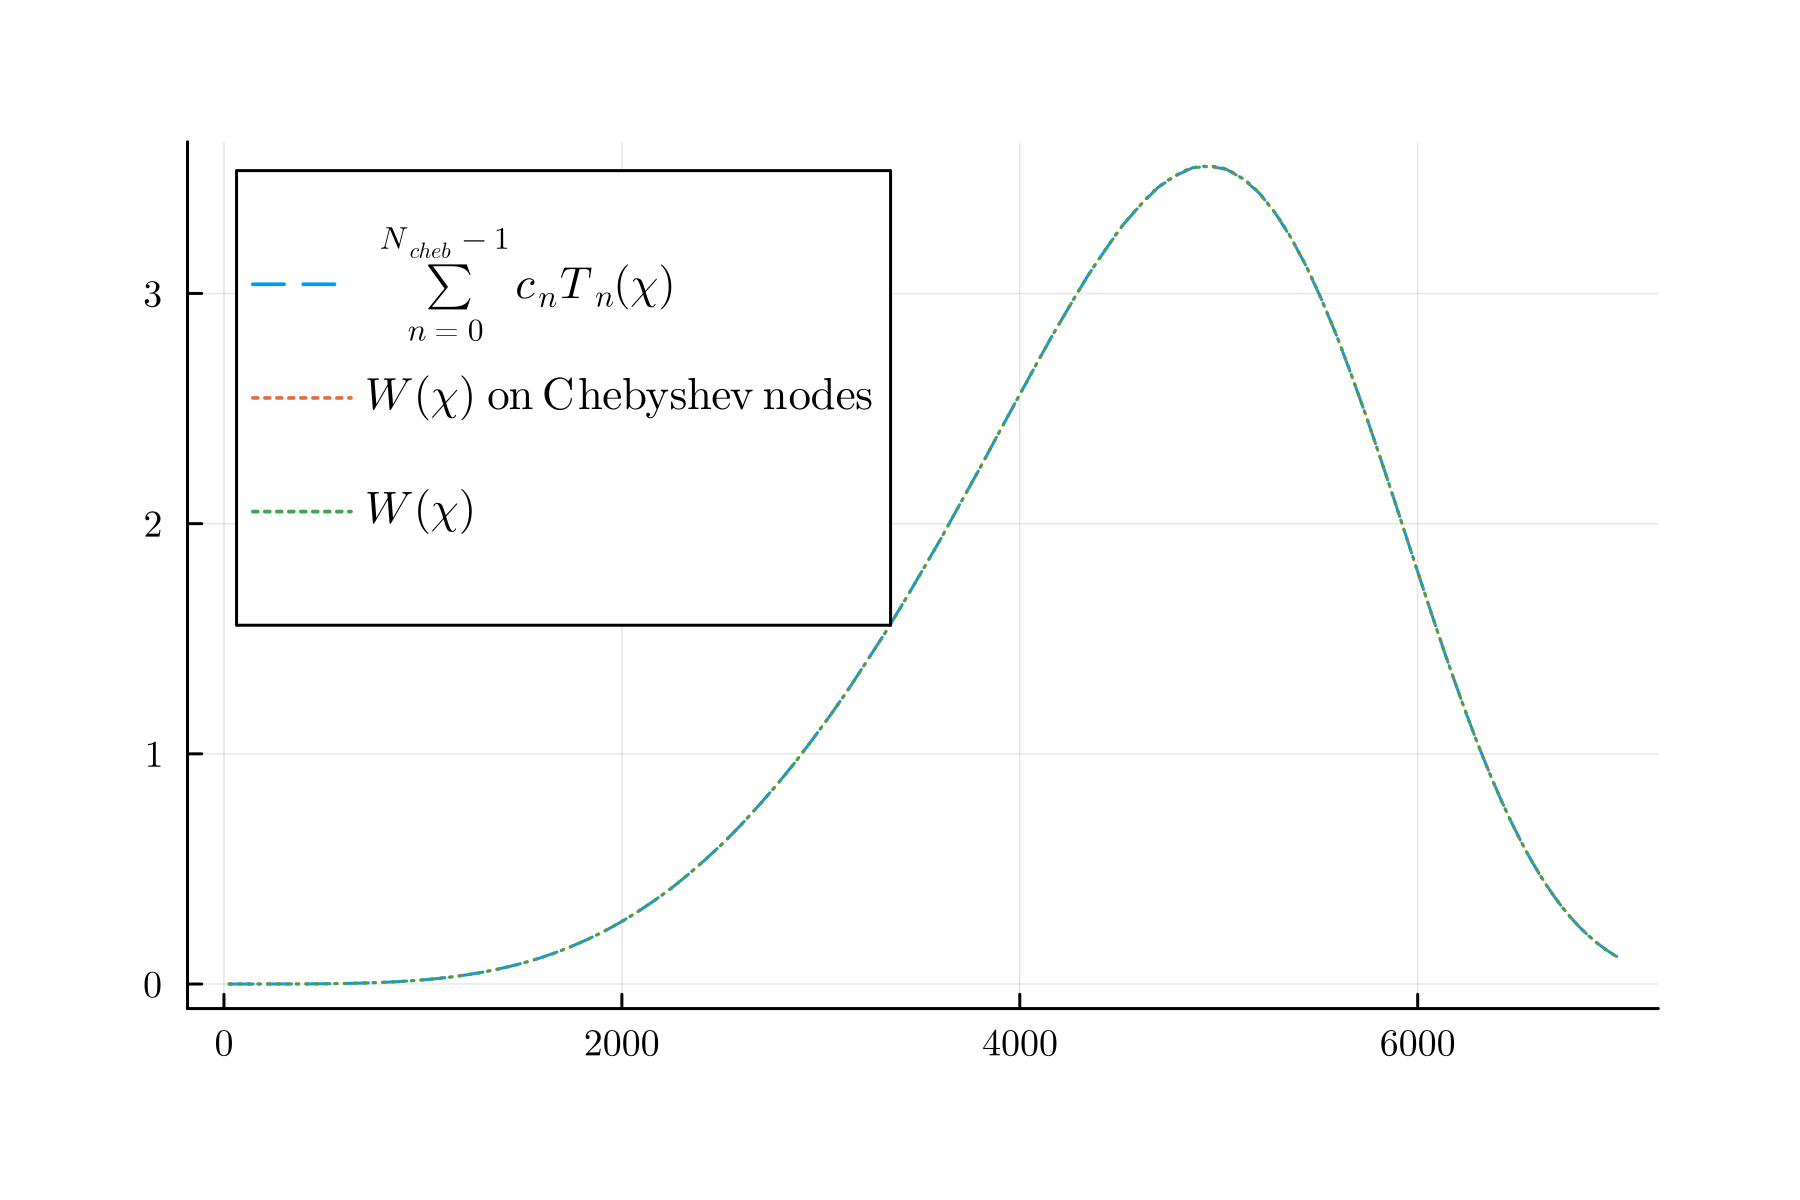

In [581]:
if grids.sorting == true
  x_cheb_plot = Blast.get_clencurt_grid(grid_data.xmin, grid_data.xmax, grid_data.n_cheb)
else
  x_cheb_plot = Blast.get_clencurt_grid(grid_data.xmax, grid_data.xmin, grid_data.n_cheb)
end
z_interp = DataInterpolations.AkimaInterpolation(grid_data.z, grid_data.x, extrapolation=ExtrapolationType.Linear)
z_cheb_plot = z_interp.(x_cheb_plot)
plot(x_cheb_plot, W_cheb_ord, label = L"\sum_{n=0}^{N_{cheb}-1} c_n T_n(\chi)", ls=:dash, markersize=0.1, markercolor =:blue)
plot!(x_cheb_plot, W_cheb, label = L"W(\chi) \; \mathrm{on} \; \mathrm{Chebyshev} \; \mathrm{nodes}", lw=1, ls=:dot; markercolor =:red, plot_theme.shared_style...)
plot!(grid_data.x, W_x, label = L"W(\chi)", lw=1, ls=:dot; markercolor = :green, plot_theme.shared_style...)

Now I want to compute the relative error between the $W(z)$ and $W(z_cheb)$. To do so, they have to share the same grid. So I bring the normal W(z), previously computed on N nodes, on the Chebyshev grid. 
Note that the object is computed using both $\chi$ and $z$ obtained through get_clencurt_grid, so there's no need to reverse it at the end. 

In [582]:
#galW_computed_on_cheb, _, _, _, _ = galaxy_galaxy.galaxy_prefactor(x_cheb_plot, z_cheb_plot, grid_data.cosmo; output_dir=paths.output_dir);
W_x_on_cheb , _, _, _, _ = galaxy_galaxy.galaxy_prefactor(sort(x_cheb_plot), sort(z_cheb_plot), grid_data.cosmo; output_dir=paths.output_dir);

Plots will be saved in: out/runs/run_2026_07_21_132207/plots/kernels/
Quantities will be saved in: out/runs/run_2026_07_21_132207/quantities/
Comoving distance vs redshift plot saved.
Bias plot saved.
Growth factor plot saved.
Hubble factor plot saved.
n(z) vs redshift plot saved.
Normalized n(z) vs redshift plot saved.
n(z) vs redshift plot saved.
W(z) plot saved.
Normalized kernel plot saved.
Unnormalized kernel plot saved.
W(z) prefactor saved: out/runs/run_2026_07_21_132207/quantities/prefac_galaxy.npy


Now that I have the two object on the same grid, I once again plot the two

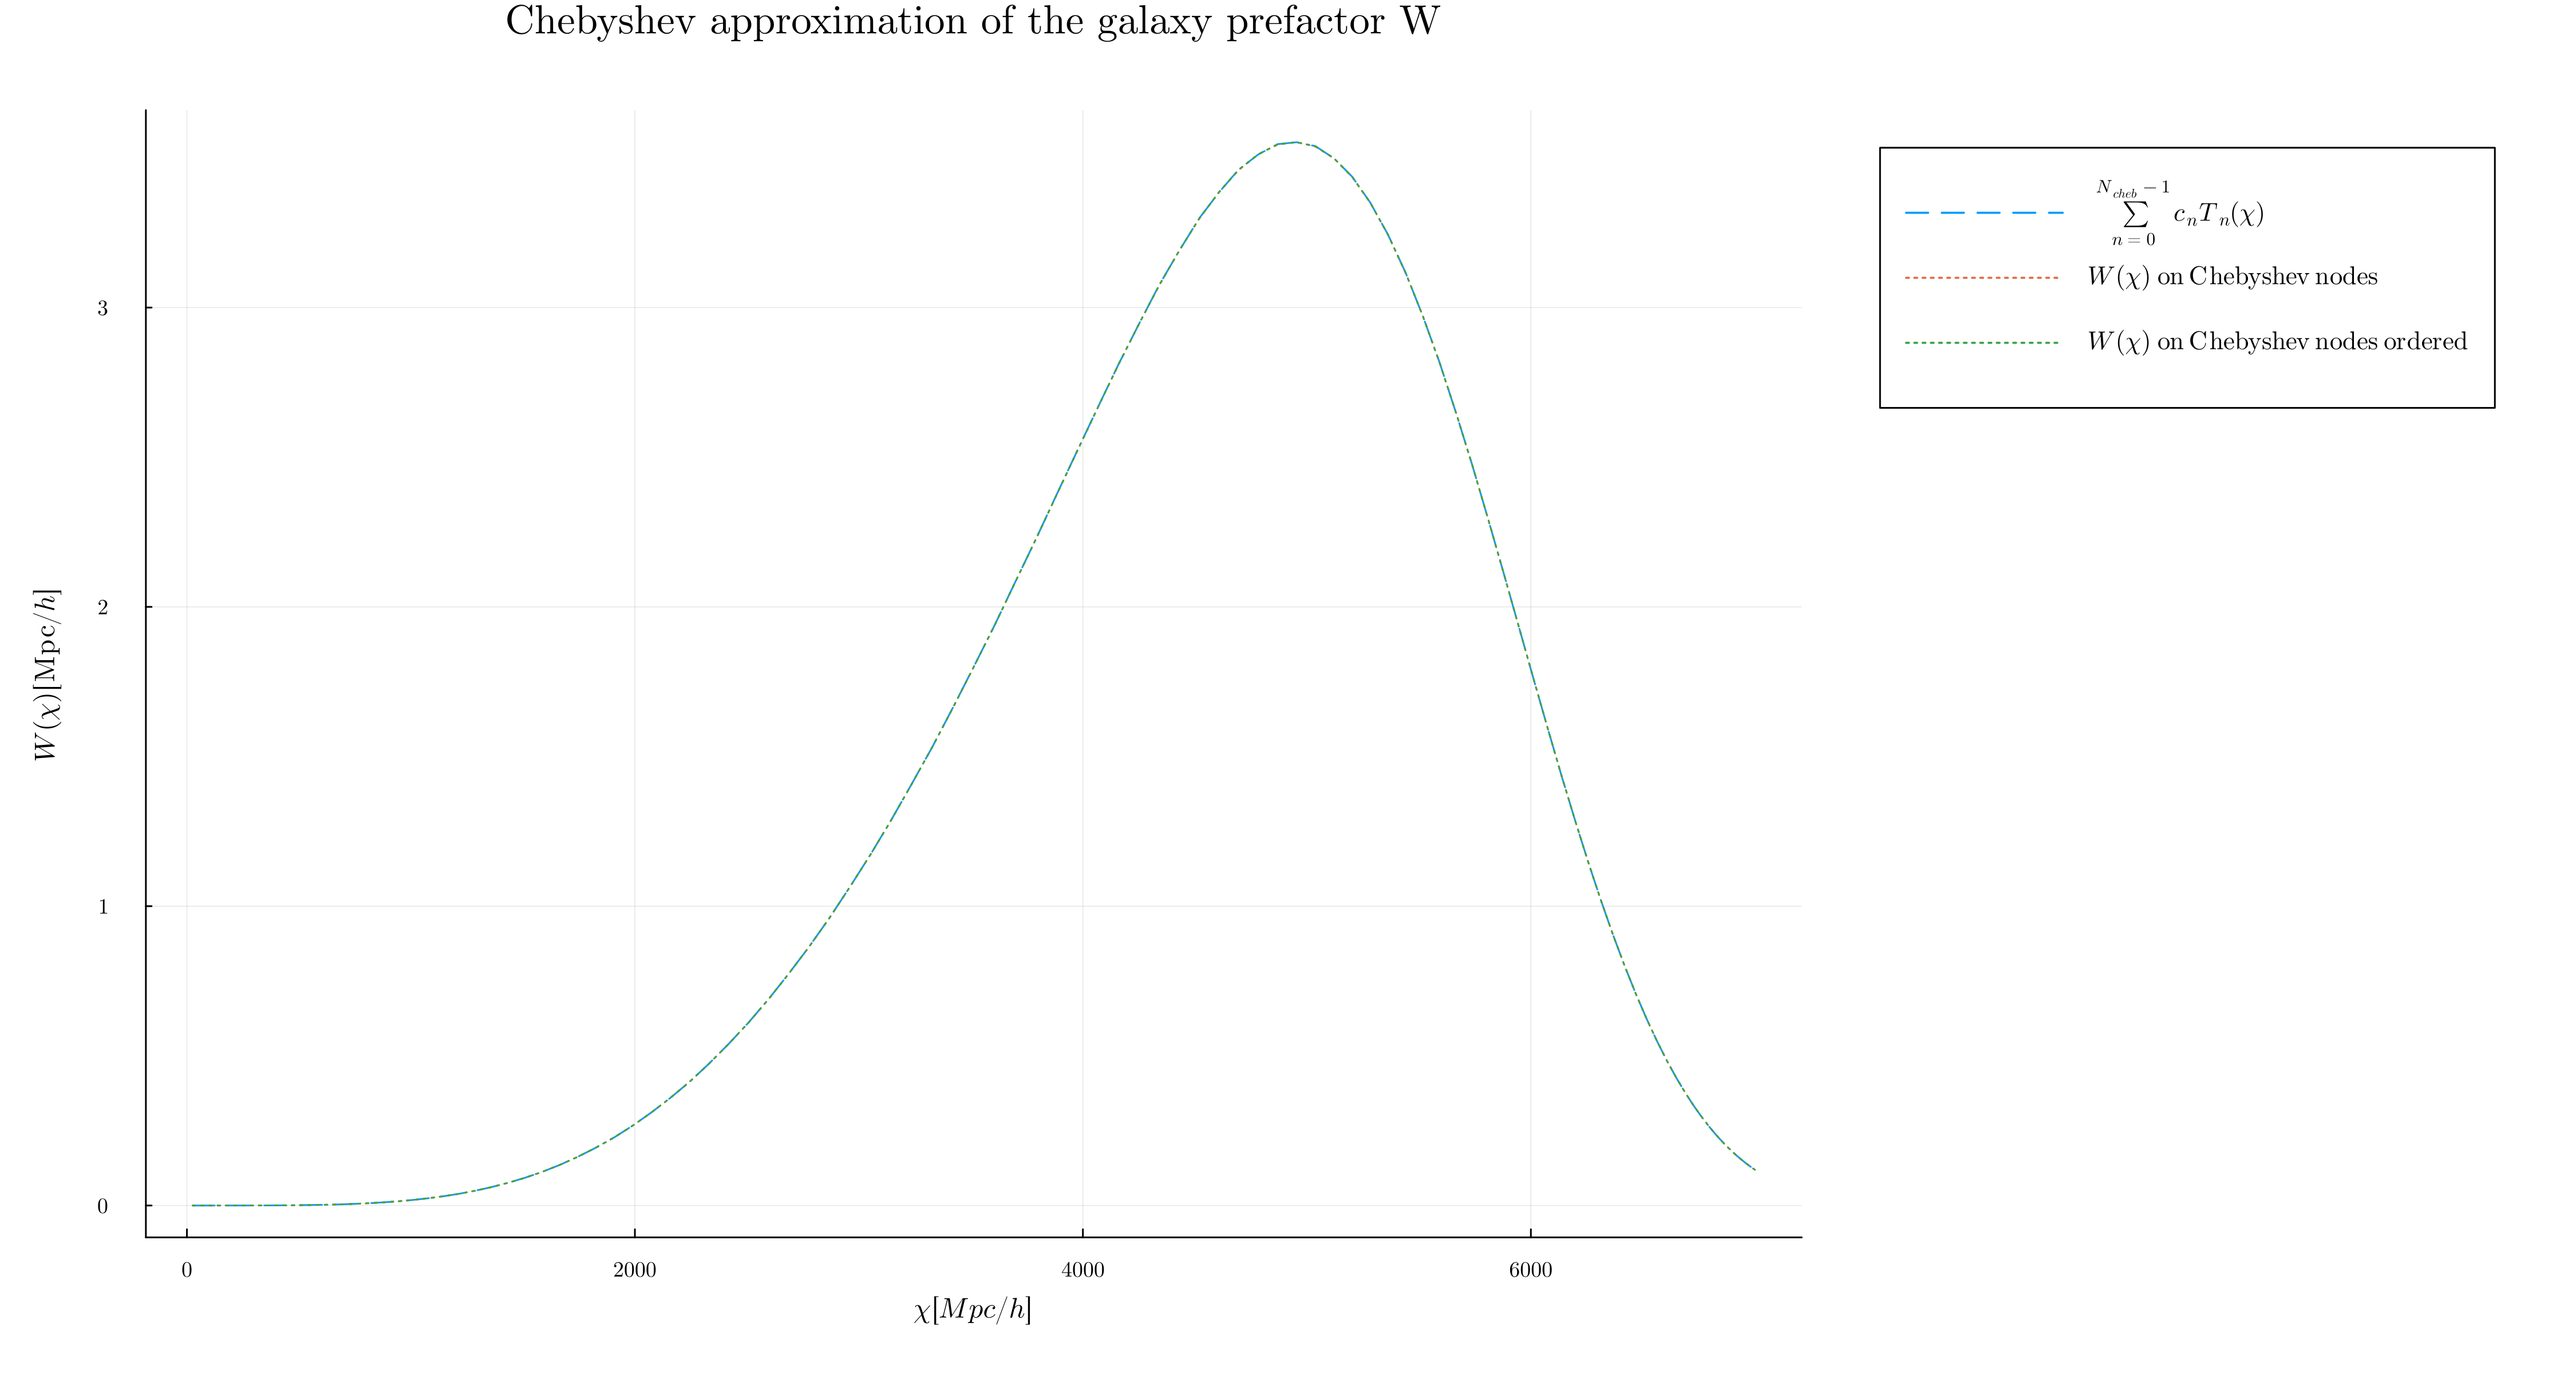

In [583]:
plot(x_cheb_plot, W_cheb, label = L"\sum_{n=0}^{N_{cheb}-1} c_n T_n(\chi)", ls=:dash, markersize=0.1, markercolor =:blue)
plot!(sort(x_cheb_plot), W_x_on_cheb, label = L"W(\chi) \; \mathrm{on} \; \mathrm{Chebyshev} \; \mathrm{nodes}", lw=1, ls=:dot)
plot!(x_cheb_plot, W_cheb_ord, label = L"W(\chi) \; \mathrm{on} \; \mathrm{Chebyshev} \; \mathrm{nodes} \; \mathrm{ordered}", lw=1, ls=:dot)
plot!(xlabel = L"\chi [Mpc/h]", ylabel = L"W(\chi) [\mathrm{Mpc}/h]", size = plot_theme.size_Cl,
        title = "Chebyshev approximation of the galaxy prefactor W", titlefontsize = 5, legendposition = :outertopright, legendfontsize = 10; plot_theme.shared_style...)

In [584]:
if grids.sorting == true
  W_x_on_cheb = W_x_on_cheb[end:-1:1]; #this is the same as doing W_cheb_ord = W_cheb[end:-1:1];
end
rel_err = (W_cheb ./ W_x_on_cheb .- 1)
rel_err_abs = abs.(rel_err)
rel_err_pct = 100 .* rel_err
rel_err_pct_abs = 100 .* rel_err_abs
;

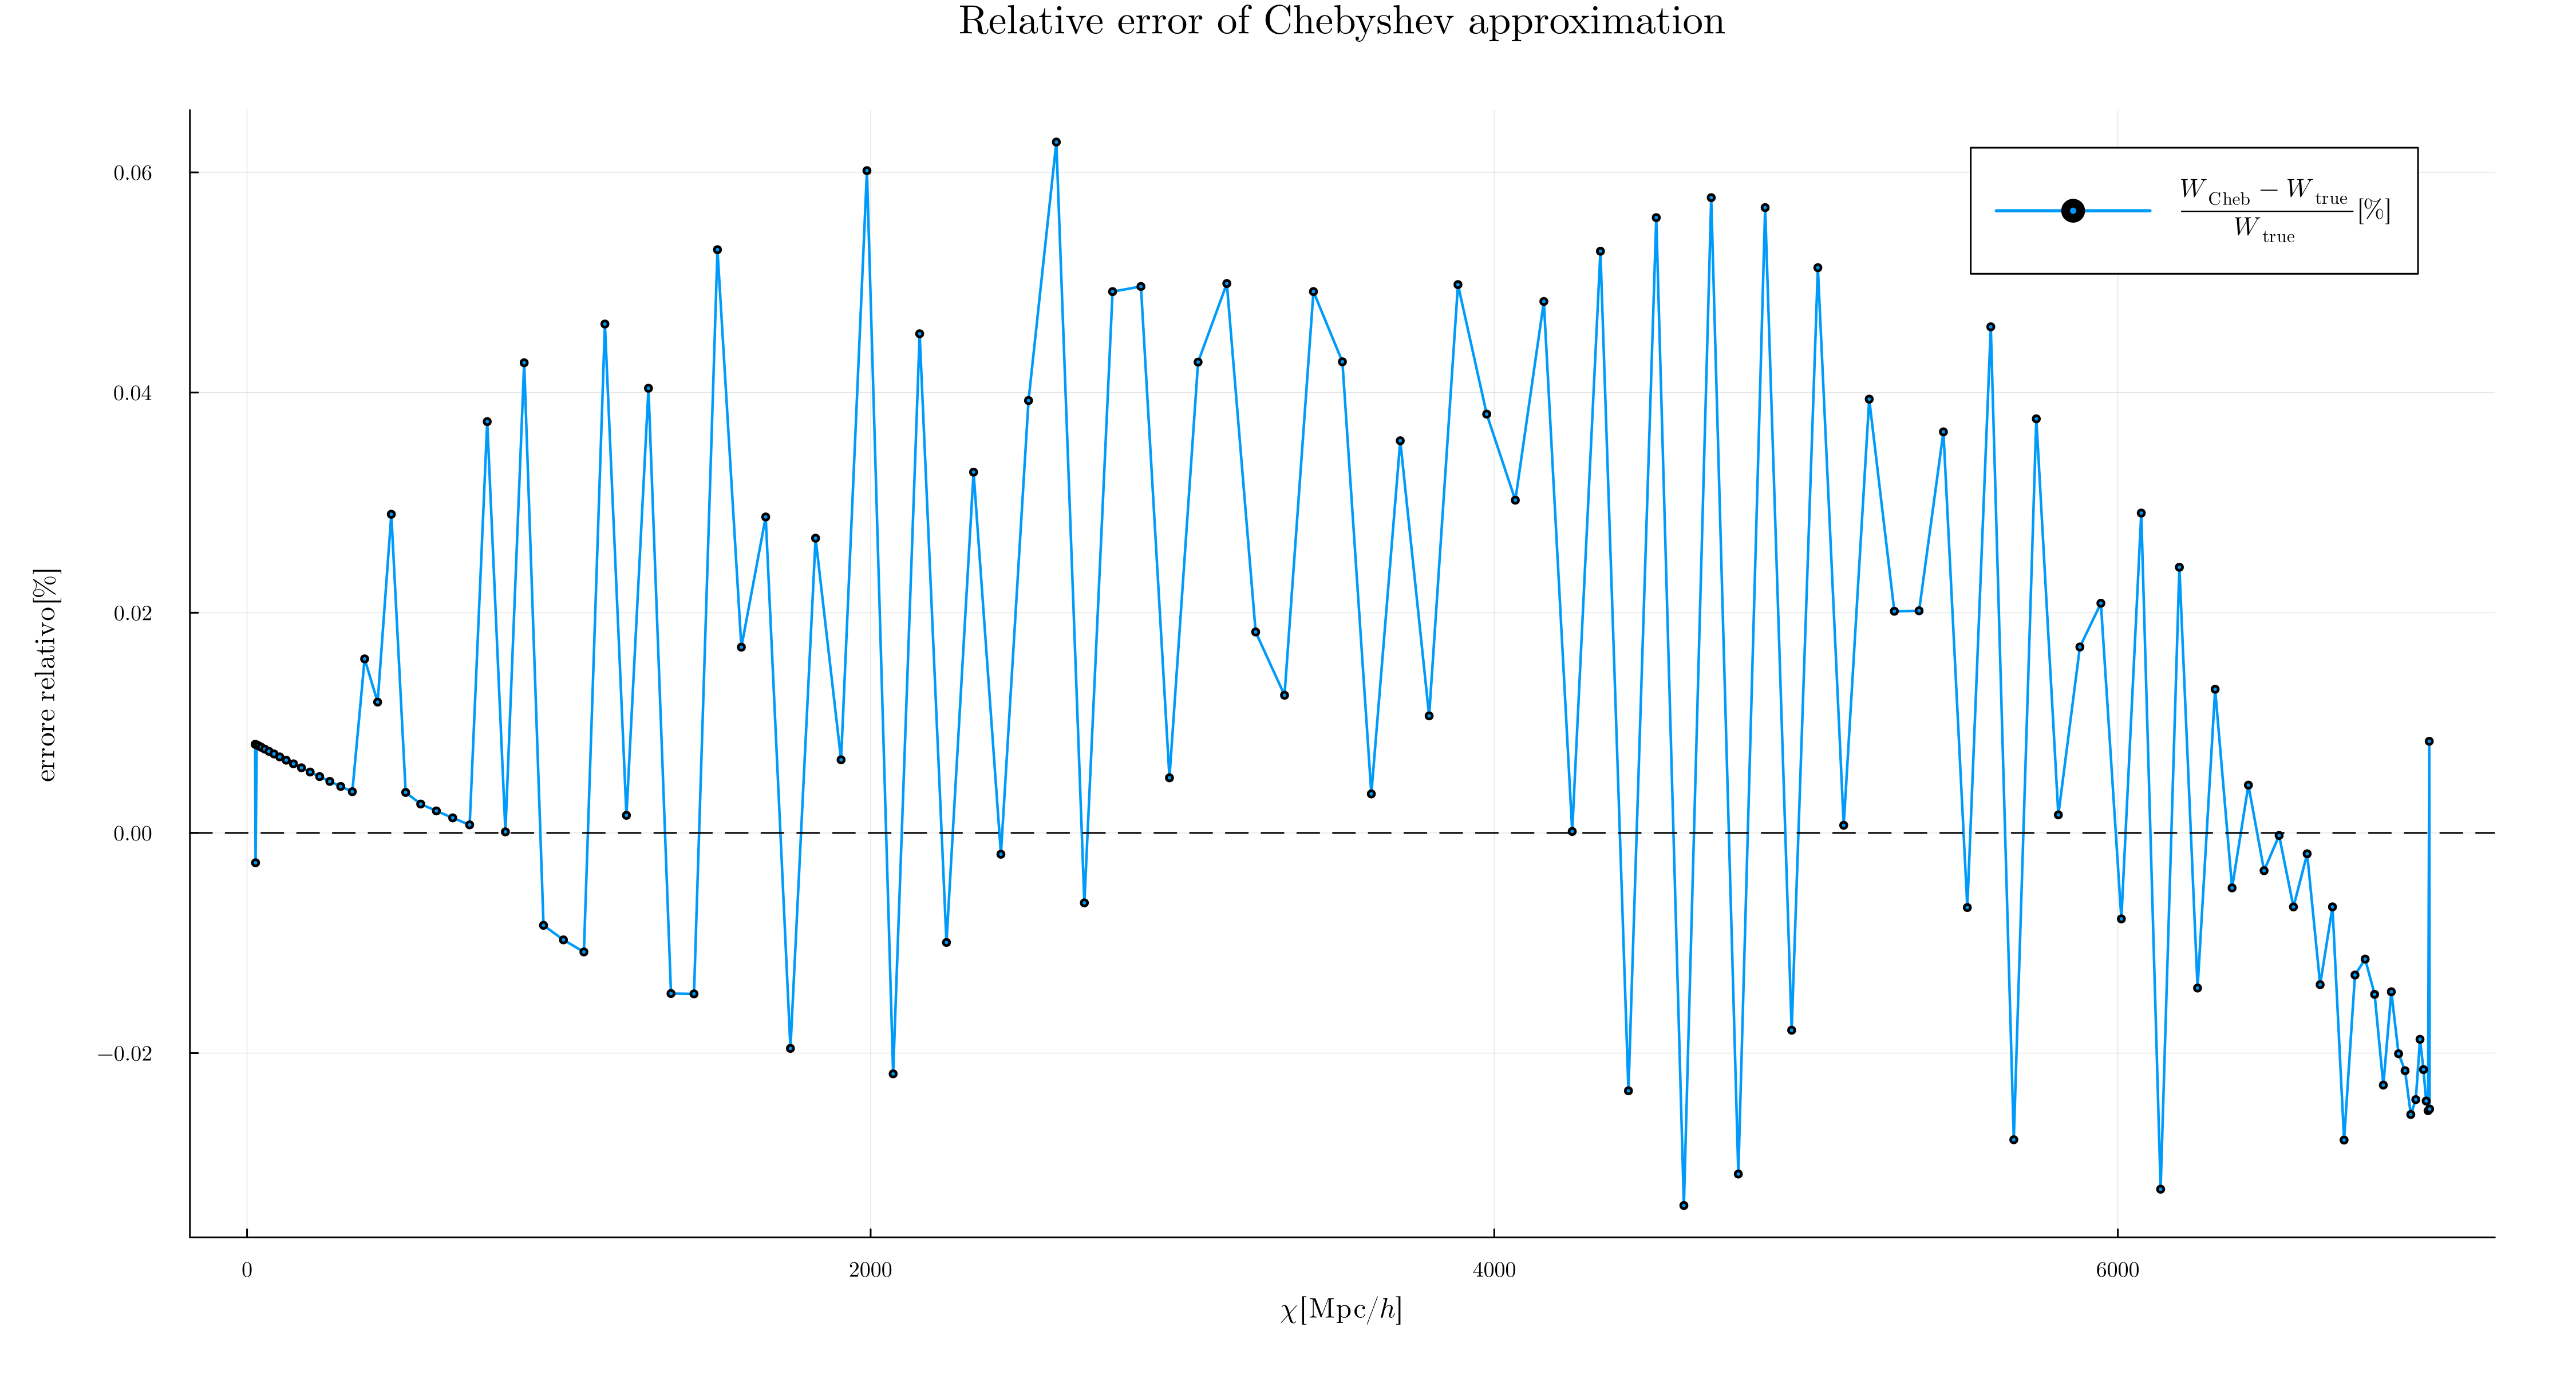

In [585]:
plot(
    x_cheb_plot, 
    rel_err_pct,
    label = L"\frac{W_{\mathrm{Cheb}} - W_{\mathrm{true}}}{W_{\mathrm{true}}}\,[\%]",
    lw = 1.5,
    marker = :circle,
    markersize = 2,
    legendposition = :topright,
    xlabel = L"\chi\,[\mathrm{Mpc}/h]",
    ylabel = L"\mathrm{errore\ relativo}\,[\%]",
    title = "Relative error of Chebyshev approximation", size=plot_theme.size_Cl; plot_theme.shared_style...
    )

hline!([0.0], ls = :dash, lw = 1, color = :black, label = false)


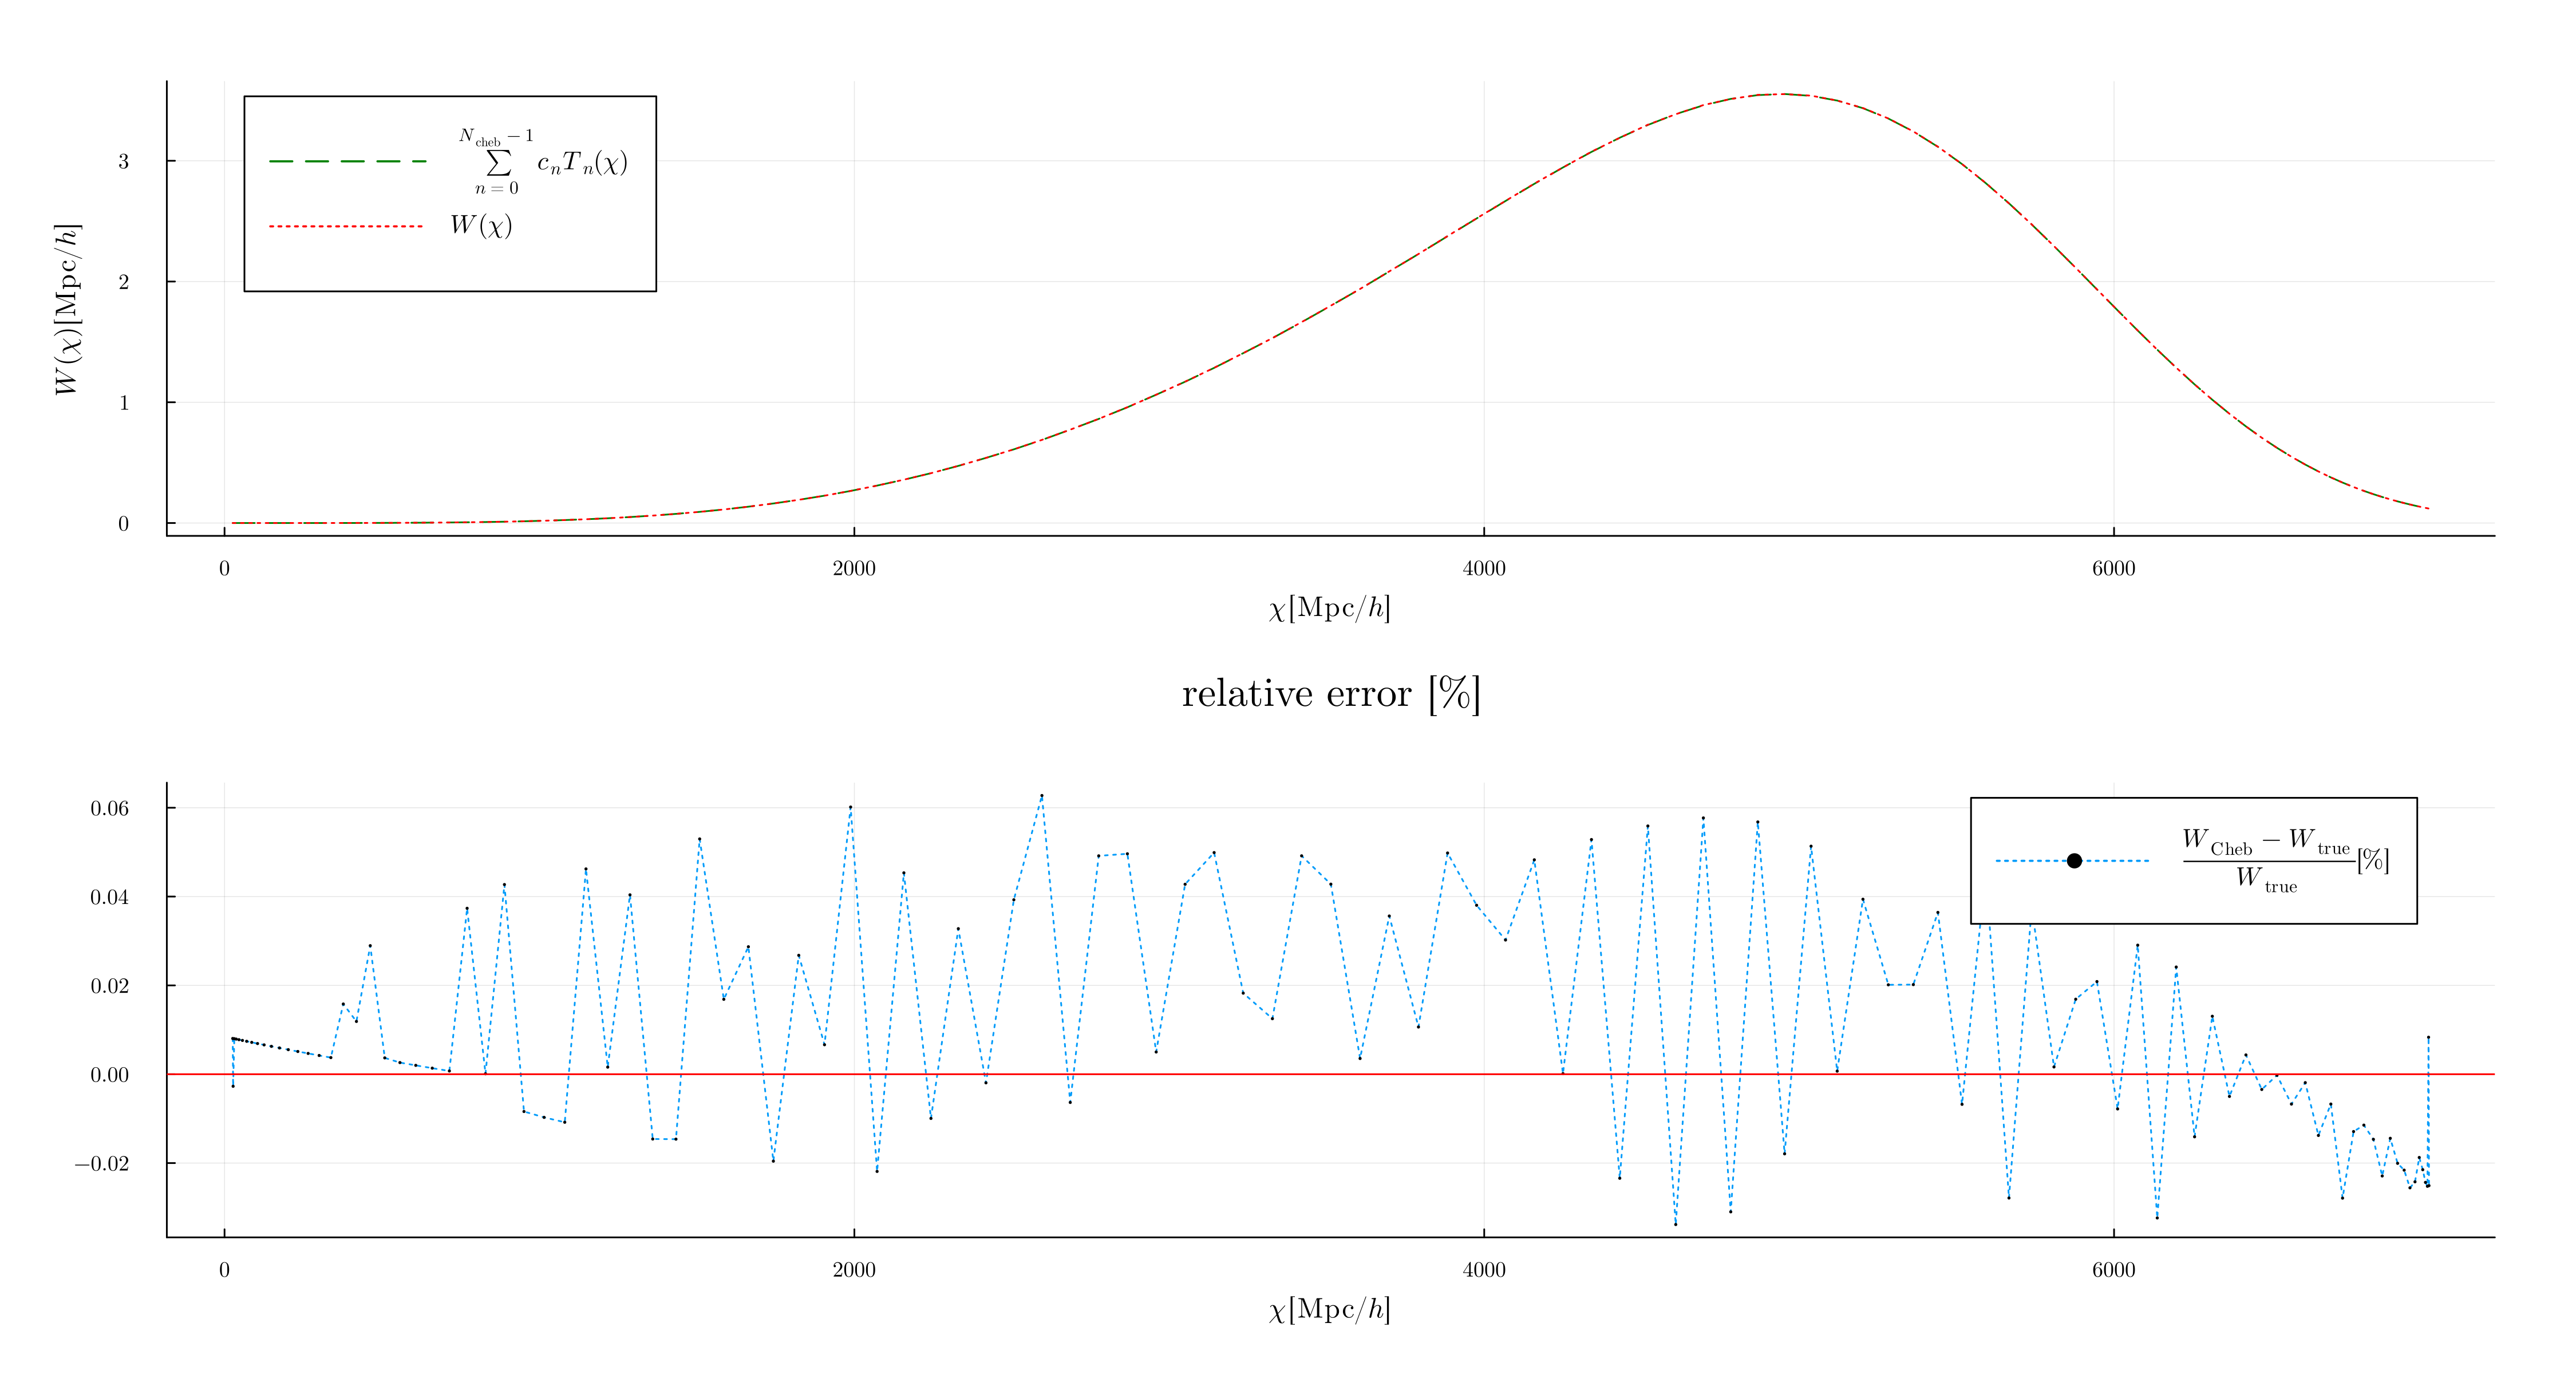

In [586]:
p1 = plot(
    x_cheb_plot, W_x_on_cheb,
    label = L"\sum_{n=0}^{N_{\mathrm{cheb}}-1} c_n T_n(\chi)",
    ls = :dash, color = :green)
plot!(p1, x_cheb_plot, W_cheb, label = L"W(\chi)", lw = 1, ls = :dot, color = :red)
plot!(p1, dpi = 300, legendposition = :topleft, xlabel = L"\chi [Mpc/h]", ylabel = L"W(\chi) [\mathrm{Mpc}/h]", 
        size = plot_theme.size_Cl; plot_theme.shared_style...
        )
    
p2 = plot(
    x_cheb_plot, rel_err_pct,
    label = L"\frac{W_{\mathrm{Cheb}} - W_{\mathrm{true}}}{W_{\mathrm{true}}} [\%]",
    lw = 1.0, marker = :circle, markercolor = :black, markersize = 1, linestyle = :dot, 
    title = "relative error [%]", titlefontsize = 10
)
hline!(p2, [0.0], ls = :solid, lw = 1, color = :red, label = false)

plot(p1, p2, layout = @layout([a; b]), dpi = 300,
     xlabel = L"\chi\,[\mathrm{Mpc}/h]",
    size = plot_theme.size_Cl; plot_theme.shared_style...)

In [587]:
savefig(joinpath(paths.plot_subdir, "kernels/Wx_cheb_comparison_with_rel_error.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/kernels/Wx_cheb_comparison_with_rel_error.png"

### The dimension of the Chebyshev coefficients is [n_cheb]

In [588]:
println("size of c_cheb: ", size(c_cheb))
npzwrite(joinpath(paths.quantity_subdir, "chebcoefs/c_cheb.npy"), c_cheb)

size of c_cheb: (119,)


In [589]:
n_idx = 0:(grid_data.n_cheb - 1)
plot(n_idx, abs.(c_cheb),
     yscale = :log10,
     xlabel = L"{grid_data.n_cheb}",
     ylabel = L"|c_{grid_data.n_cheb}|",
     label = L"|c_{grid_data.n_cheb}| \ \mathrm{di} \ W(\chi)",
     title = "Chebyshev coefficients decay",
     marker = :circle, markersize = 3; plot_theme.shared_style...
     )
savefig(joinpath(paths.plot_subdir, "kernels", "chebcoeff_decay_galaxy.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/kernels/chebcoeff_decay_galaxy.png"

In [590]:
function cheb_eval_partial(coeffs, x, xmin, xmax, ntrunc)
    t = @. (2*x - (xmax + xmin)) / (xmax - xmin)
    T0 = ones(length(x))
    if ntrunc == 0
        return coeffs[1] .* T0
    end
    T1 = t
    S = coeffs[1] .* T0 .+ coeffs[2] .* T1
    for n in 2:ntrunc
        T2 = @. 2*t*T1 - T0
        S .+= coeffs[n+1] .* T2
        T0, T1 = T1, T2
    end
    return S
end

#chi_cheb_nodes = reverse(Blast.get_clencurt_grid(grid_data.xmin, grid_data.xmax, grid_data.n_cheb))
chi_cheb_nodes = Blast.get_clencurt_grid(grid_data.xmin, grid_data.xmax, grid_data.n_cheb)
x_ref = chi_cheb_nodes
Wref = W_cheb

truncs = 1:1:length(c_cheb)-1
#truncs = [5, 10, 20, 40, 80, 120, 160, length(c_cheb)-1]
errs = Float64[]
Wn = zeros(length(x_ref))
for ntrunc in truncs
    Wn = cheb_eval_partial(c_cheb, x_ref, grid_data.xmin, grid_data.xmax, ntrunc)
    err = maximum(abs.(Wn .- Wref)) / maximum(abs.(Wref))
    push!(errs, err)
end

truncs_plot = truncs[1:end]
errs_plot = errs[1:end]
yticks_vals = 10.0 .^ (floor(log10(minimum(errs_plot))):ceil(log10(maximum(errs_plot))))

plot(truncs_plot, errs_plot,
     yscale = :log10,
     marker = :circle,
     xlabel = L"N_{trunc}",
     ylabel = L"\mathrm{err}(N_{trunc}) = \frac{\max_i |W_{N_{trunc}} - W(\chi_i)|}{\max_i |W(\chi_i)|}",
     title  = L"\mathrm{err}(N_{trunc}) = \frac{\max_i |W_{N_{trunc}} - W(\chi_i)|}{\max_i |W(\chi_i)|}",
     legend = false,
     framestyle = :box,
     yticks = yticks_vals, size=plot_theme.size_Cl; plot_theme.shared_style...
     )
savefig(joinpath(paths.plot_subdir, "kernels", "chebcoeff_truncation_error_galaxy.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/kernels/chebcoeff_truncation_error_galaxy.png"

$W_{tilde} = \int dz W(z) j_l(k\chi(z)) j_l(k_1\chi(z))$

$\tilde W_{\ell}^g(k1,k) \approx \sum_{n=0}^{N_{cheb}-1} c_n \int_{z_{min}}^{z_{max}} dz T_n(\hat z) k_1 j_l(k\chi(z)) j_l(k_1\chi(z))$

Computing $\tilde W(k, k_1)$...

In [591]:
# # N = 2^15+1, Nk = Nkp = Nkpp = 150, N_cheb = 200, length(ℓ) = 100
# mode are "fast", "slow", and "big"
W_tilde = zeros(grid_data.Nk, grid_data.Nkp, grid_data.n_cheb, length(grid_data.ℓ))
if reuse
  if mode == "fast" #sort = true
    W_tilde = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/runs/yes_sorting_run_2026_07_20_104650/quantities/W_tilde.npy")
  elseif mode == "slow" #sort = false
    W_tilde = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/runs/no_sorting_run_2026_07_20_102547/quantities/W_tilde.npy")
  end
else
  p = Progress(length(grid_data.ℓ); desc = "Computing W_tilde")
  elapsed_time = zeros(length(grid_data.ℓ))
  println("Dimensions of W_tilde: ", size(W_tilde))
  for i in eachindex(grid_data.ℓ)
      t_0 = time()
      W_tilde[:, :, :, i] .= Blast.W_tilde_computation(grid_data.ℓ[i], grid_data.zmin, grid_data.zmax, grid_data.kmin, grid_data.kmax,
      grid_data.Nk, grid_data.Nkp, grid_data.n_cheb, grid_data.N, grids.k_grid, grids.kp_grid, grids.kpp_grid, grids.sorting)
      t_end = time()
      elapsed_time[i] = t_end - t_0
      next!(p; showvalues = [(:ℓ, grid_data.ℓ[i]), (:dt, round(elapsed_time[i], digits=2))])
  npzwrite(joinpath(paths.quantity_subdir, "elapsed_time.npy"), elapsed_time)  
  #histogram(grid_data.ℓ, elapsed_time, bins=30, xlabel = L"\ell", ylabel = "Elapsed time [s]", title = "Elapsed time for W_tilde computation", size=plot_theme.size_plot; plot_theme.shared_style...)  
  end
end
;

Saving $\tilde W(k, k_1)$ and printing its dimensions...

In [592]:
if reuse == false
  npzwrite(joinpath(paths.quantity_subdir, "W_tilde.npy"), W_tilde)
end

println("Size of W_tilde: ", size(W_tilde)) #Size of W_tilde: (Nk, Nkp, Ncheb, Nl)

Size of W_tilde: (150, 150, 119, 100)


$\tilde W(k,k_1)$ (like $\tilde W(k,k_2)$) represents the term: \
$\tilde W_{i,p,l}^{(\ell)} = \sum_{m=1}^{N_k} w_{k_m} T_{\ell}(k_m) j_{\ell}(\chi_i k_m) j_{\ell}(\chi_p k_m) $ \
it describes how much two shells at comoving distance $\chi_i$ and $\chi_p$ are correlated to the multipole $\ell$, weighted by the Chebyshev polynomial $T_{\ell}$ on the mode $k$.

Computing $\tilde W_{final}$ by contracting $\tilde W$ with $c_{cheb}$ and printing its dimensions...

In [593]:
@tullio W_final_gal[il, ik, ikp] := W_tilde[ik, ikp, ic, il] * c_cheb[ic]

println("Size of W_final_gal: ", size(W_final_gal)) # [ell, k_grid, kp_grid]
;

Size of W_final_gal: (100, 150, 150)


When sorting is set to true, the $k_{grid}$ has $k_{grid}[1] \approx k_{min}$, and $k_{grid}[end] \approx k_{max}$. \
When sorting is set to false, the $k_{grid}$ has $k_{grid}[1] \approx k_{max}$, and $k_{grid}[end] \approx k_{min}$.

In [594]:
println("sorting = ", grids.sorting)
println("k_grid[1]: ", grids.k_grid[1])
println("k_grid[end]: ", grids.k_grid[end])

sorting = false
k_grid[1]: 15.384615384615385
k_grid[end]: 0.00035714285714227856


In [595]:
idx = sortperm(grids.k_grid) #idx = 150, 149, ..., 1
idx_p = sortperm(grids.kp_grid) #idx_p = 150, 149, ..., 1
println("idx[1]: ", idx[1], ", idx[end]: ", idx[end])
println("idx_p[1]: ", idx_p[1], ", idx_p[end]: ", idx_p[end])
;

idx[1]: 150, idx[end]: 1
idx_p[1]: 150, idx_p[end]: 1


In [596]:
println("k_grid[idx[1]]: ", grids.k_grid[idx[1]])
println("k_grid[idx[end]]: ", grids.k_grid[idx[end]])

k_grid[idx[1]]: 0.00035714285714227856
k_grid[idx[end]]: 15.384615384615385


In [597]:
println("W_tilde[k_grid[idx[1]], kp_grid[idx_p[1]], 1, 1]: ", W_tilde[idx[1], idx_p[1], 1, 1])
println("W_tilde[k_grid[1], kp_grid[1], 1, 1]: ", W_tilde[1, 1, 1, 1])
println("W_tilde[k_grid[idx[end]], kp_grid[idx_p[end]], 1, 1]: ", W_tilde[idx[end], idx_p[end], 1, 1])
println("W_tilde[k_grid[end], kp_grid[end], 1, 1]: ", W_tilde[end, end, 1, 1])

W_tilde[k_grid[idx[1]], kp_grid[idx_p[1]], 1, 1]: 2.9057599696382967e-18
W_tilde[k_grid[1], kp_grid[1], 1, 1]: 0.3049444162012584
W_tilde[k_grid[idx[end]], kp_grid[idx_p[end]], 1, 1]: 0.3049444162012584
W_tilde[k_grid[end], kp_grid[end], 1, 1]: 2.9057599696382967e-18


In [598]:
#println(W_final_gal[1,idx,idx_p])

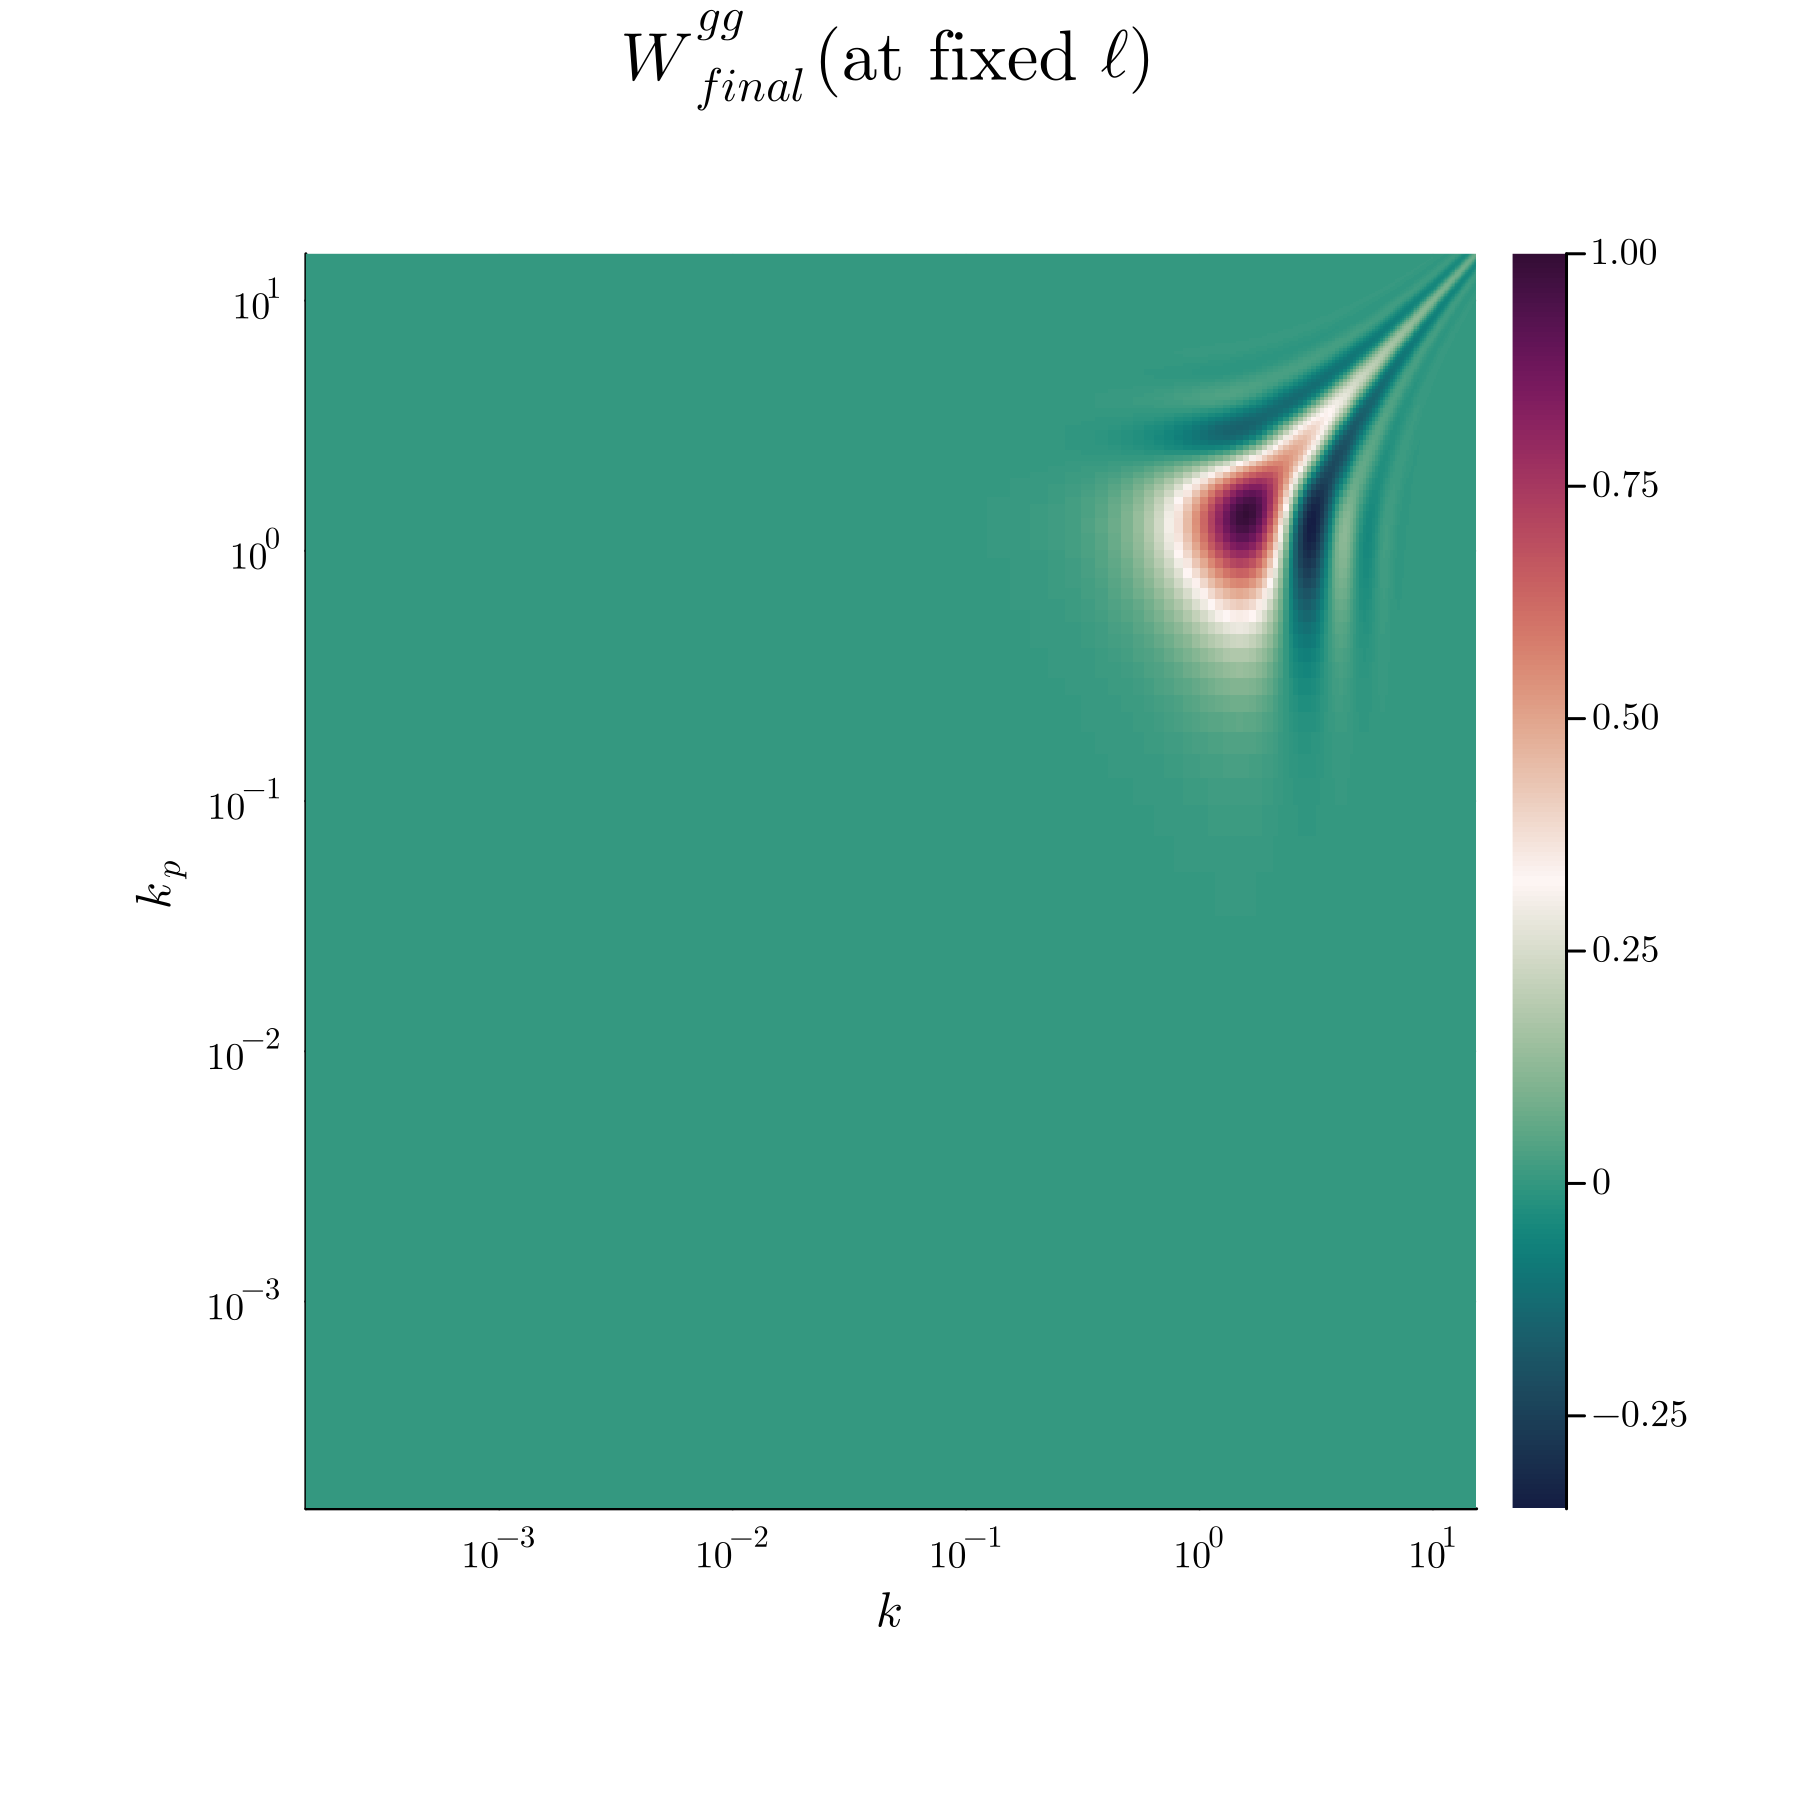

In [599]:
# genera tick automatici alle potenze di 10 nel range dei dati
xticks_vals = 10.0 .^ (floor(log10(minimum(grids.k_grid))):ceil(log10(maximum(grids.k_grid))))
yticks_vals = 10.0 .^ (floor(log10(minimum(grids.kp_grid))):ceil(log10(maximum(grids.kp_grid))))
il = 1
if grids.sorting == true
        heatmap(grids.k_grid, grids.kp_grid,
                W_final_gal[il,:,:]/maximum(W_final_gal[il,:,:]),
                title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)",
                xscale = :log10, 
                yscale = :log10,
                xlabel=L"log_{10}(k) \; [\mathrm{h/Mpc}]", ylabel=L"log_{10}(k_p) \; [\mathrm{h/Mpc}]",
                size = plot_theme.size_heatmap,
                c = plot_theme.c, 
                xticks = xticks_vals, 
                yticks = yticks_vals; 
                plot_theme.shared_style...
                )
else
        heatmap(grids.k_grid[idx], grids.kp_grid[idx_p],
                W_final_gal[il,idx,idx_p]/maximum(W_final_gal[il,idx,idx_p]),
                title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)",
                xscale = :log10, 
                yscale = :log10,
                xlabel=L"k", ylabel=L"k_p",
                size = plot_theme.size_heatmap,
                c = plot_theme.c, 
                xticks = xticks_vals, 
                yticks = yticks_vals; 
                plot_theme.shared_style...
                )
end

In [600]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/heatmaps/heatmap_k_k1_log.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/Sl_plots/heatmaps/heatmap_k_k1_log.png"

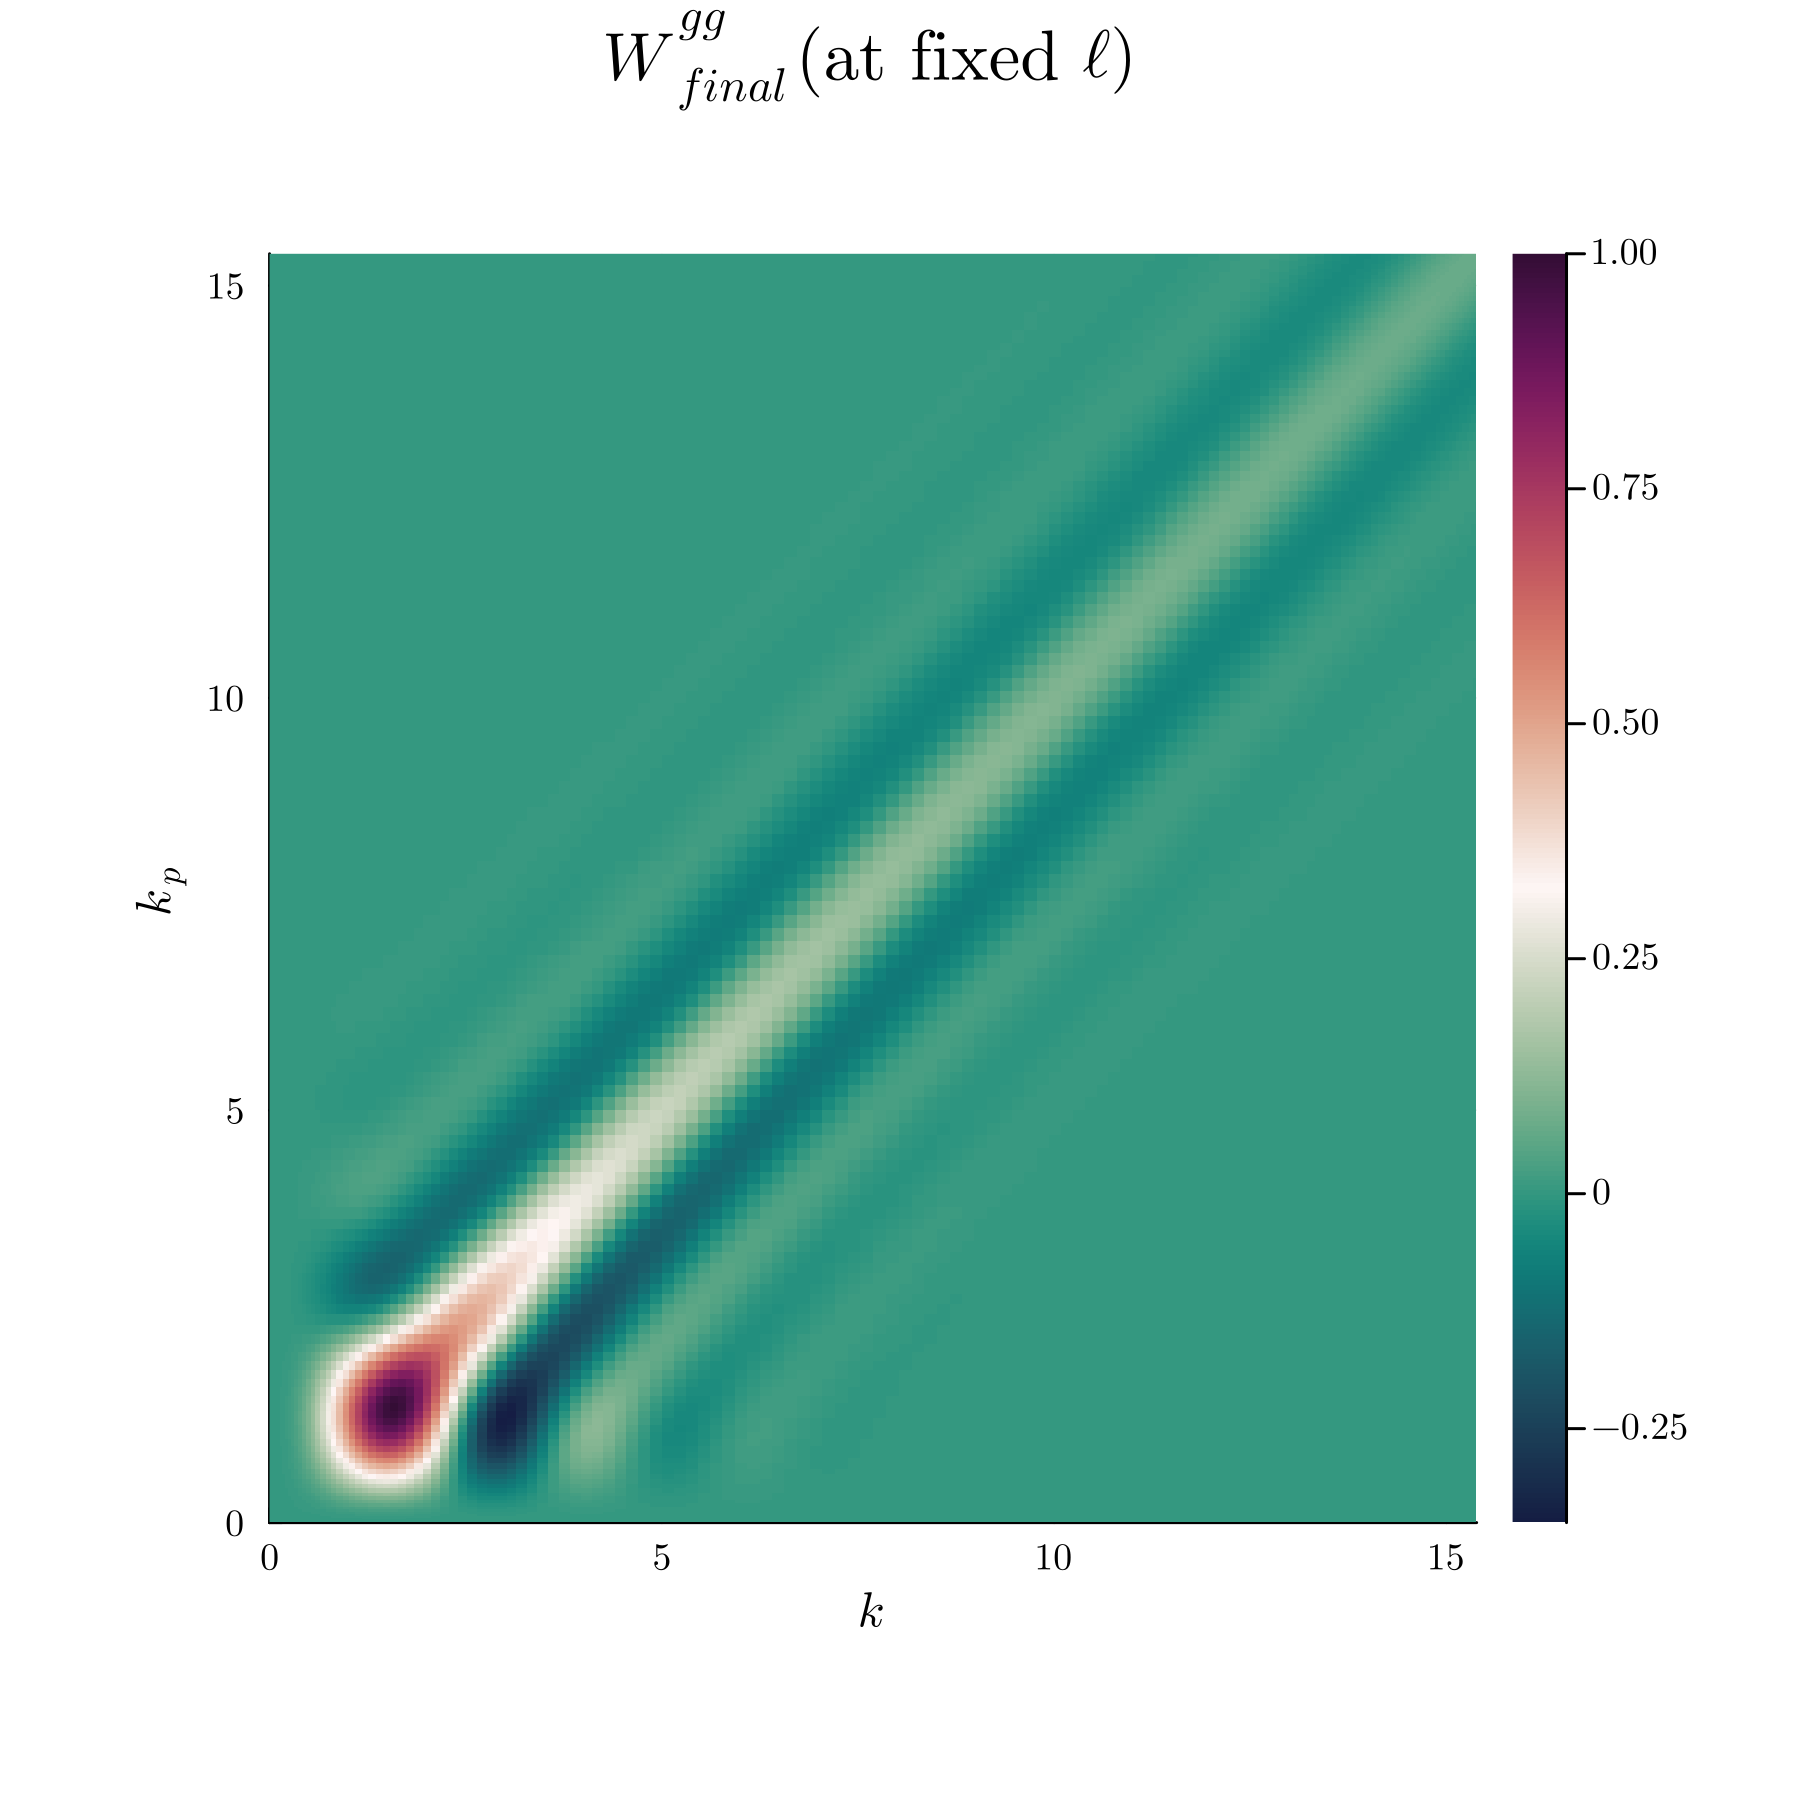

In [601]:
il = 1
if grids.sorting == true
        heatmap(grids.k_grid, grids.kp_grid,
                W_final_gal[il,:,:]/maximum(W_final_gal[il,:,:]),
                title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)",
                xlabel=L"k", ylabel=L"k_p",
                size = plot_theme.size_heatmap,
                c = plot_theme.c; 
                plot_theme.shared_style...
                )
else
         heatmap(grids.k_grid[idx], grids.kp_grid[idx_p],
                W_final_gal[il,idx,idx_p]/maximum(W_final_gal[il,idx,idx_p]),
                title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)",
                xlabel=L"k", ylabel=L"k_p",
                size = plot_theme.size_heatmap,
                c = plot_theme.c; 
                plot_theme.shared_style...
                )
end

In [602]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/heatmaps/heatmap_k_k1.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/Sl_plots/heatmaps/heatmap_k_k1.png"

In [603]:
println(size(W_tilde))

(150, 150, 119, 100)


In [604]:
println(1:grid_data.Nk)

1:150


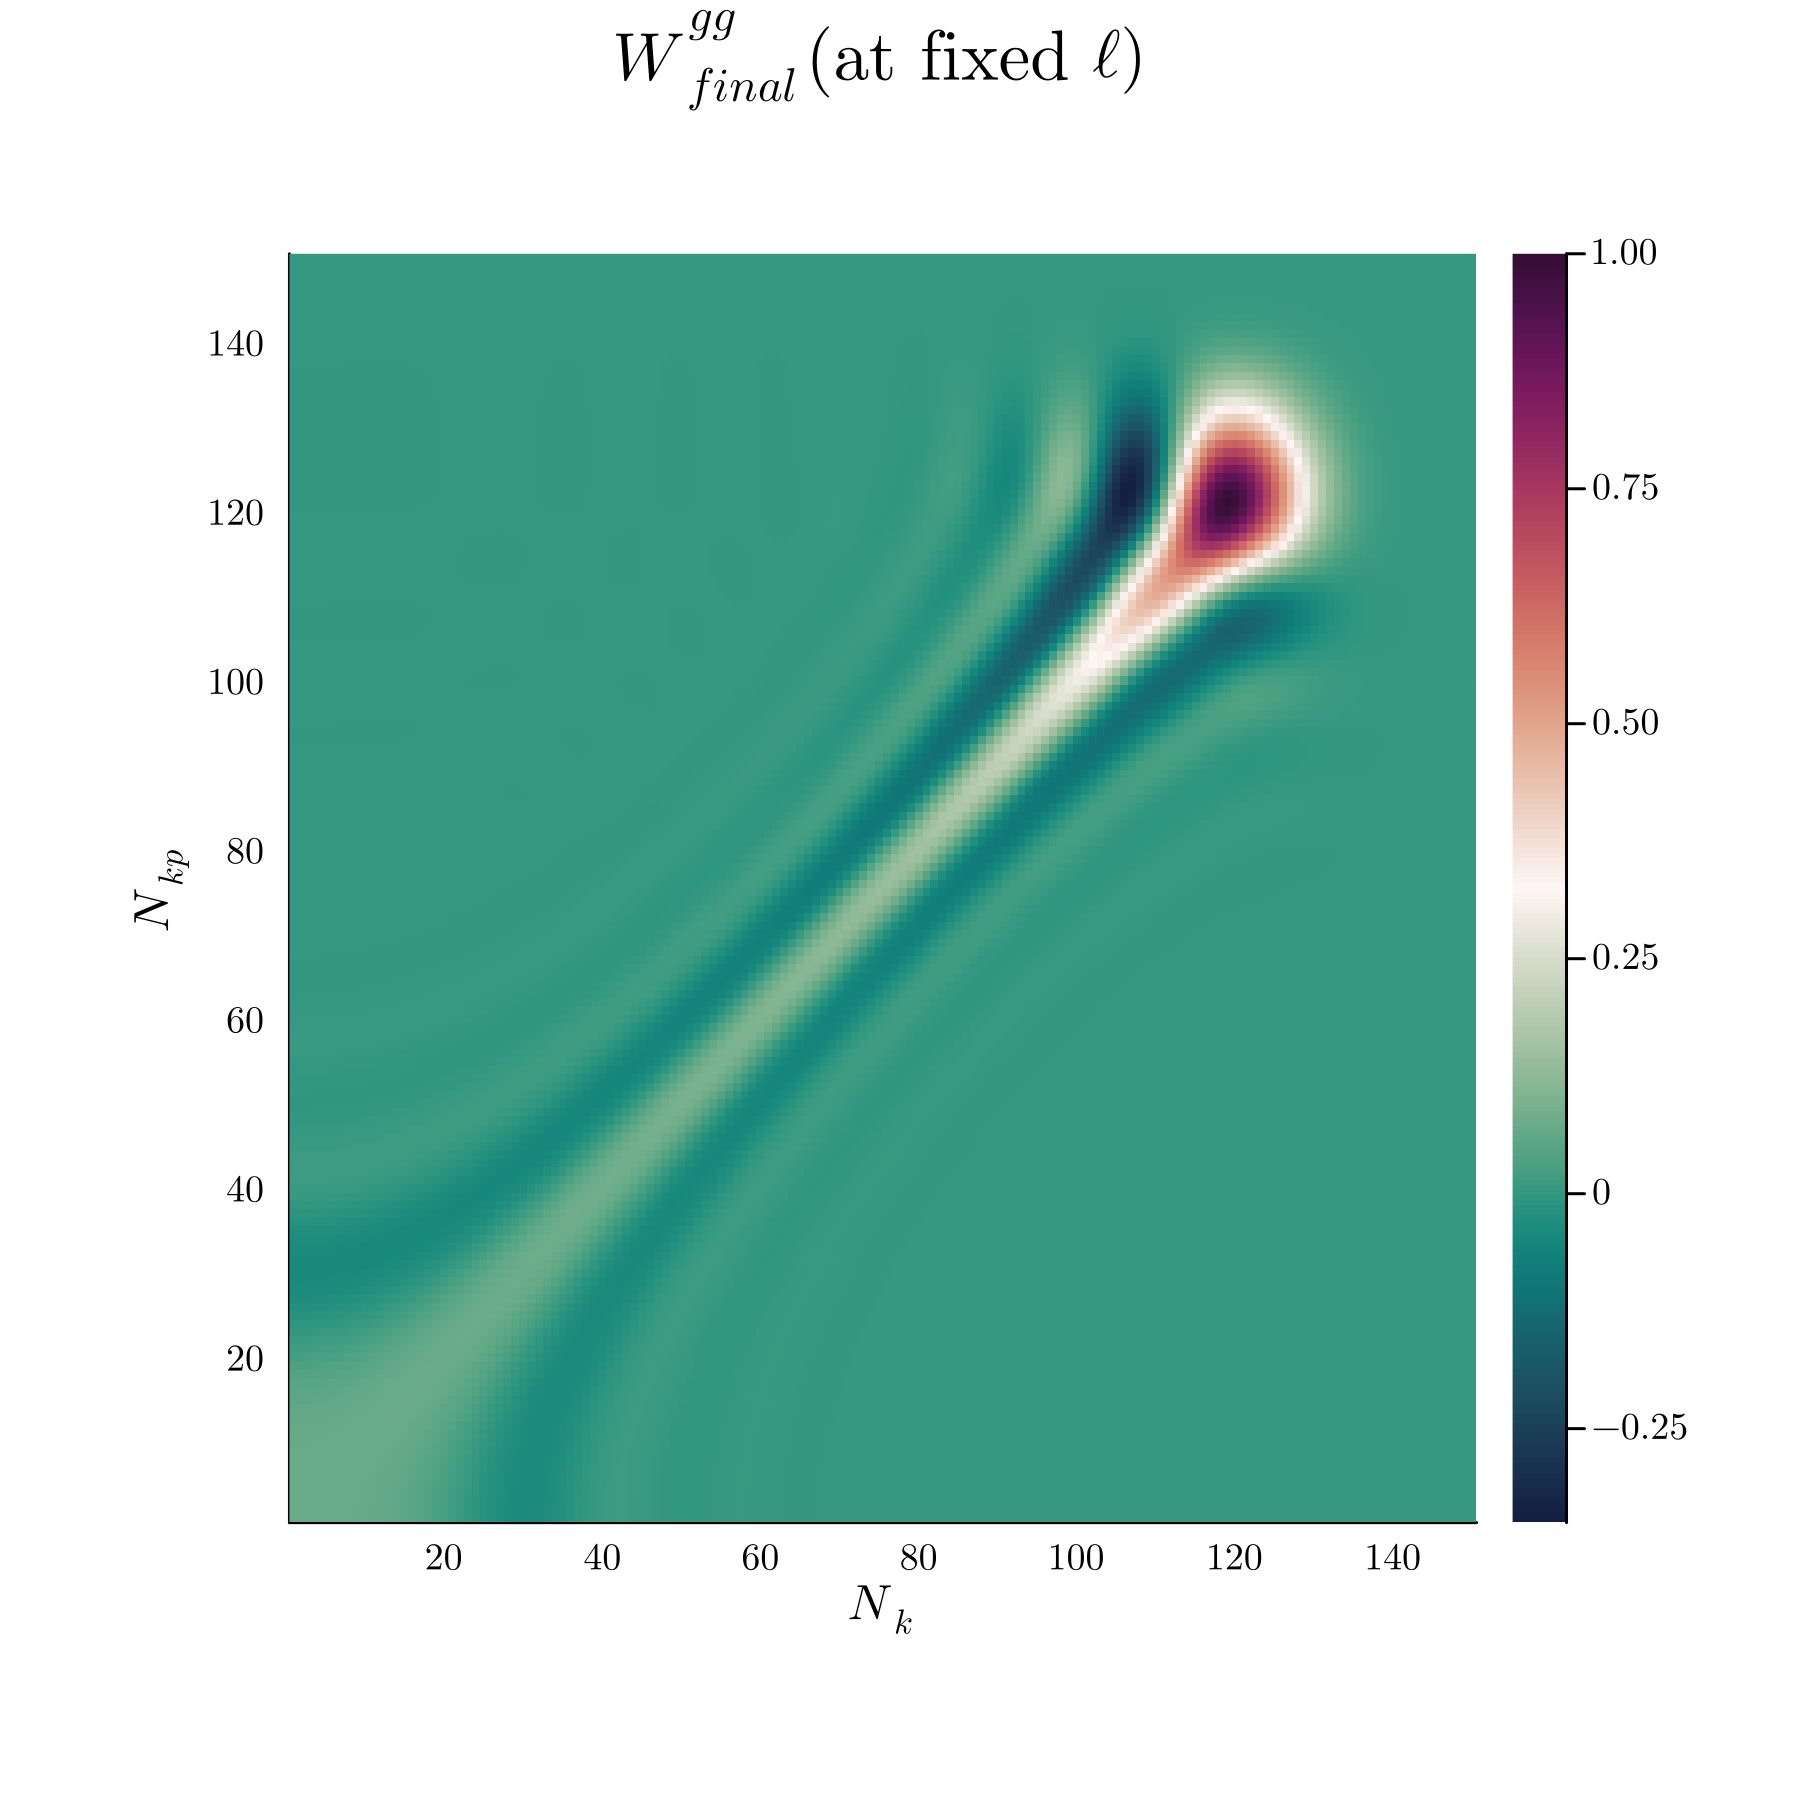

In [605]:
il = 1
if grids.sorting == true
    heatmap(1:grid_data.Nk, 1:grid_data.Nkp, W_final_gal[il,:,:]/maximum(W_final_gal[il,:,:]), 
        title = L"W_{final}^{gg}"*"(at fixed "*L"ℓ)", 
        xlabel = L"N_k", ylabel = L"N_{kp}", 
        colorbar = true, c = plot_theme.c, size = plot_theme.size_heatmap; plot_theme.shared_style...
        )
else
    heatmap(1:grid_data.Nk, 1:grid_data.Nkp, W_final_gal[il,:,:]/maximum(W_final_gal[il,:,:]), 
        title = L"W_{final}^{gg}"*"(at fixed "*L"ℓ)", 
        xlabel = L"N_k", ylabel = L"N_{kp}", 
        #xscale = :log10, 
        #yscale = :log10,
        colorbar = true, 
        c = plot_theme.c, 
        size = plot_theme.size_heatmap; plot_theme.shared_style...
        )
end

In [606]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/heatmaps/heatmap_Nk_Nkp.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/Sl_plots/heatmaps/heatmap_Nk_Nkp.png"

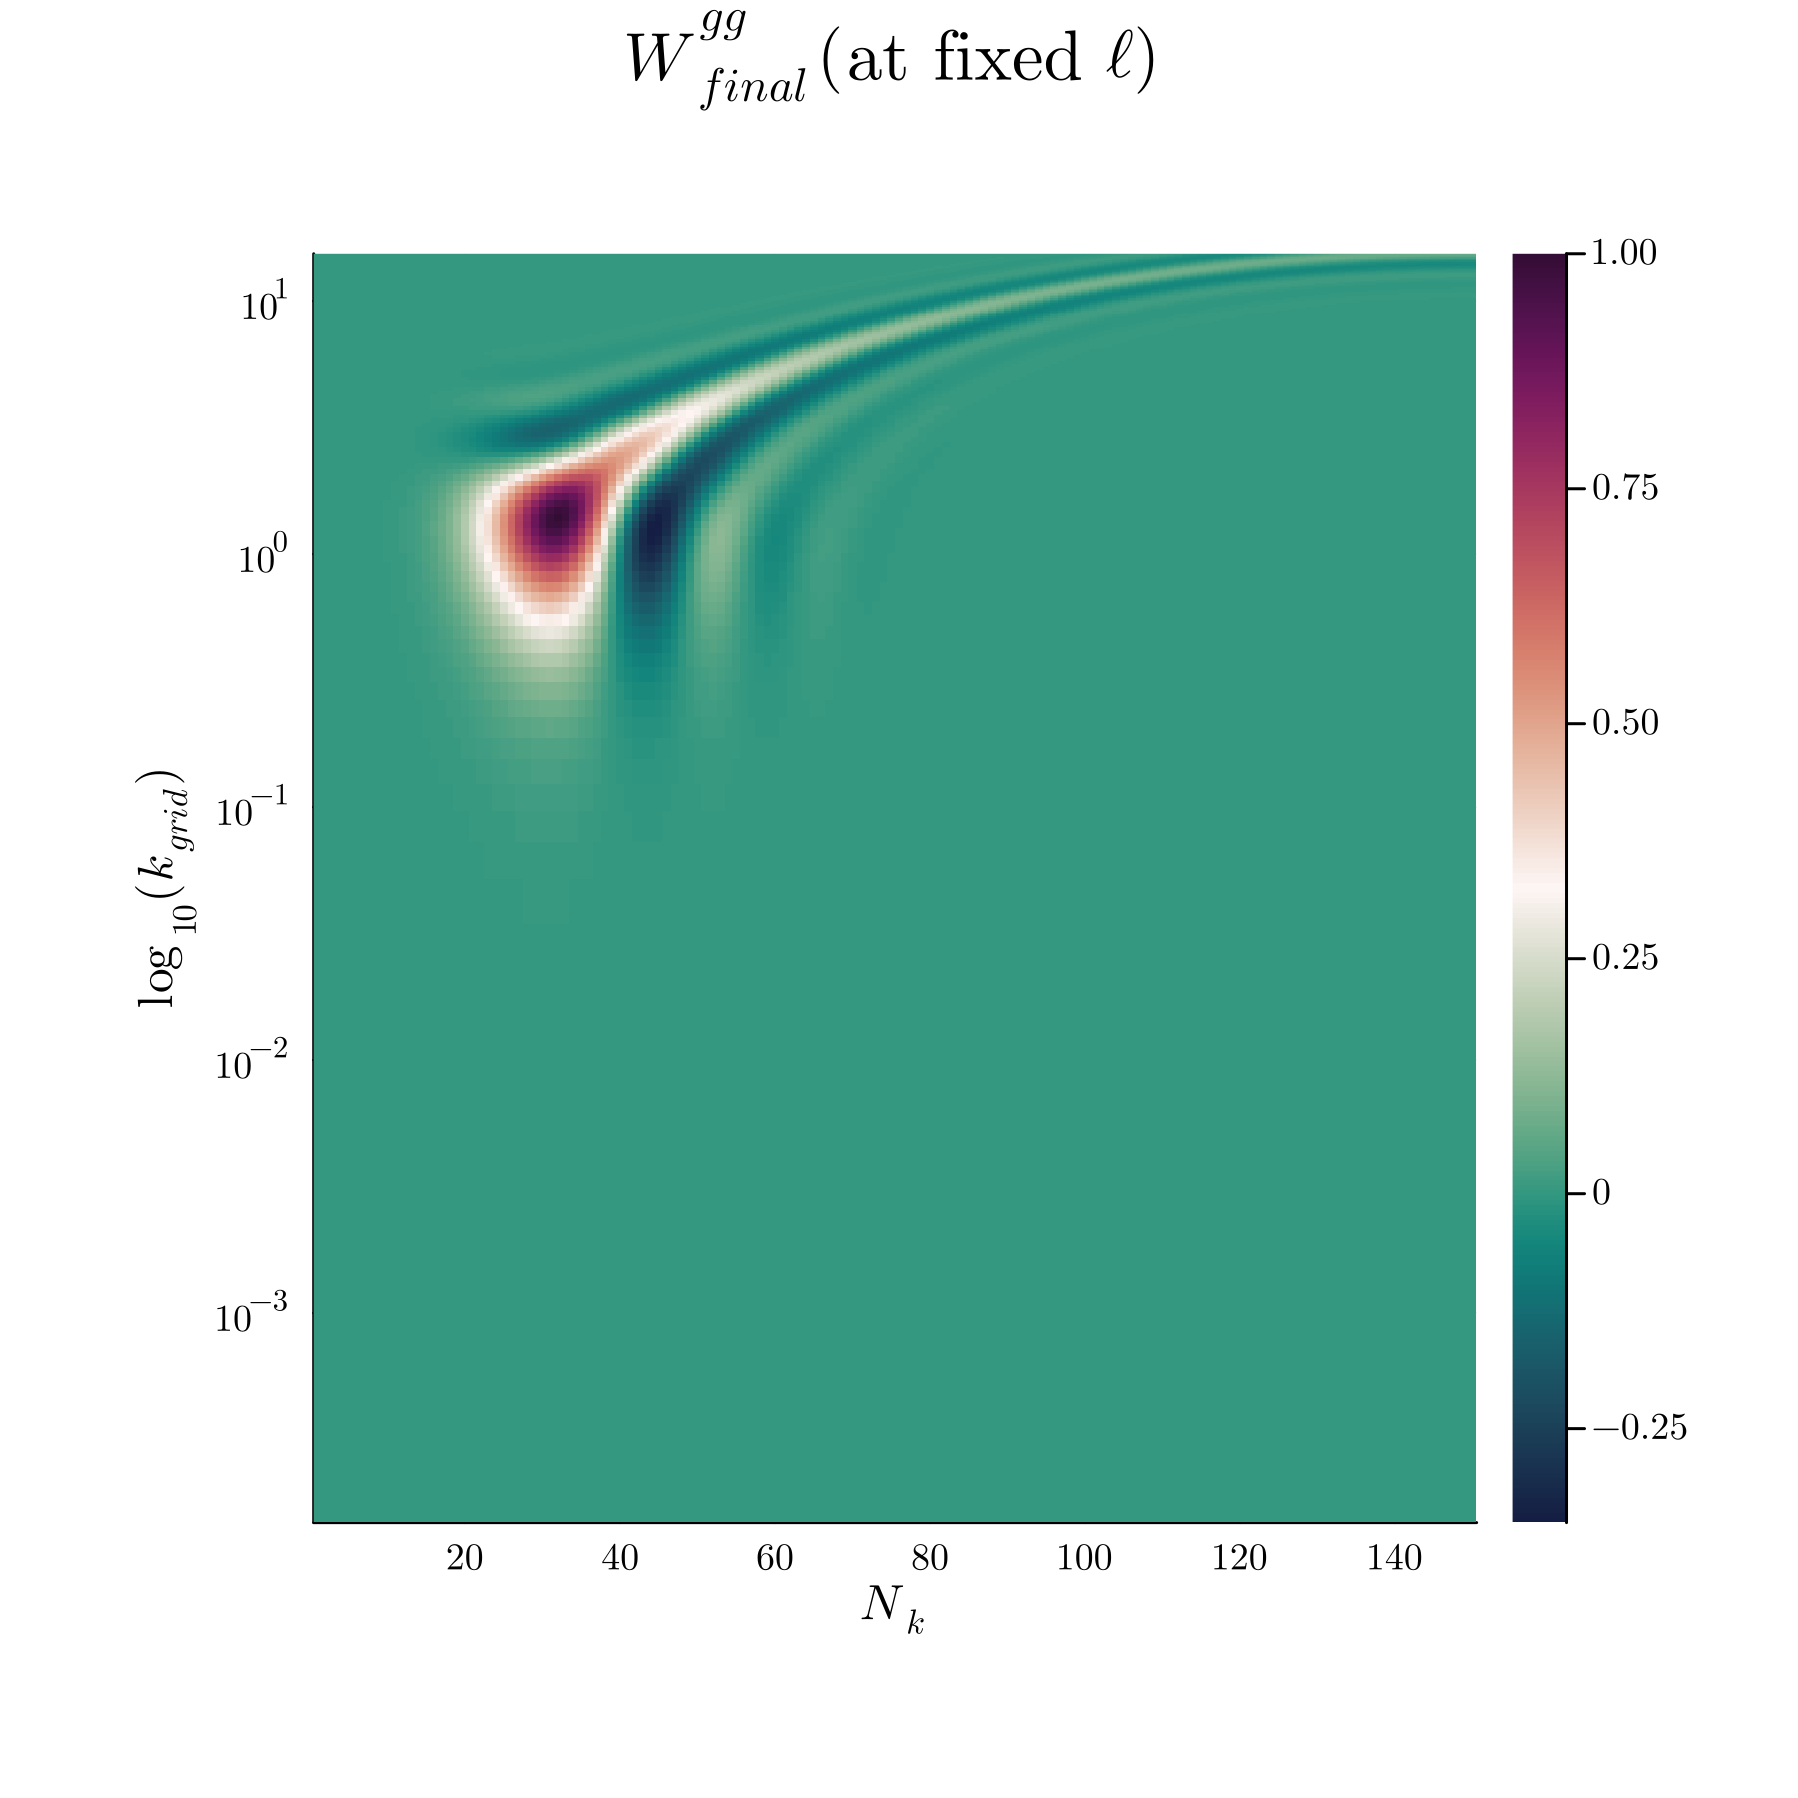

In [607]:
yticks_vals = 10.0 .^ (floor(log10(minimum(grids.k_grid))):ceil(log10(maximum(grids.k_grid))))
il =1
if grids.sorting == true
        heatmap(1:grid_data.Nk, 
                grids.kp_grid, 
                W_final_gal[il, :, :] / maximum(W_final_gal[il, :, :]), 
                title = L"W_{final}^{gg}"*L"("*"at fixed "*L"ℓ = 90)", 
                xlabel = L"N_k", ylabel = L"\log_{10}(k_{grid})",
                y_ticks = yticks_vals,
                #yscale = :log10, 
                #xscale = :log10,
                colorbar = true, c = plot_theme.c, size = plot_theme.size_heatmap; plot_theme.shared_style...
                )
else
        heatmap(1:grid_data.Nk, 
                grids.kp_grid[idx_p], 
                W_final_gal[il, idx, idx_p] / maximum(W_final_gal[il, idx, idx_p]), 
                title = L"W_{final}^{gg}"*L"("*"at fixed "*L"ℓ )", 
                xlabel = L"N_k", ylabel = L"\log_{10}(k_{grid})",
                y_ticks = yticks_vals,
                yscale = :log10, 
                #xscale = :log10,
                colorbar = true, c = plot_theme.c, size = plot_theme.size_heatmap; plot_theme.shared_style...
                )
end

In [608]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/heatmaps/heatmap_Nk_kp.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/Sl_plots/heatmaps/heatmap_Nk_kp.png"

In [609]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k_pk = pk_dict["k"]
z_pk = pk_dict["z"]
#Interpolating the power spectrum: Linear P(k) - Non-linear P(k)
y_pk = LinRange(log10(first(k_pk)),log10(last(k_pk)), length(k_pk))
x_pk = LinRange(first(z_pk), last(z_pk), length(z_pk))
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x_pk, y_pk))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x_pk, y_pk)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())
power_spectrum(k_pk, χ1, χ2) = @. sqrt(10^InterpPmm(grid_data.z_of_χ(χ1),log10(k_pk)) * 10^InterpPmm(grid_data.z_of_χ(χ2),log10(k_pk)))
power_spectrum_nl(k_pk, χ1, χ2) = @. sqrt(10^InterpPmm_nl(grid_data.z_of_χ(χ1),log10(k_pk)) * 10^InterpPmm_nl(grid_data.z_of_χ(χ2),log10(k_pk)))

power_spectrum_nl (generic function with 1 method)

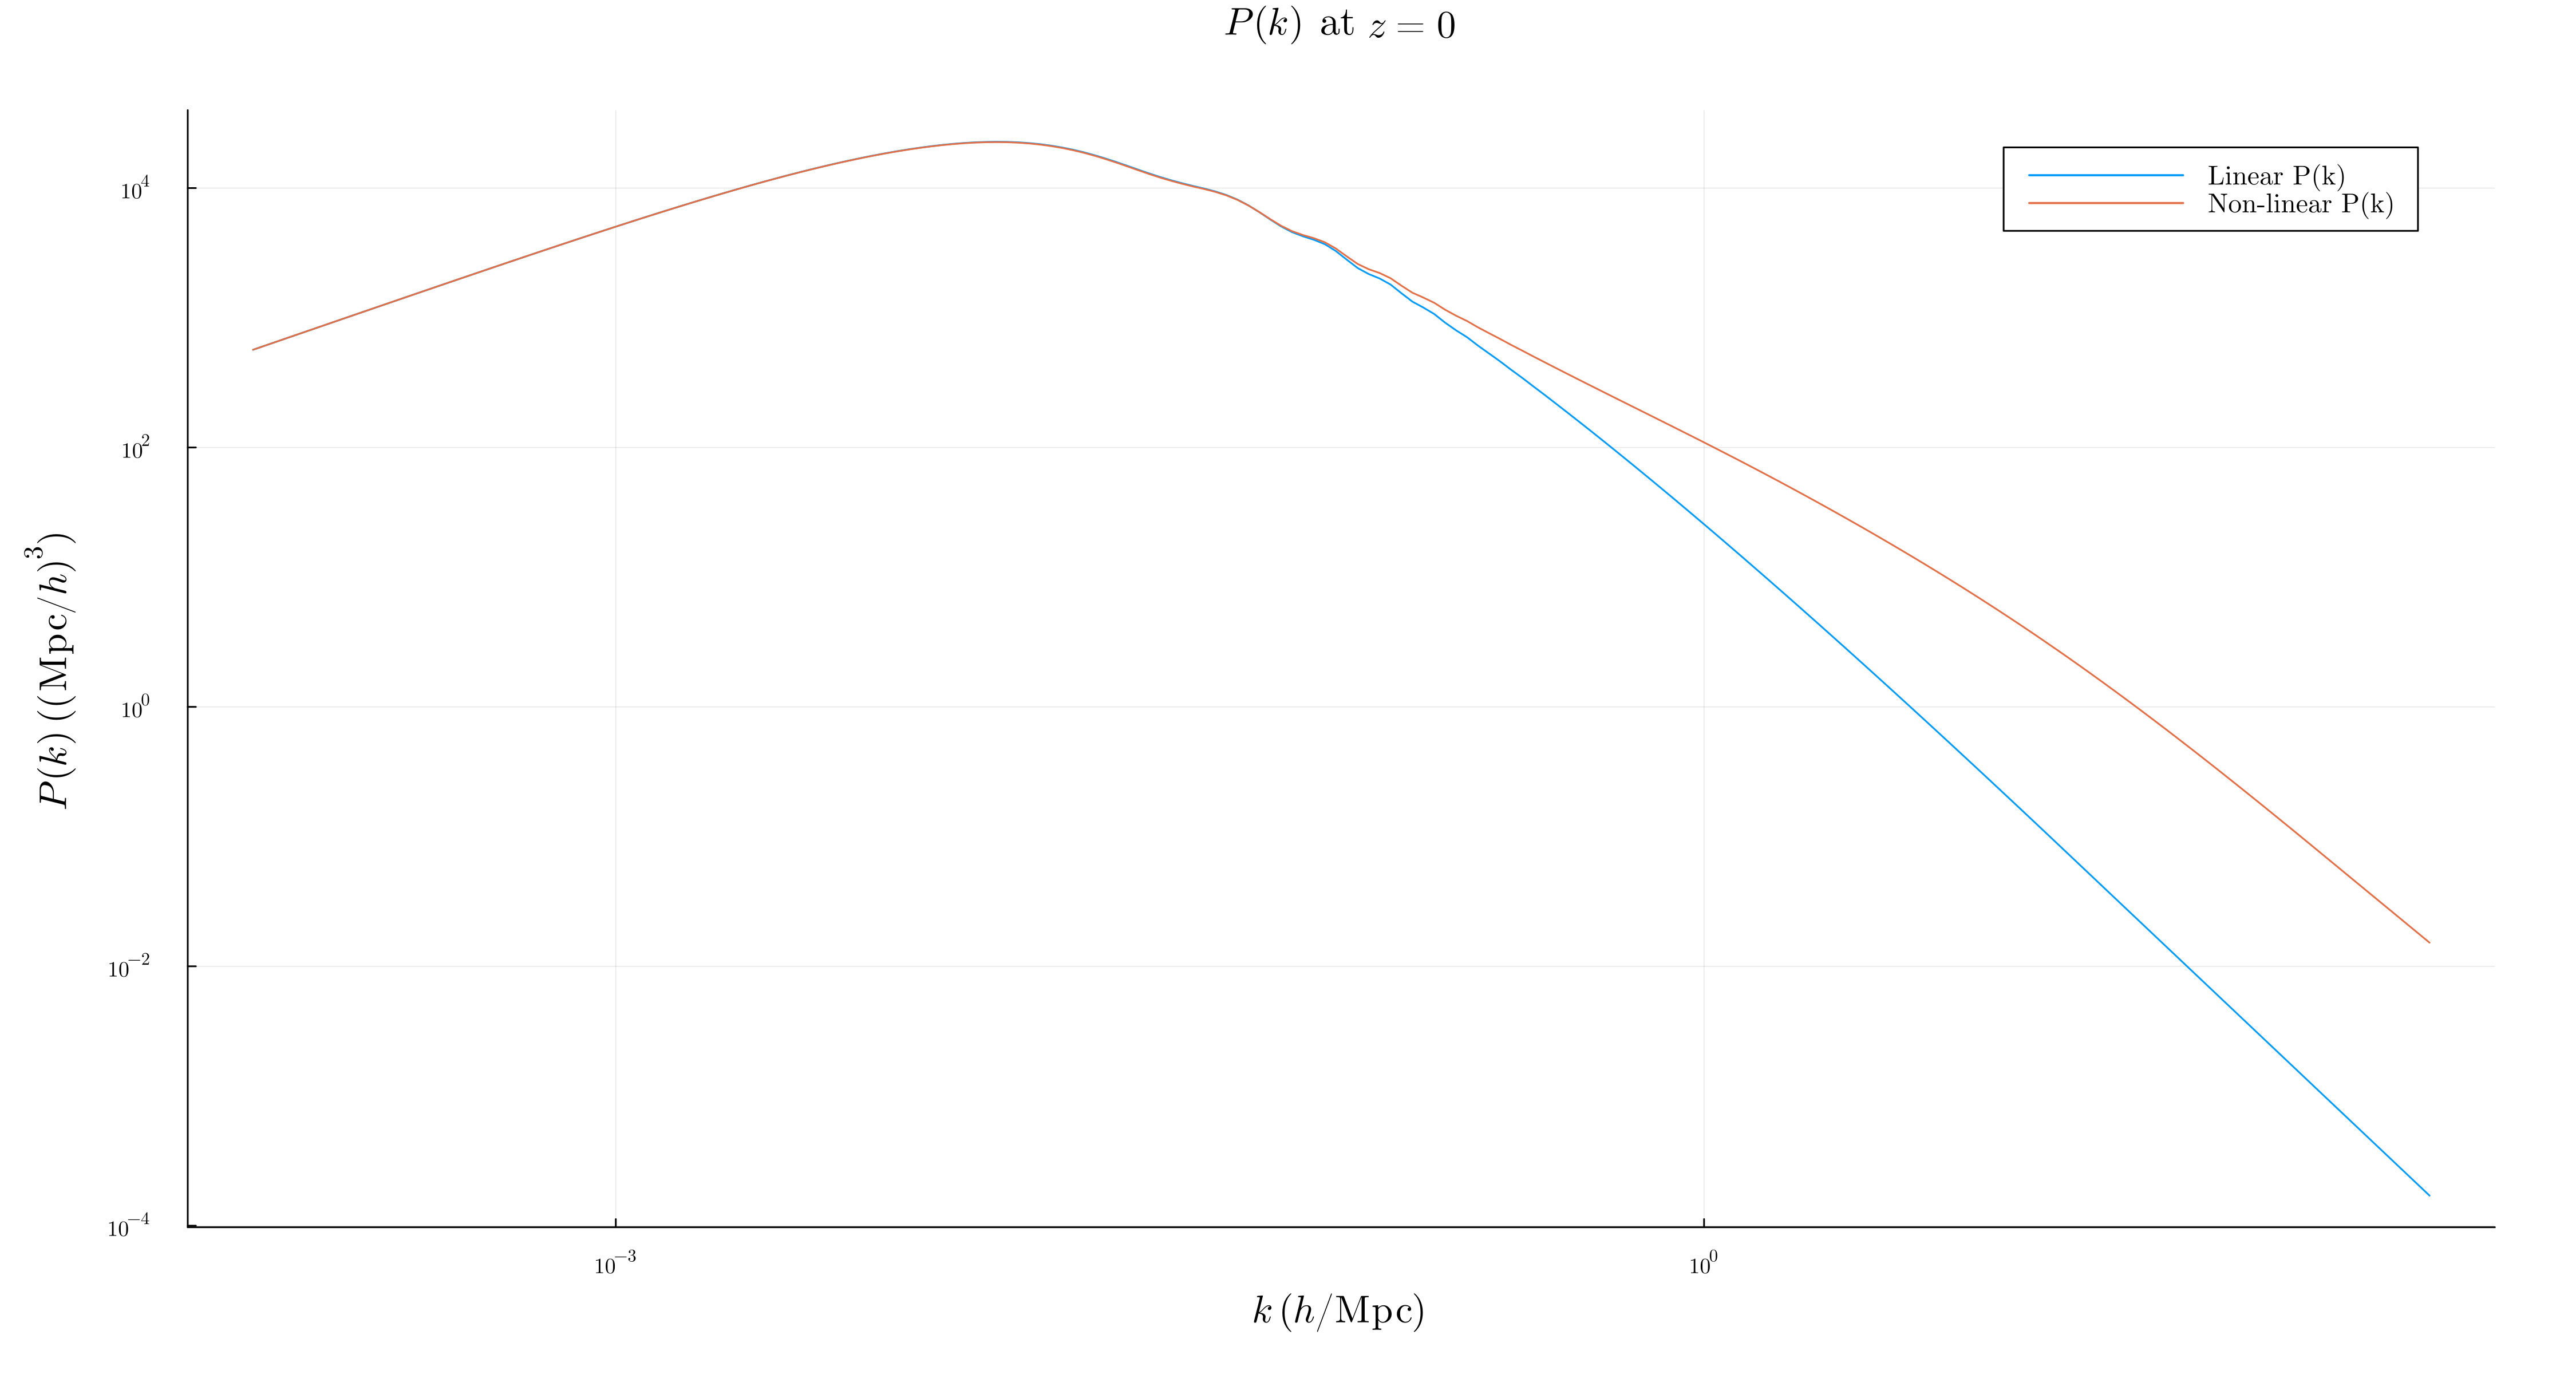

In [610]:
plot(k_pk, power_spectrum.(k_pk, 26.0, 7000.0), 
     label="Linear P(k)", 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$ at $z=0$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15)
plot!(k_pk, power_spectrum_nl.(k_pk, 26.0, 7000.0), 
      label="Non-linear P(k)", 
      xscale=:log10, 
      yscale=:log10, size=plot_theme.size_Cl; plot_theme.shared_style...
      )

get_clencurt_grid produces the node of Clenshaw-Curtis mapped on [$k_{min}$, $k_{max}$]. \
get_clencurt_weights produces the corresponding quadrature weights scaled to the interval [-1,1]. \

In [611]:
# function trapz_weights(k)
#     nk = length(k)
#     @assert nk ≥ 2
#     w = fill(k[2] - k[1], nk)
#     w[1] /= 2
#     w[end] /= 2
#     return w
# end

Pk_grid = power_spectrum.(grids.k_grid, grid_data.xmin, grid_data.xmax)

if grids.sorting == true
  #w_k = trapz_weights(grids.k_grid)
  w_k = reverse(Blast.get_clencurt_weights(grid_data.kmin, grid_data.kmax, grid_data.Nk))
  weight_gal = w_k .* grids.k_grid.^2 .* Pk_grid
else
  #w_k = trapz_weights(grids.k_grid)
  w_k = Blast.get_clencurt_weights(grid_data.kmin, grid_data.kmax, grid_data.Nk)
  weight_gal = w_k .* grids.k_grid.^2 .* Pk_grid
end
;

when plotting C(l) is doesn't matter that I define the plot with a grid in k which is decreasing (like k_grid). In the heatmap on the other hand, the axis must have ordered quantities.

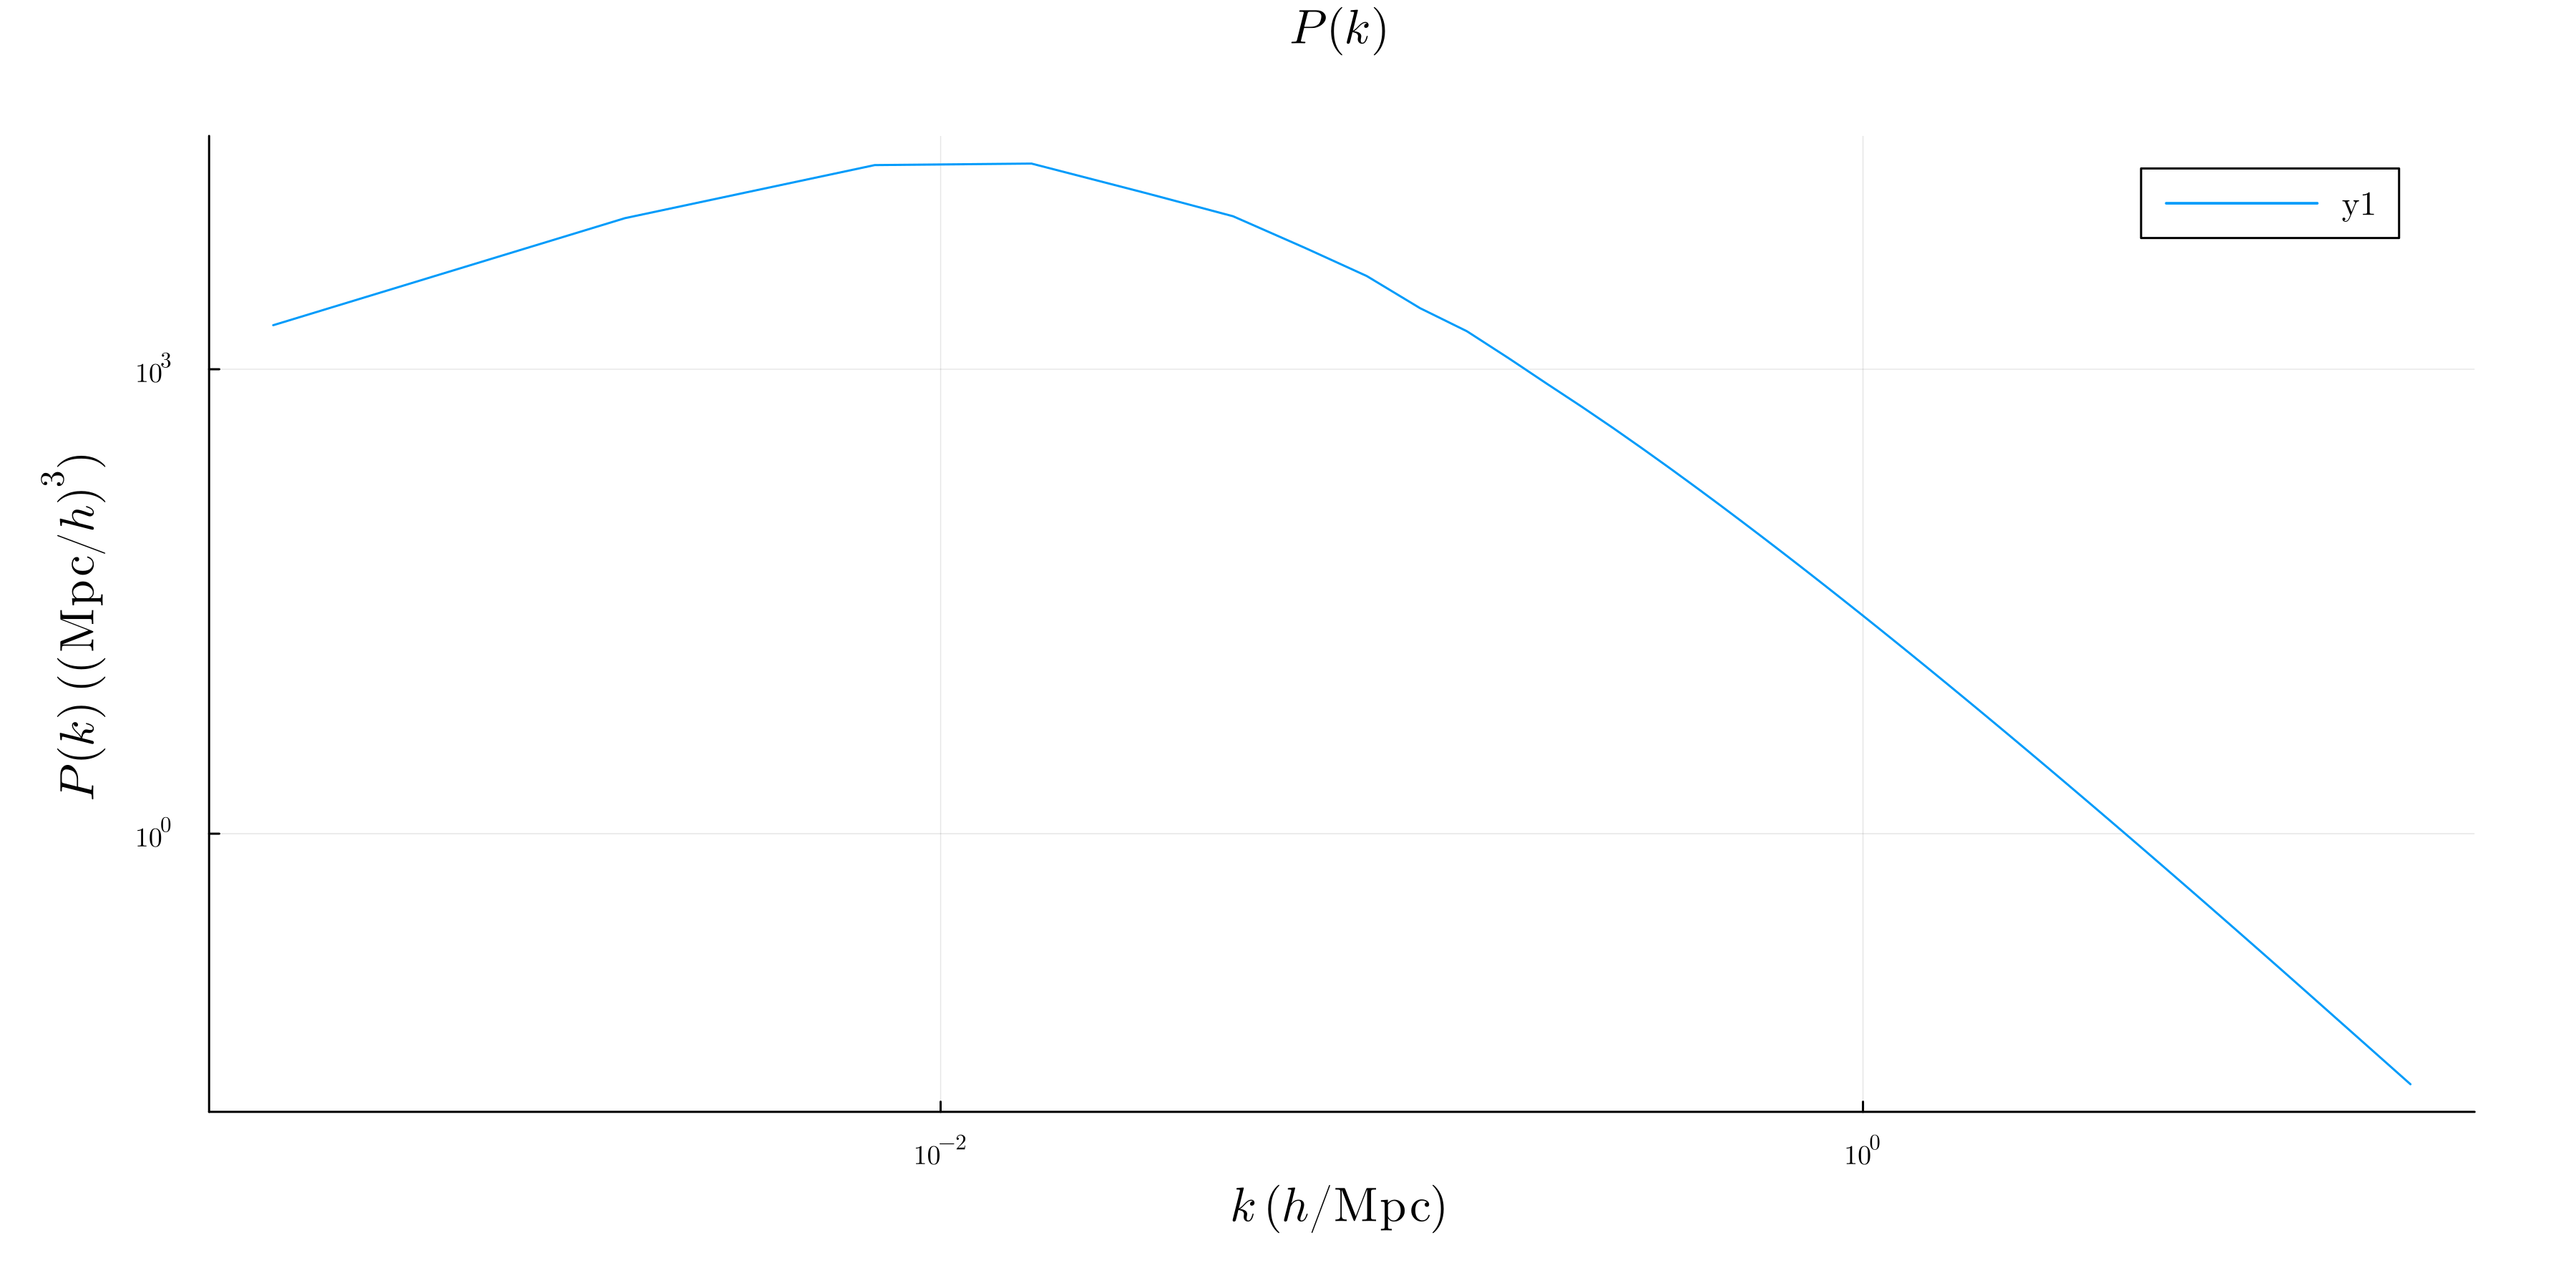

In [612]:
plot(grids.k_grid, Pk_grid, 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15, size=plot_theme.size_plot; plot_theme.shared_style...
     )

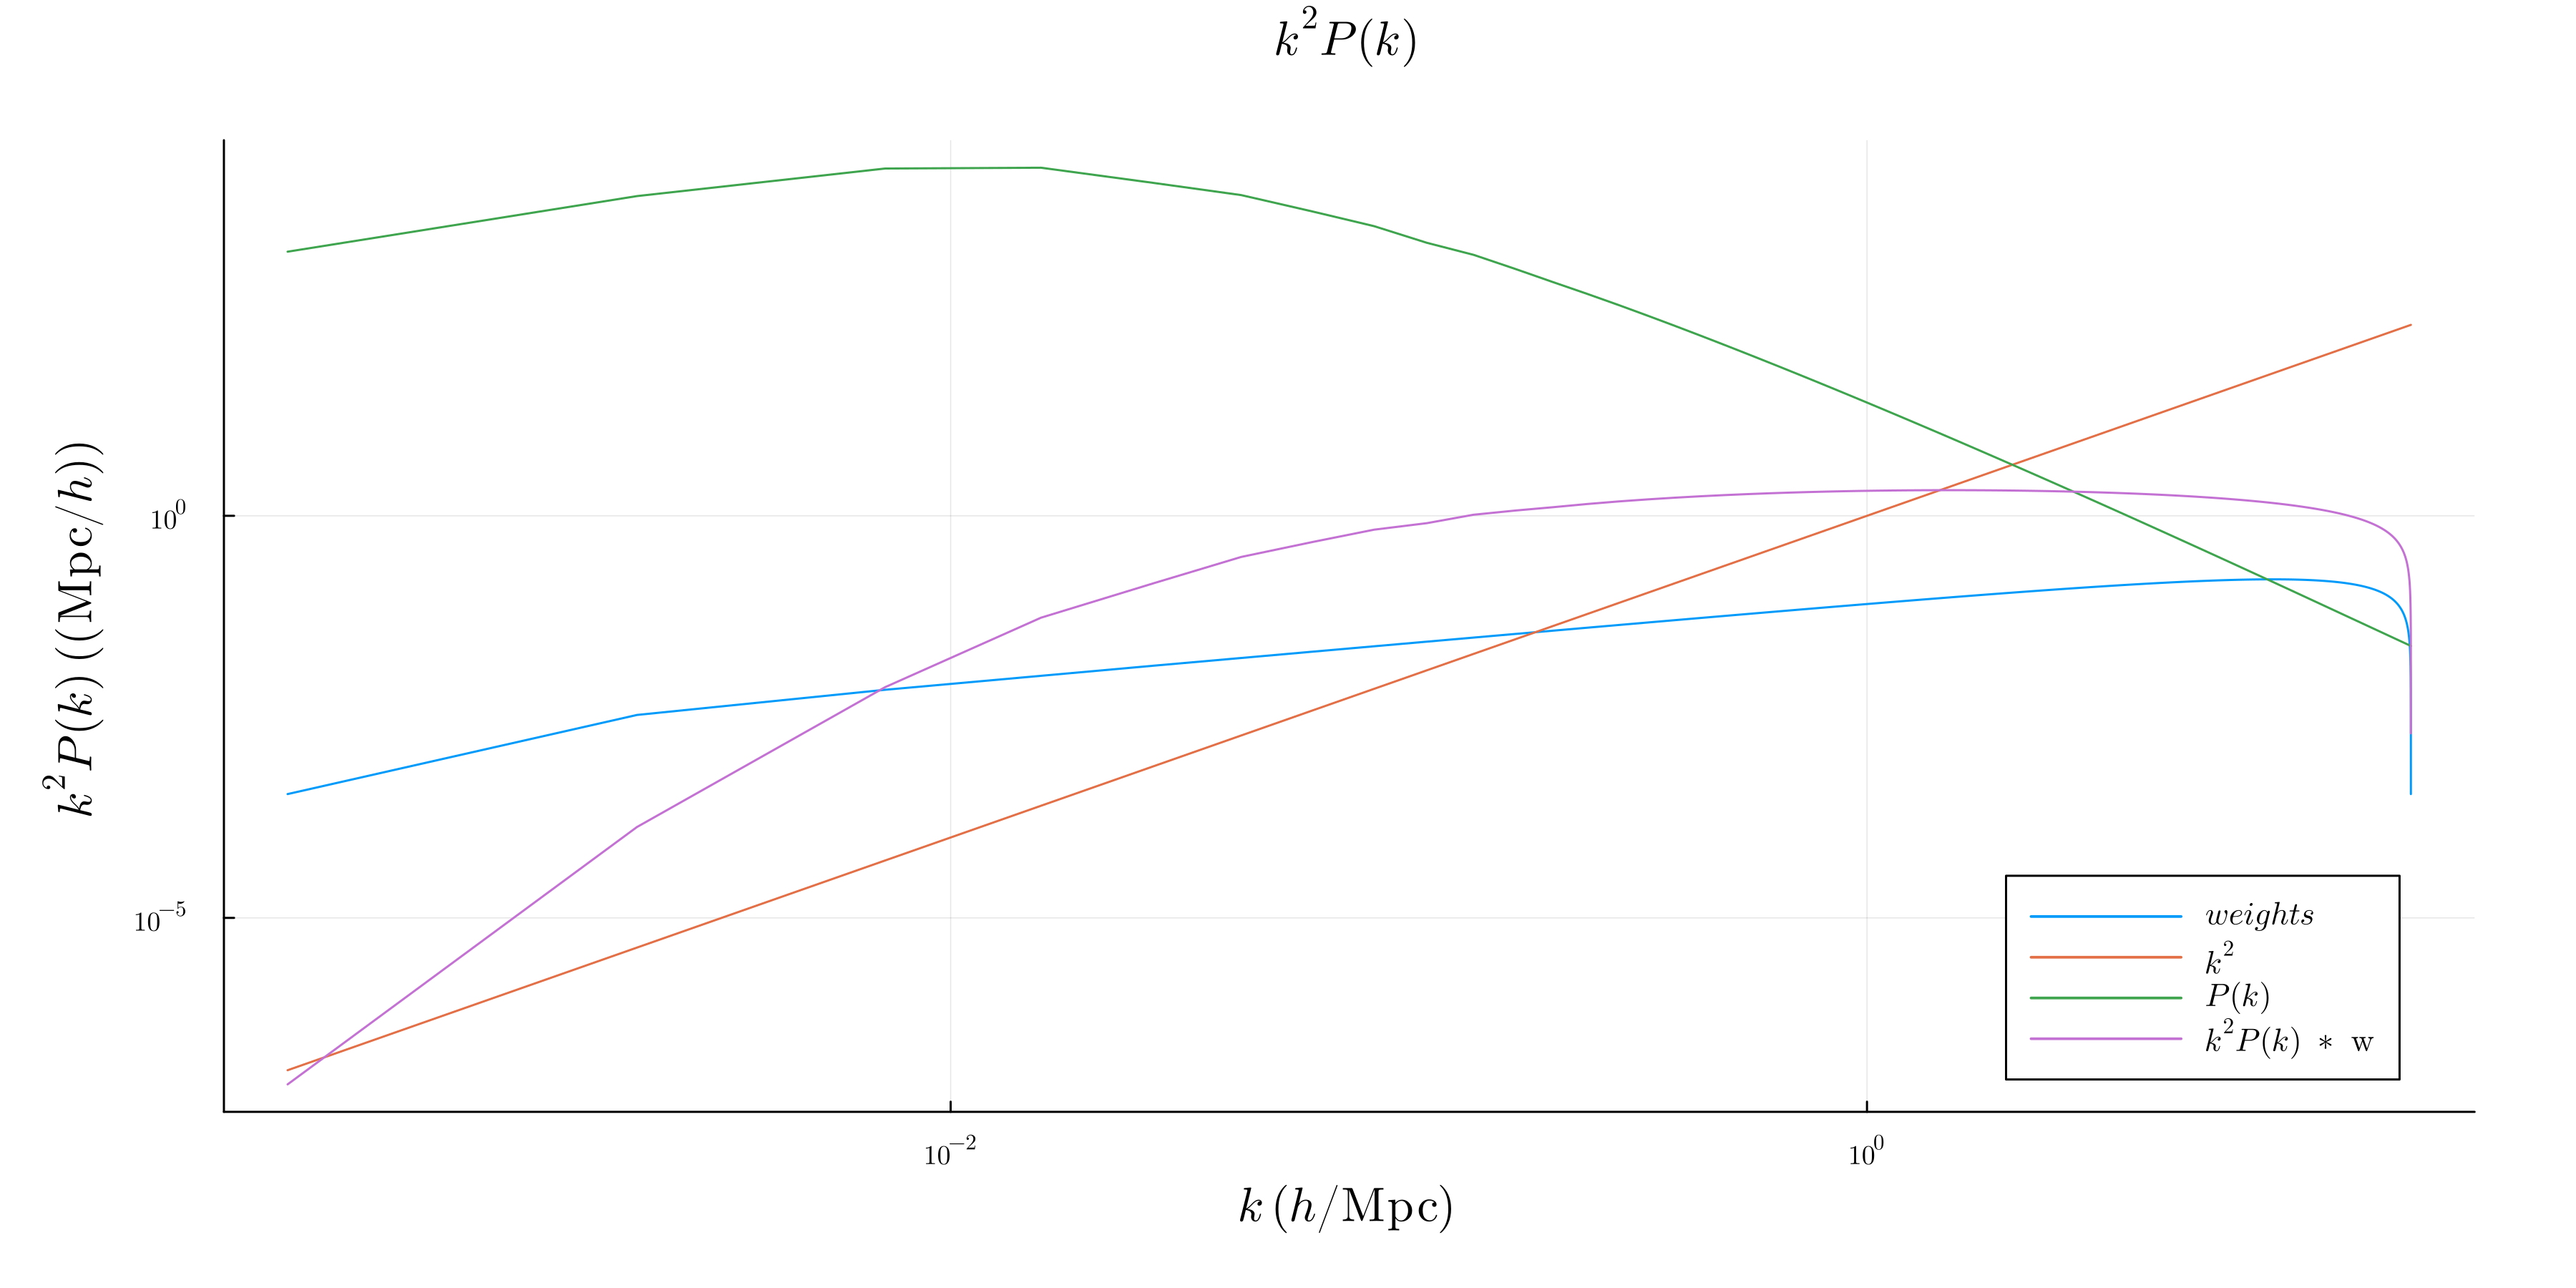

In [613]:
plot(grids.k_grid, w_k, label = L"weights", 
     xlabel = L"k \; (h/\mathrm{Mpc})", size=plot_theme.size_Cl; plot_theme.shared_style...
     )
plot!(grids.k_grid, grids.k_grid.^2, label = L"k^2",
     xlabel = L"k \; (h/\mathrm{Mpc})", size=plot_theme.size_Cl; plot_theme.shared_style...
     )
plot!(grids.k_grid, Pk_grid, label = L"P(k)", 
     xlabel = L"k \; (h/\mathrm{Mpc})", size=plot_theme.size_Cl; plot_theme.shared_style...
     )
plot!(grids.k_grid, weight_gal, 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$k^2 P(k)$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$k^2 P(k) \; ((\mathrm{Mpc}/h))$", 
     label =L"$k^2 P(k) \; * \; \mathrm{w} $",
     labelfontsize=15, legendposition = :bottomright, size=plot_theme.size_plot; plot_theme.shared_style...
     )

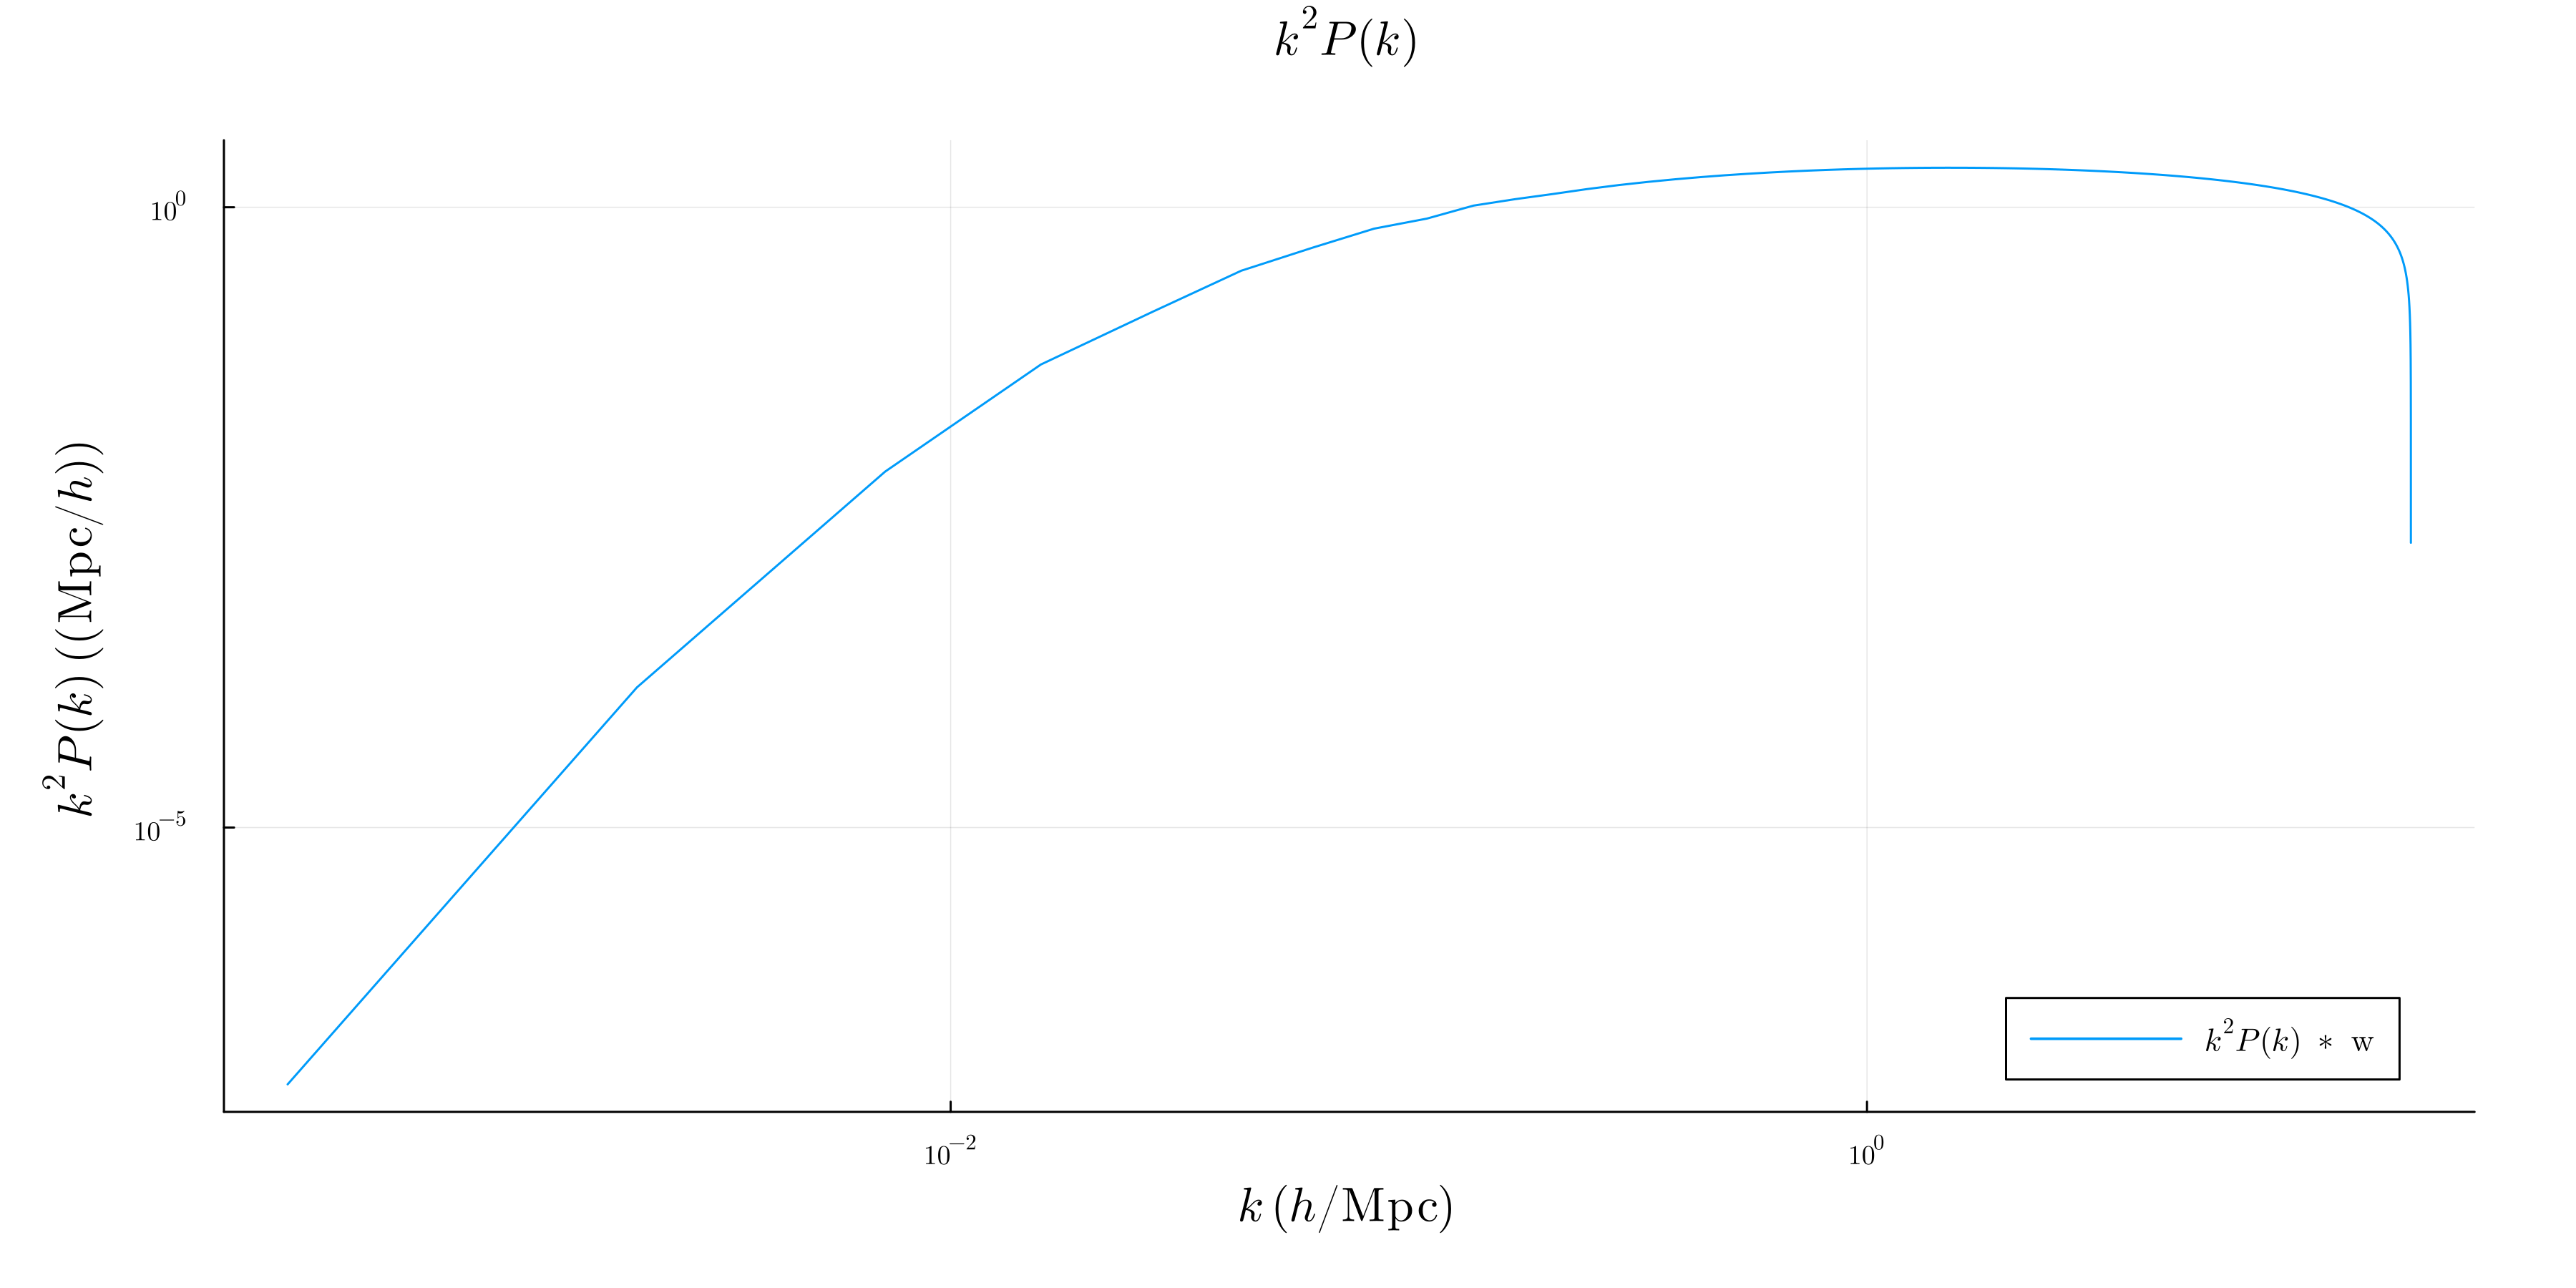

In [614]:
plot(grids.k_grid, weight_gal, 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$k^2 P(k)$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$k^2 P(k) \; ((\mathrm{Mpc}/h))$", 
     label =L"$k^2 P(k) \; * \; \mathrm{w} $",
     labelfontsize=15, legendposition = :bottomright, size=plot_theme.size_plot; plot_theme.shared_style...
     )

In [615]:
abstract type AbstractProbe end
struct Galaxy <: AbstractProbe end
struct Shear <: AbstractProbe end
factorial_frac(ℓ) = (ℓ + 2.0) * (ℓ + 1.0) * ℓ * (ℓ - 1.0)
get_ell_prefactor(::Galaxy, ::Galaxy, ℓ) = @. (2 / π) * ones(length(ℓ))
get_ell_prefactor(::Galaxy, ::Shear,  ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Galaxy, ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Shear,  ℓ) = @. (2 / π) * factorial_frac(ℓ)
pref_gg = get_ell_prefactor(Galaxy(), Galaxy(), grid_data.ℓ)
pref_gg = reduce(vcat, pref_gg)
pref_gs = get_ell_prefactor(Galaxy(), Shear(), grid_data.ℓ)
pref_gs = reduce(vcat, pref_gs)
pref_gg = reduce(vcat, pref_gg)
pref_ss = get_ell_prefactor(Shear(), Shear(), grid_data.ℓ)
pref_ss = reduce(vcat, pref_ss);

In [616]:
println("SIZES")
println("weight_gal -> ", size(weight_gal))
println("W_final_gal -> ", size(W_final_gal))
println("pref_gg -> ", size(pref_gg))

SIZES
weight_gal -> (150,)
W_final_gal -> (100, 150, 150)
pref_gg -> (100,)


In [617]:
S_lkk_gg = zeros(Float64, size(W_final_gal, 3), size(W_final_gal, 3), length(grid_data.ℓ))
@tullio S_lkk_gg[kp, kpp, li] = pref_gg[li] * weight_gal[k] * W_final_gal[li, k, kp] * W_final_gal[li, k, kpp]
#npzwrite(joinpath(paths.quantity_subdir, "Sl/S_lkk_gg.npy"), S_lkk_gg)
println("Size of S_l (kp, kpp) (gal-gal): \n(grid_data.Nk, grid_data.Nkp, NL) -> ", size(S_lkk_gg))
;

Size of S_l (kp, kpp) (gal-gal): 
(grid_data.Nk, grid_data.Nkp, NL) -> (150, 150, 100)


wavenumber k as a function of $\ell$ through $k \approx \frac{\ell+0.5}{\chi}$ ?

In [618]:
#npzwrite(joinpath(paths.quantity_subdir, "Sl/S_lkk_gg.npy"), S_lkk_gg)

In [619]:
xref = (grid_data.xmax - grid_data.xmin ) * 0.5
ℓ_to_k = ℓ -> ℓ ./ xref
ℓ_ticks = 1:50:200
k_ticks = ℓ_to_k.(ℓ_ticks)
k_ticklabels = [string(round(k, digits=3)) for k in k_ticks];

In [620]:
println(grids.k_grid[4])

15.369232368966493


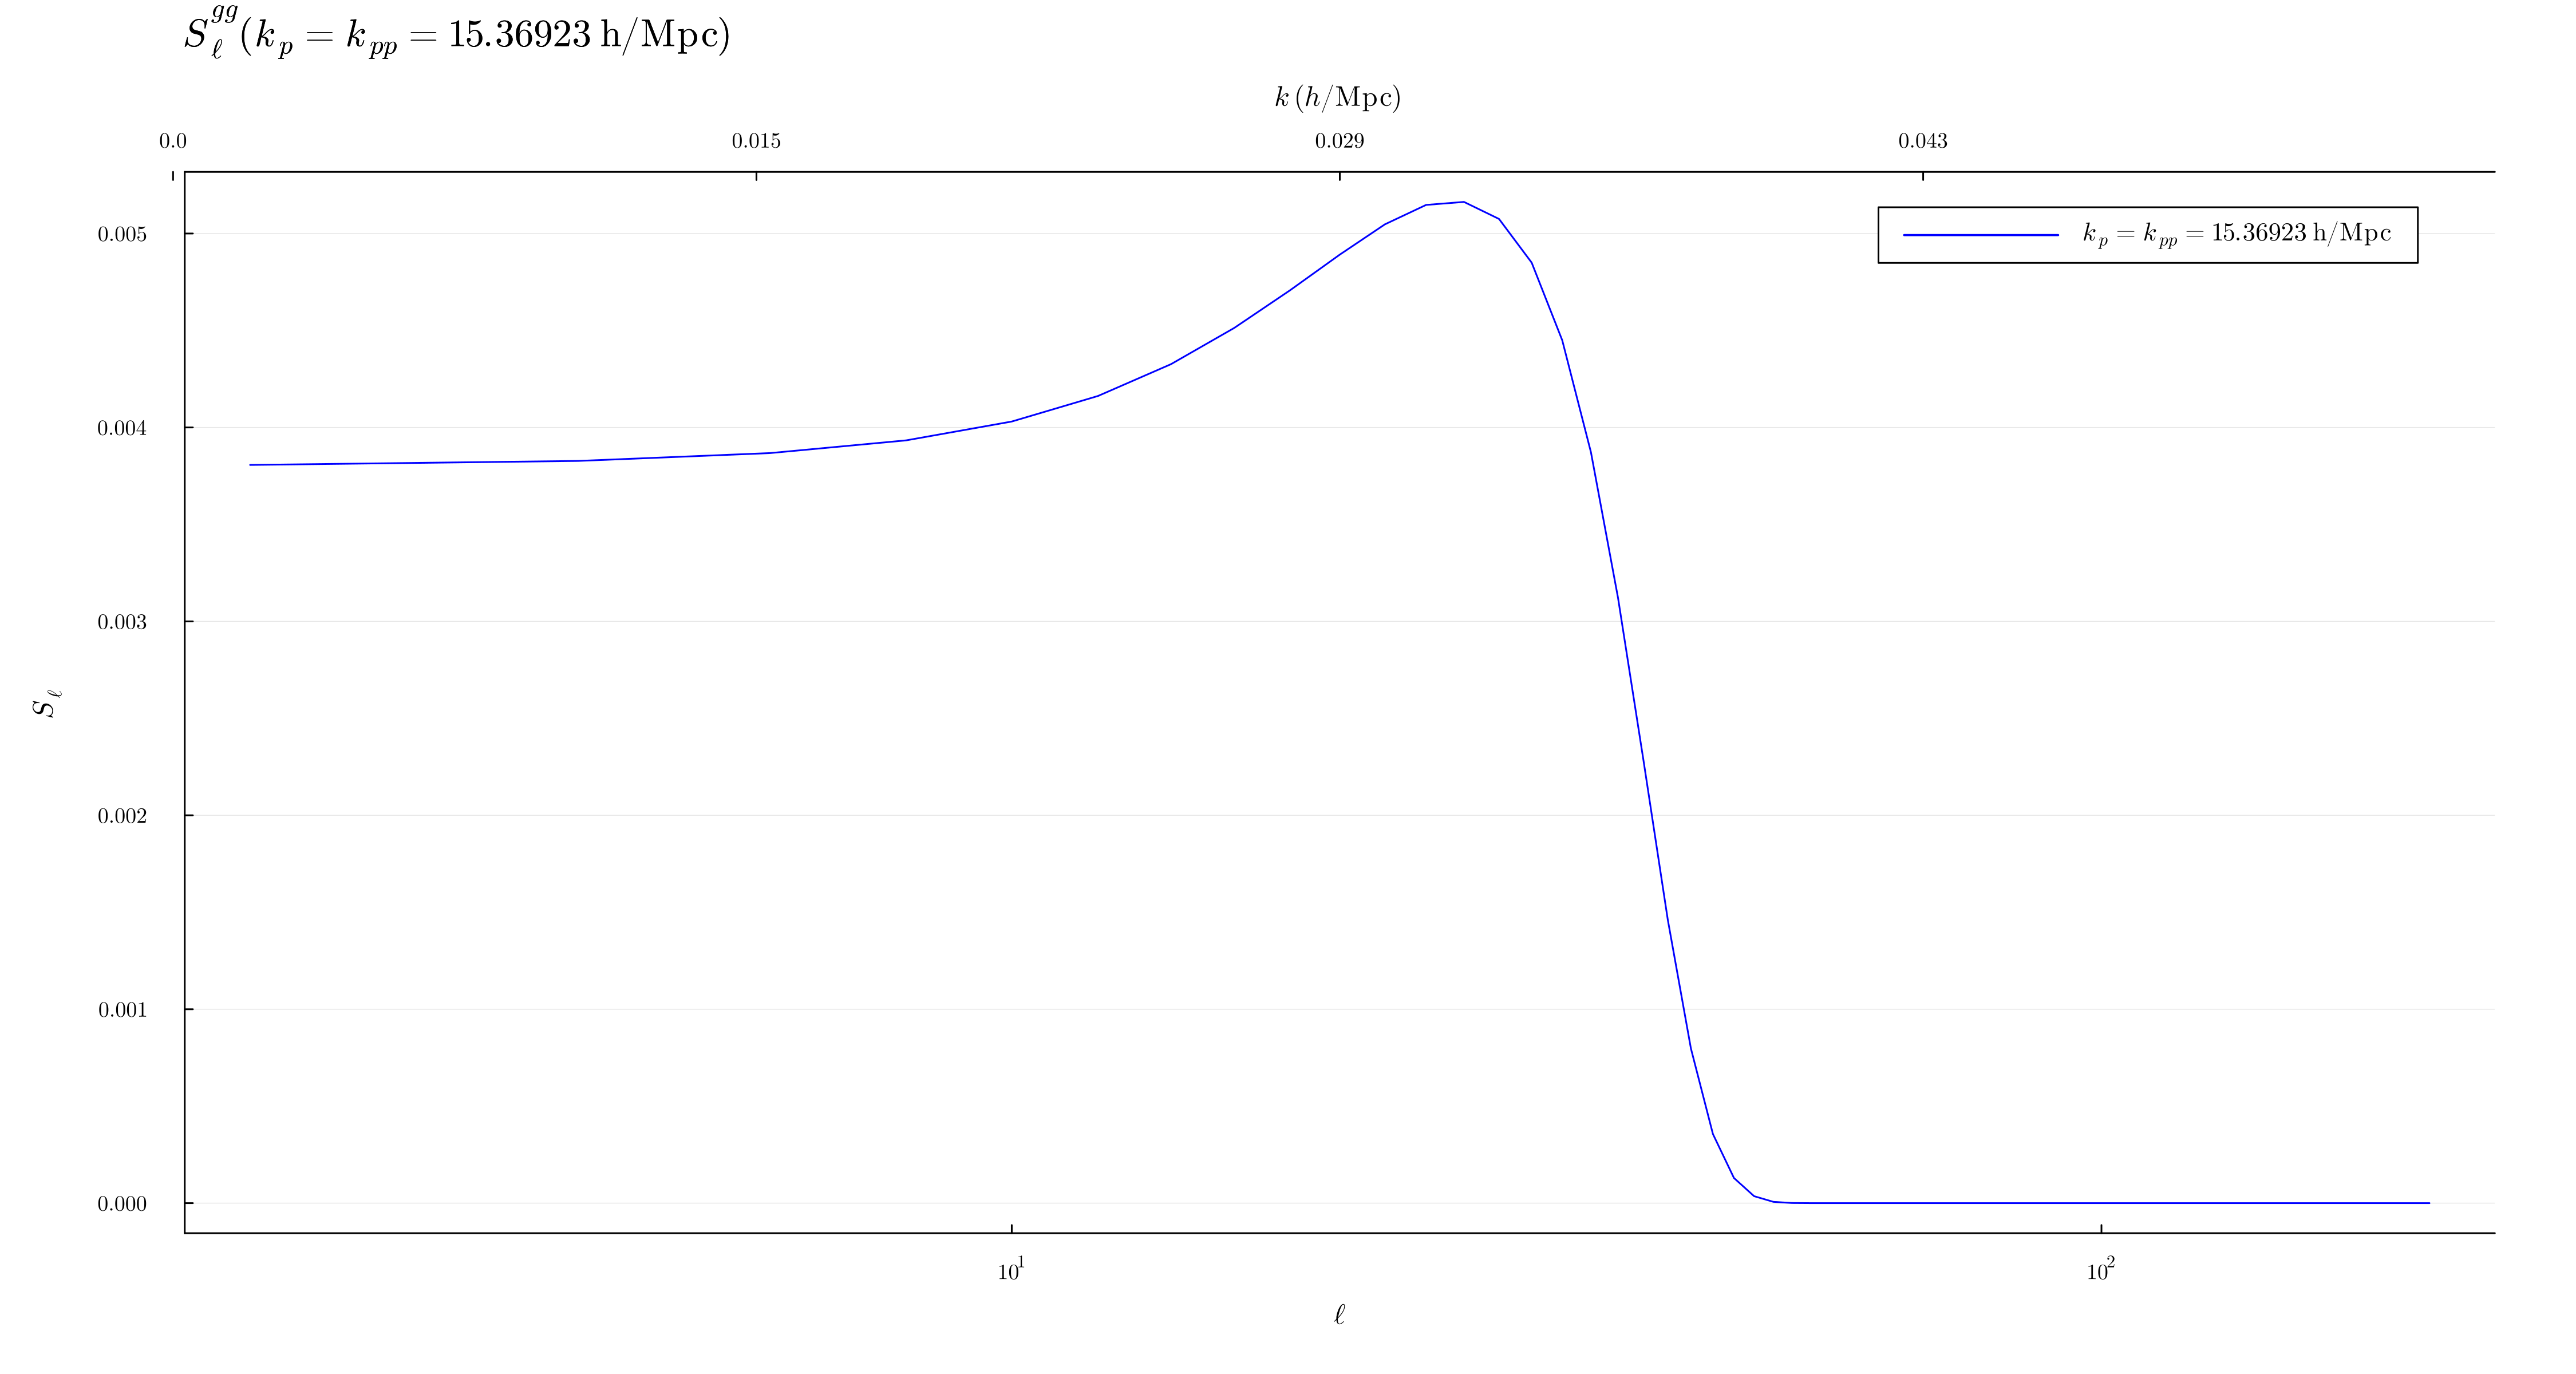

In [640]:
i = 4
j = i 
k_p = grids.k_grid[i]
k_pp = grids.kp_grid[j]
plot(grid_data.ℓ, S_lkk_gg[i,j,:],
      color = :blue,
      label = label = L"k_p = k_{pp} = %$(round(k_p, digits=5)) \; \mathrm{h/Mpc}")
      
plot!(xaxis = L"\ell",
      ylabel = L"S_\ell"
      ,xscale = :log10,
      )
plot!(twiny(),
      xaxis = L"k \; (h/\mathrm{Mpc})",
      xticks = (ℓ_ticks, k_ticklabels),
      xlims = (minimum(grid_data.ℓ), maximum(grid_data.ℓ)),
      label = ""
     )
plot!(label = "Beyond BLAST", 
      size=plot_theme.size_Cl,
      title = L"S_{\ell}^{gg} (k_p = k_{pp} = %$(round(k_p, digits=5)) \; \mathrm{h/Mpc})",
      titlefontsize = 20,
      titleposition = :left ; plot_theme.shared_style...)

In [622]:
#savefig(joinpath(paths.plot_subdir, "Sl_plots/ell_vs_Sl_kp_kpp_$i.png"))

ℓ = 2.0
ℓ is fixed always
k_1 (k_p) varies at each iteration
k_2 (k_pp) = 0.01574015850603505 h/Mpc - fixed, stays there


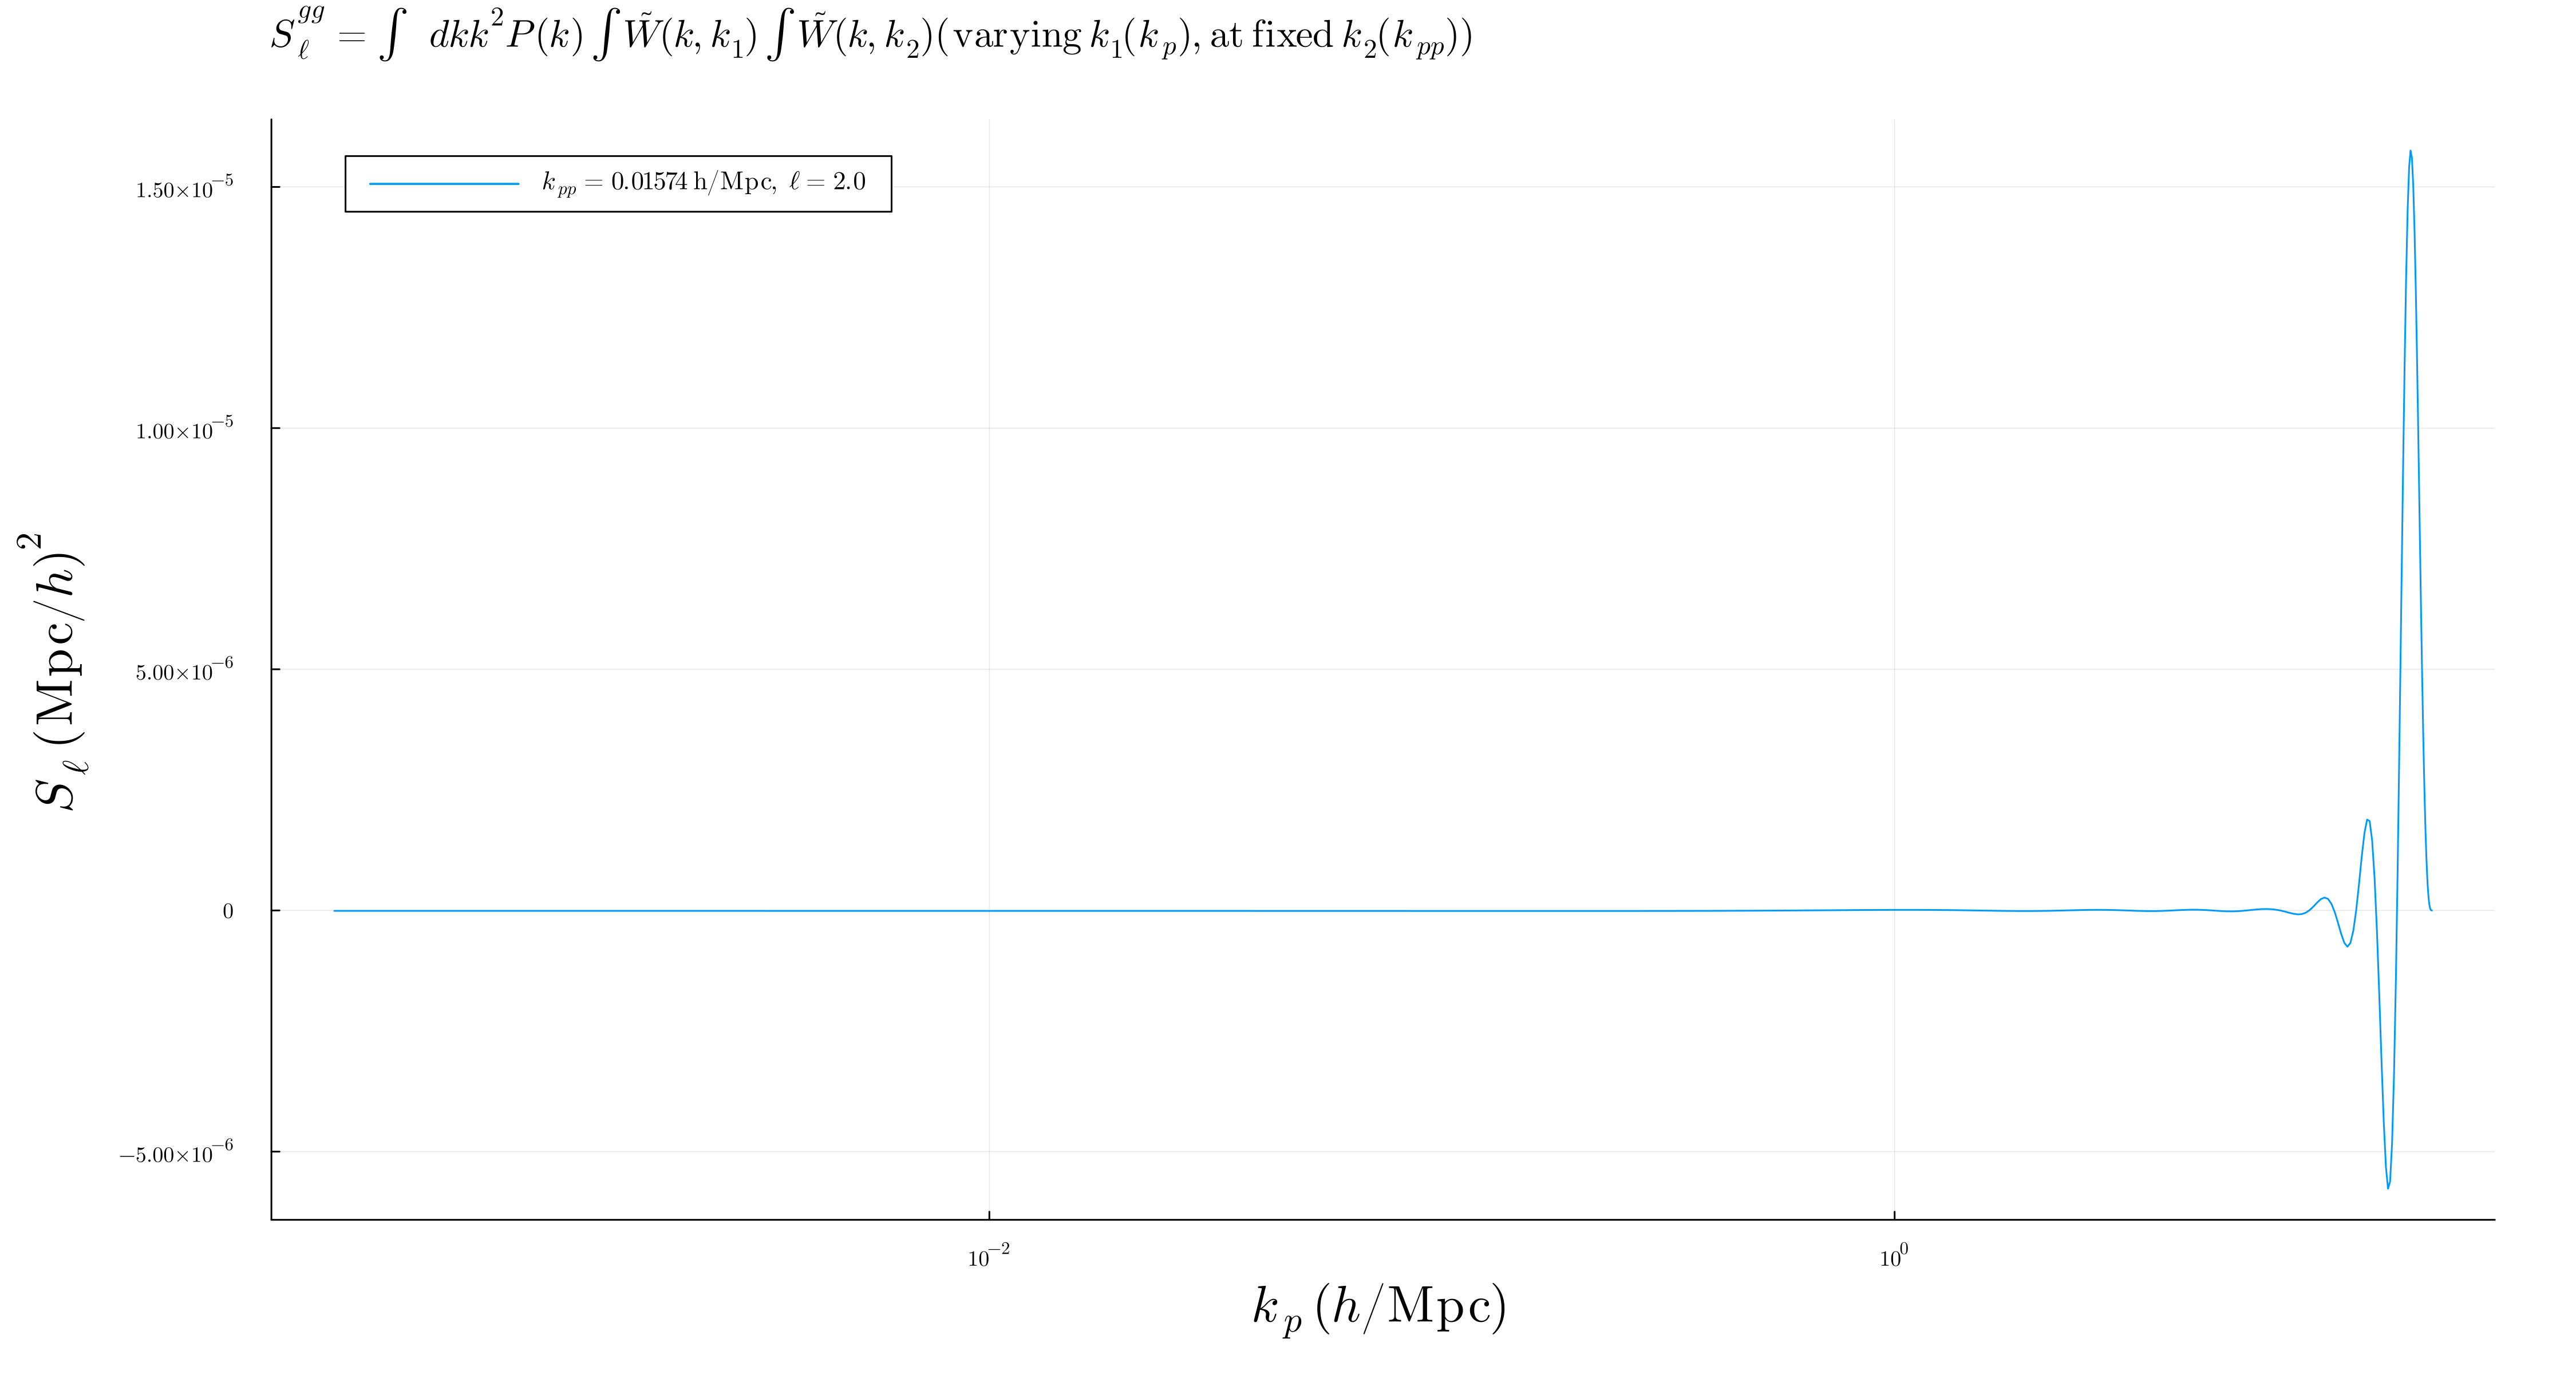

In [643]:
plt = plot()
il = 1
println("ℓ = ", grid_data.ℓ[il])
println("ℓ is fixed always")
ikpp = 147
println("k_1 (k_p) varies at each iteration")
println("k_2 (k_pp) = ", grids.kp_grid[ikpp] , " h/Mpc - fixed, stays there")
k_pp = grids.kp_grid[ikpp]
plot(sort(grids.k_grid), S_lkk_gg[:, ikpp, il], 
#color = plot_theme.colors[:],
label = L"k_{pp} = %$(round(k_pp, digits=5)) \; \mathrm{h/Mpc}, \; ℓ = %$(grid_data.ℓ[il])",
linestyle = :solid)
plot!(xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
      ylabel = L"S_\ell \; (\mathrm{Mpc}/h)^2"
      ,xscale = :log10
     )
plot!( title = L"S_\ell^{gg} = \int dk k^2 P(k) \int \tilde W(k, k_1) \int \tilde W(k, k_2) (\mathrm{varying} \; k_1 (k_p), \mathrm{at} \; \mathrm{fixed} \; k_2 (k_{pp}))",
      titlefontsize = 20,
      label = L"\ell=%$(grid_data.ℓ[il]), k_pp=%$(round(k_pp, digits=3)) \; \mathrm{h/Mpc}",
      titleposition = :left, labelfontsize = 20, labelposition = :topright,
      legendposition = :topleft, 
      size=plot_theme.size_Cl; plot_theme.shared_style...)

In [624]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/kpp_vs_Sl_idxell_$il"*"_kpp_$k_pp.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/Sl_plots/kpp_vs_Sl_idxell_2_kpp_15.369232368966493.png"

ℓ = 2.0
ℓ is fixed always
k_1 (k_p) varies at each iteration
k_2 (k_pp) is fixed at each iteration


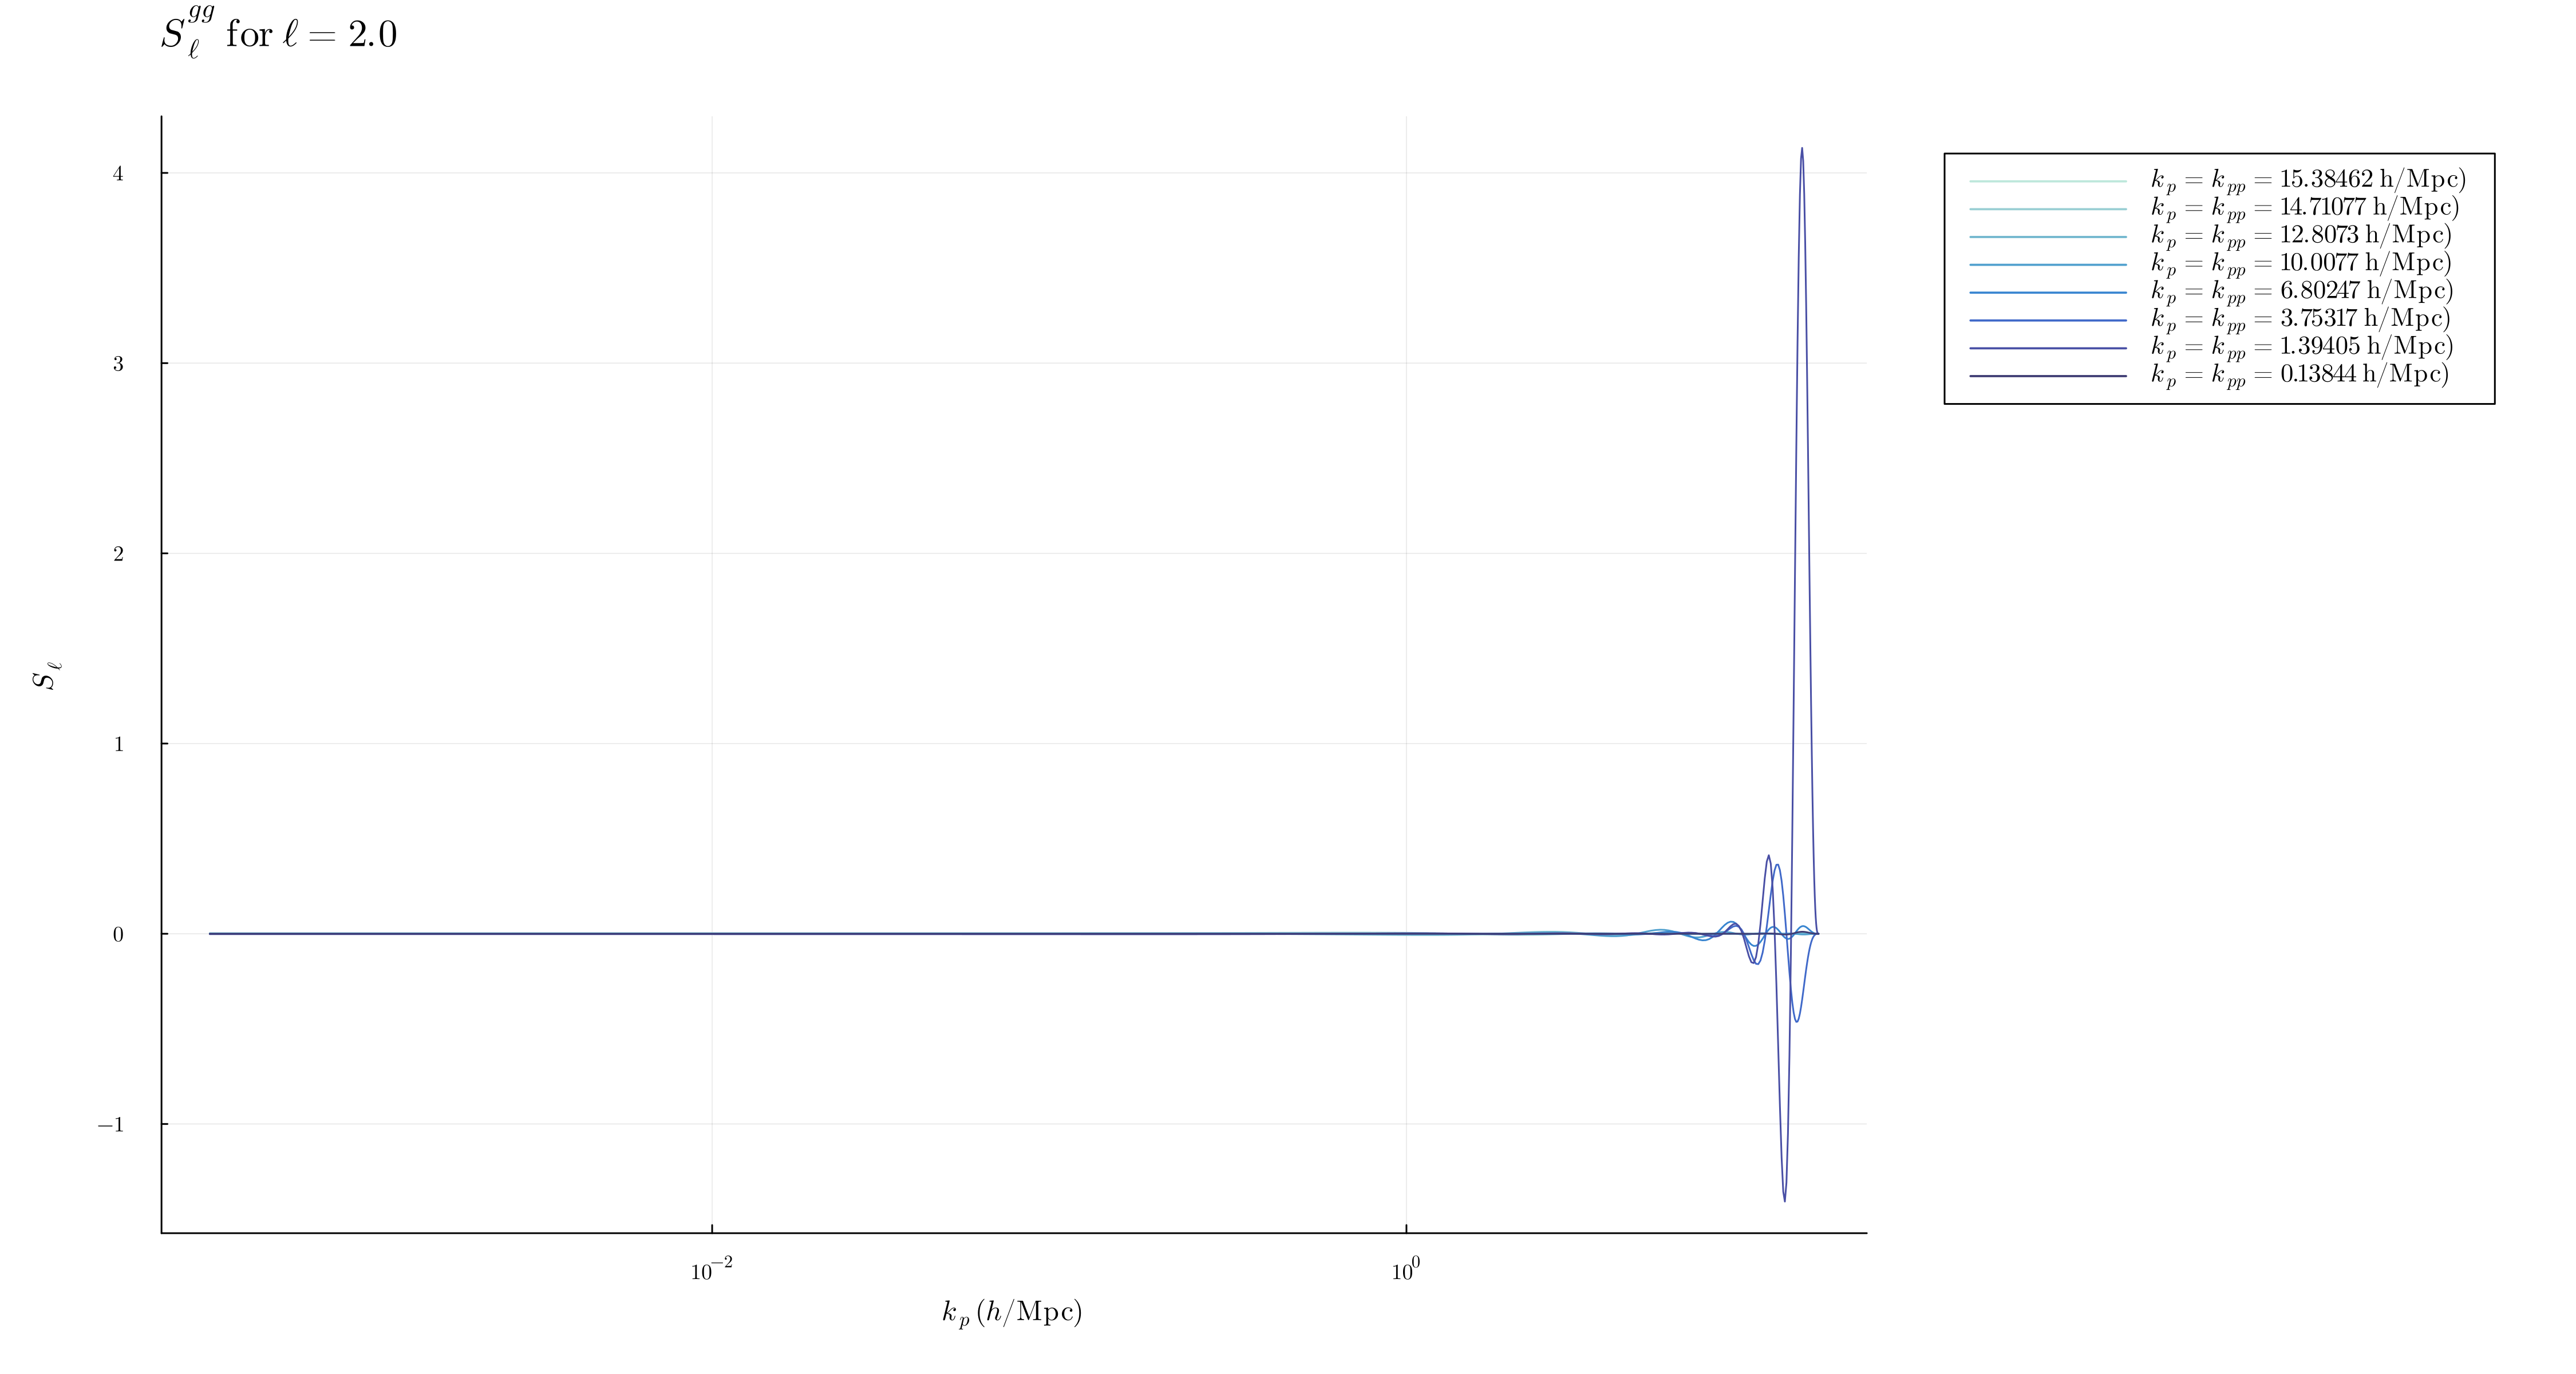

In [625]:
plt = plot()
il = 1
for ip in 1:grid_data.Nkp
    kp = grids.k_grid[ip]
    kpp = grids.kp_grid[ip]
end
println("ℓ = ", grid_data.ℓ[il])
println("ℓ is fixed always")
println("k_1 (k_p) varies at each iteration")
println("k_2 (k_pp) is fixed at each iteration")
for ip in 1:20:grid_data.Nkp
    color_palette = cgrad(:seaborn_icefire_gradient, grid_data.Nkp)
    kp = grids.k_grid[ip]
    kpp = grids.kp_grid[ip]
    plot!(sort(grids.k_grid), S_lkk_gg[:,ip,il], 
    color = color_palette[ip],
    label = L"k_p = k_{pp} = %$(round(kp, digits=5)) \; \mathrm{h/Mpc})",
    linestyle = :solid)
end
plot!(xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
      ylabel = L"S_\ell"
      ,xscale = :log10
      , label = ""
     )
plot!(title = L"S_\ell^{gg} \; \mathrm{for} \; \ell = %$(grid_data.ℓ[il])",
      legendposition = :outertopright, size = plot_theme.size_Cl, titlefontsize = 20, titleposition = :left; plot_theme.shared_style...)

In [626]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/kp_vs_Sl_idxell_$il"*"each_time_kpp_fixed.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/Sl_plots/kp_vs_Sl_idxell_1each_time_kpp_fixed.png"

ℓ = 2.0
ℓ is fixed always
k_1 (k_p) varies at each iteration
k_2 (k_pp) is fixed at each iteration


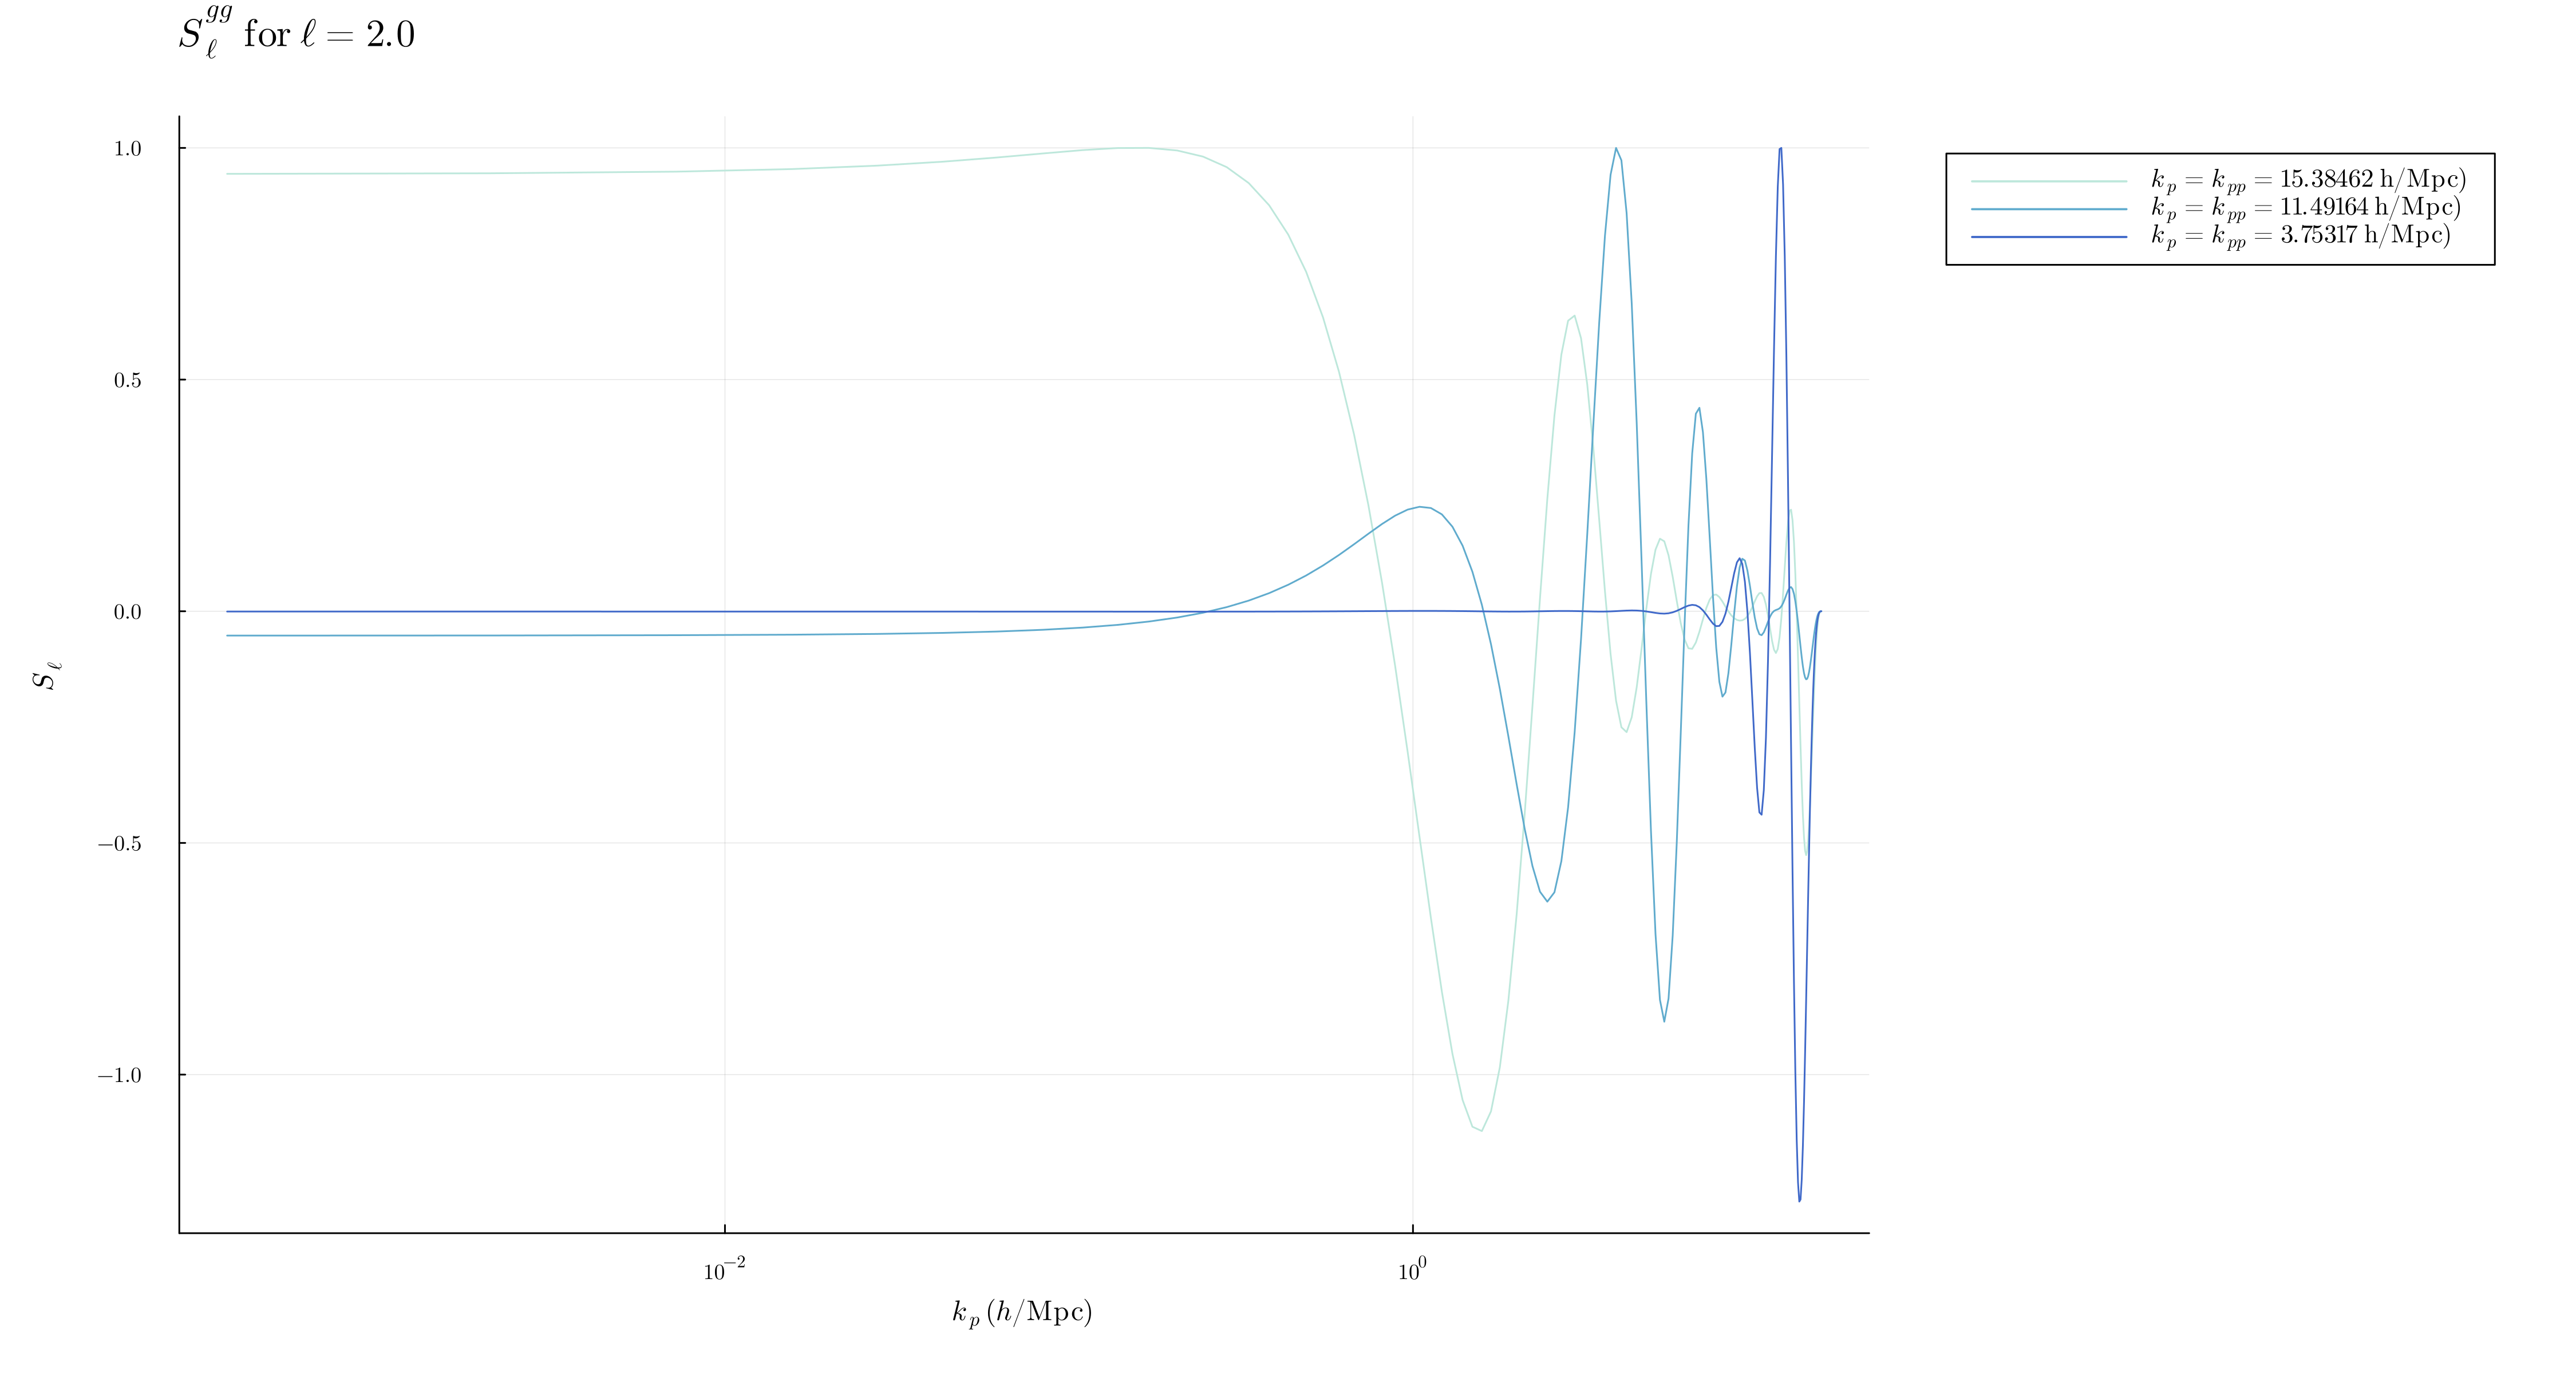

In [627]:
plt = plot()
il = 1
for ip in 1:grid_data.Nkp
    kp = grids.k_grid[ip]
    kpp = grids.kp_grid[ip]
end
println("ℓ = ", grid_data.ℓ[il])
println("ℓ is fixed always")
println("k_1 (k_p) varies at each iteration")
println("k_2 (k_pp) is fixed at each iteration")
for ip in 1:50:grid_data.Nkp
    color_palette = cgrad(:seaborn_icefire_gradient, grid_data.Nkp)
    kp = grids.k_grid[ip]
    kpp = grids.kp_grid[ip]
    plot!(sort(grids.k_grid), S_lkk_gg[:,ip,il]/maximum(S_lkk_gg[:,ip,il]), 
    color = color_palette[ip],
    label = L"k_p = k_{pp} = %$(round(kp, digits=5)) \; \mathrm{h/Mpc})",
    linestyle = :solid)
end
plot!(xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
      ylabel = L"S_\ell"
      ,xscale = :log10
      , label = ""
     )
plot!(title = L"S_\ell^{gg} \; \mathrm{for} \; \ell = %$(grid_data.ℓ[il])",
      legendposition = :outertopright, size = plot_theme.size_Cl, titlefontsize = 20, titleposition = :left; plot_theme.shared_style...)

In [628]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/kp_vs_Sl_idxell_$il"*"each_time_kpp_fixed_NORM.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/Sl_plots/kp_vs_Sl_idxell_1each_time_kpp_fixed_NORM.png"

[ Info: Saved animation to /Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/Sl_plots/kp_vs_Sl_idxell_1plot_evolution.gif


Plots.AnimatedGif("/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/Sl_plots/kp_vs_Sl_idxell_1plot_evolution.gif")
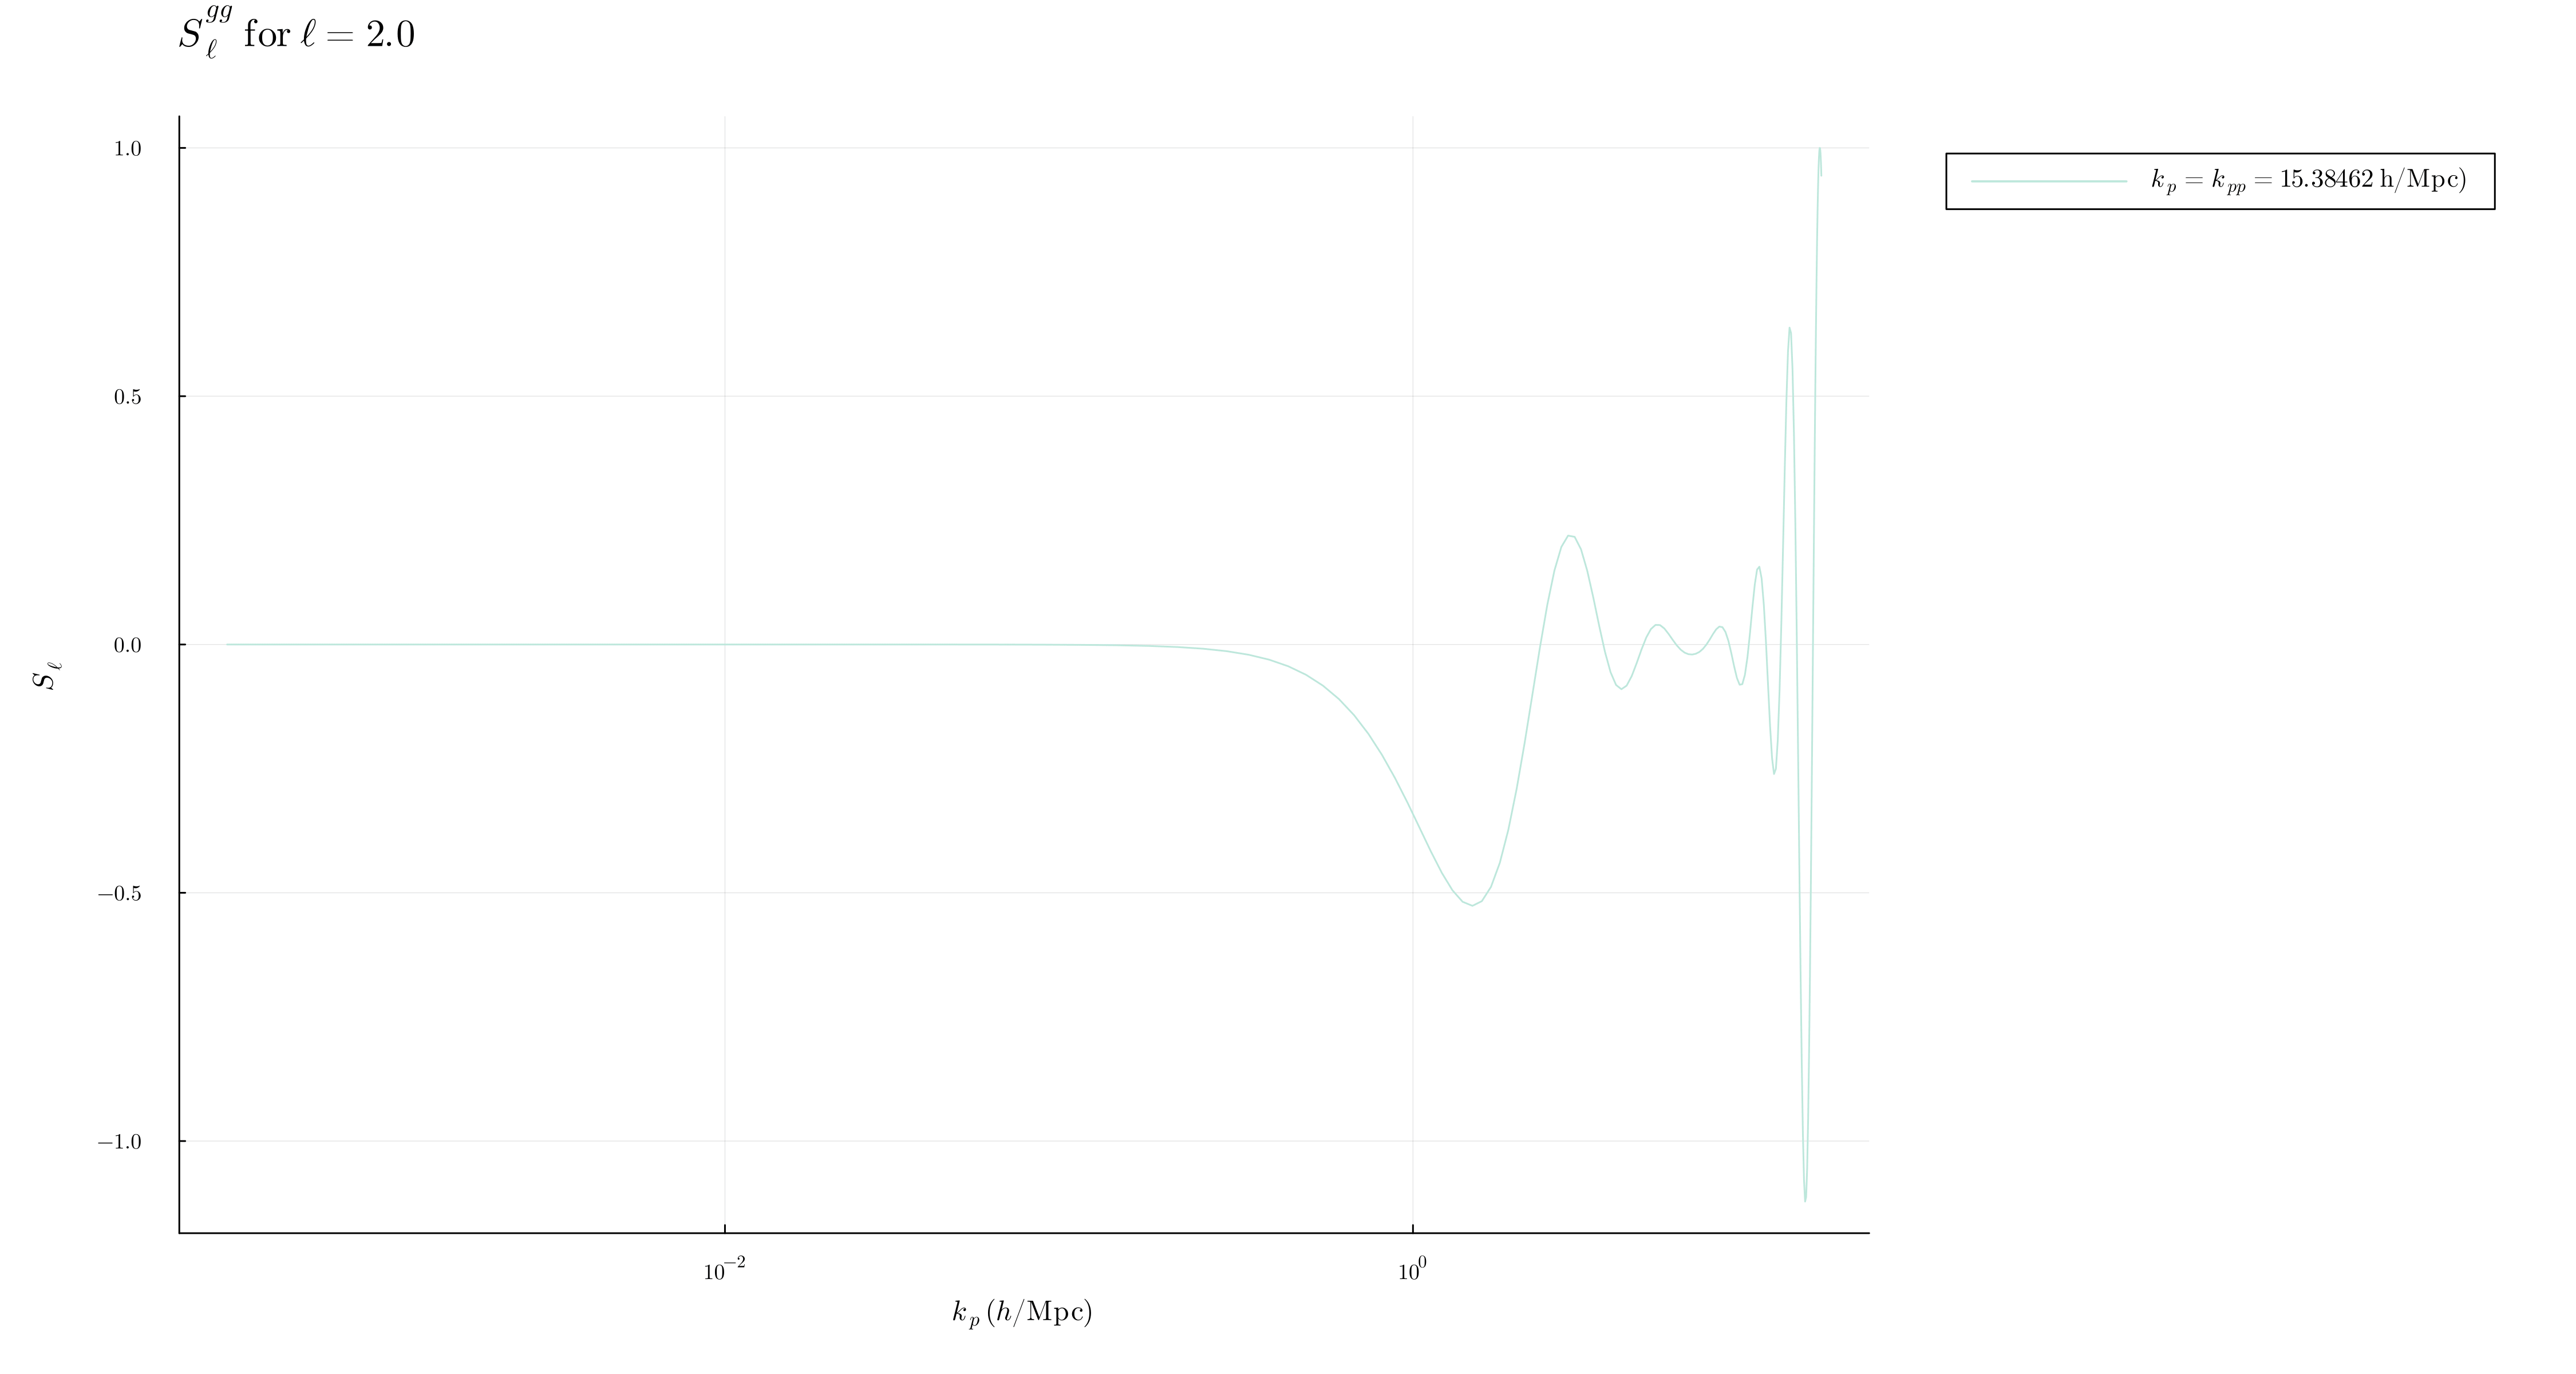

In [629]:
using Plots
plt = plot(
    xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
    ylabel = L"S_\ell",
    xscale = :log10,
    title = L"S_\ell^{gg} \; \mathrm{for} \; \ell = %$(grid_data.ℓ[il])",
    legendposition = :outertopright, 
    size = plot_theme.size_Cl, 
    titlefontsize = 20, 
    titleposition = :left; 
    plot_theme.shared_style...
)

color_palette = cgrad(:seaborn_icefire_gradient, grid_data.Nkp)

anim = @animate for ip in 1:10:grid_data.Nkp
    kp = grids.k_grid[ip]
    kpp = grids.kp_grid[ip]
    
    plot!(
        plt,
        grids.k_grid, 
        S_lkk_gg[:, ip, il] / maximum(S_lkk_gg[:, ip, il]), 
        color = color_palette[ip],
        label = L"k_p = k_{pp} = %$(round(kp, digits=5)) \; \mathrm{h/Mpc})",
        linestyle = :solid
    )
end

gif(anim, joinpath(paths.plot_subdir, "Sl_plots/kp_vs_Sl_idxell_$il"*"plot_evolution.gif"), fps = 1)

ℓ changes at each iteration
k_1 (k_p) varies at each iteration
k_2 (k_pp) is kept fixed for every iteration


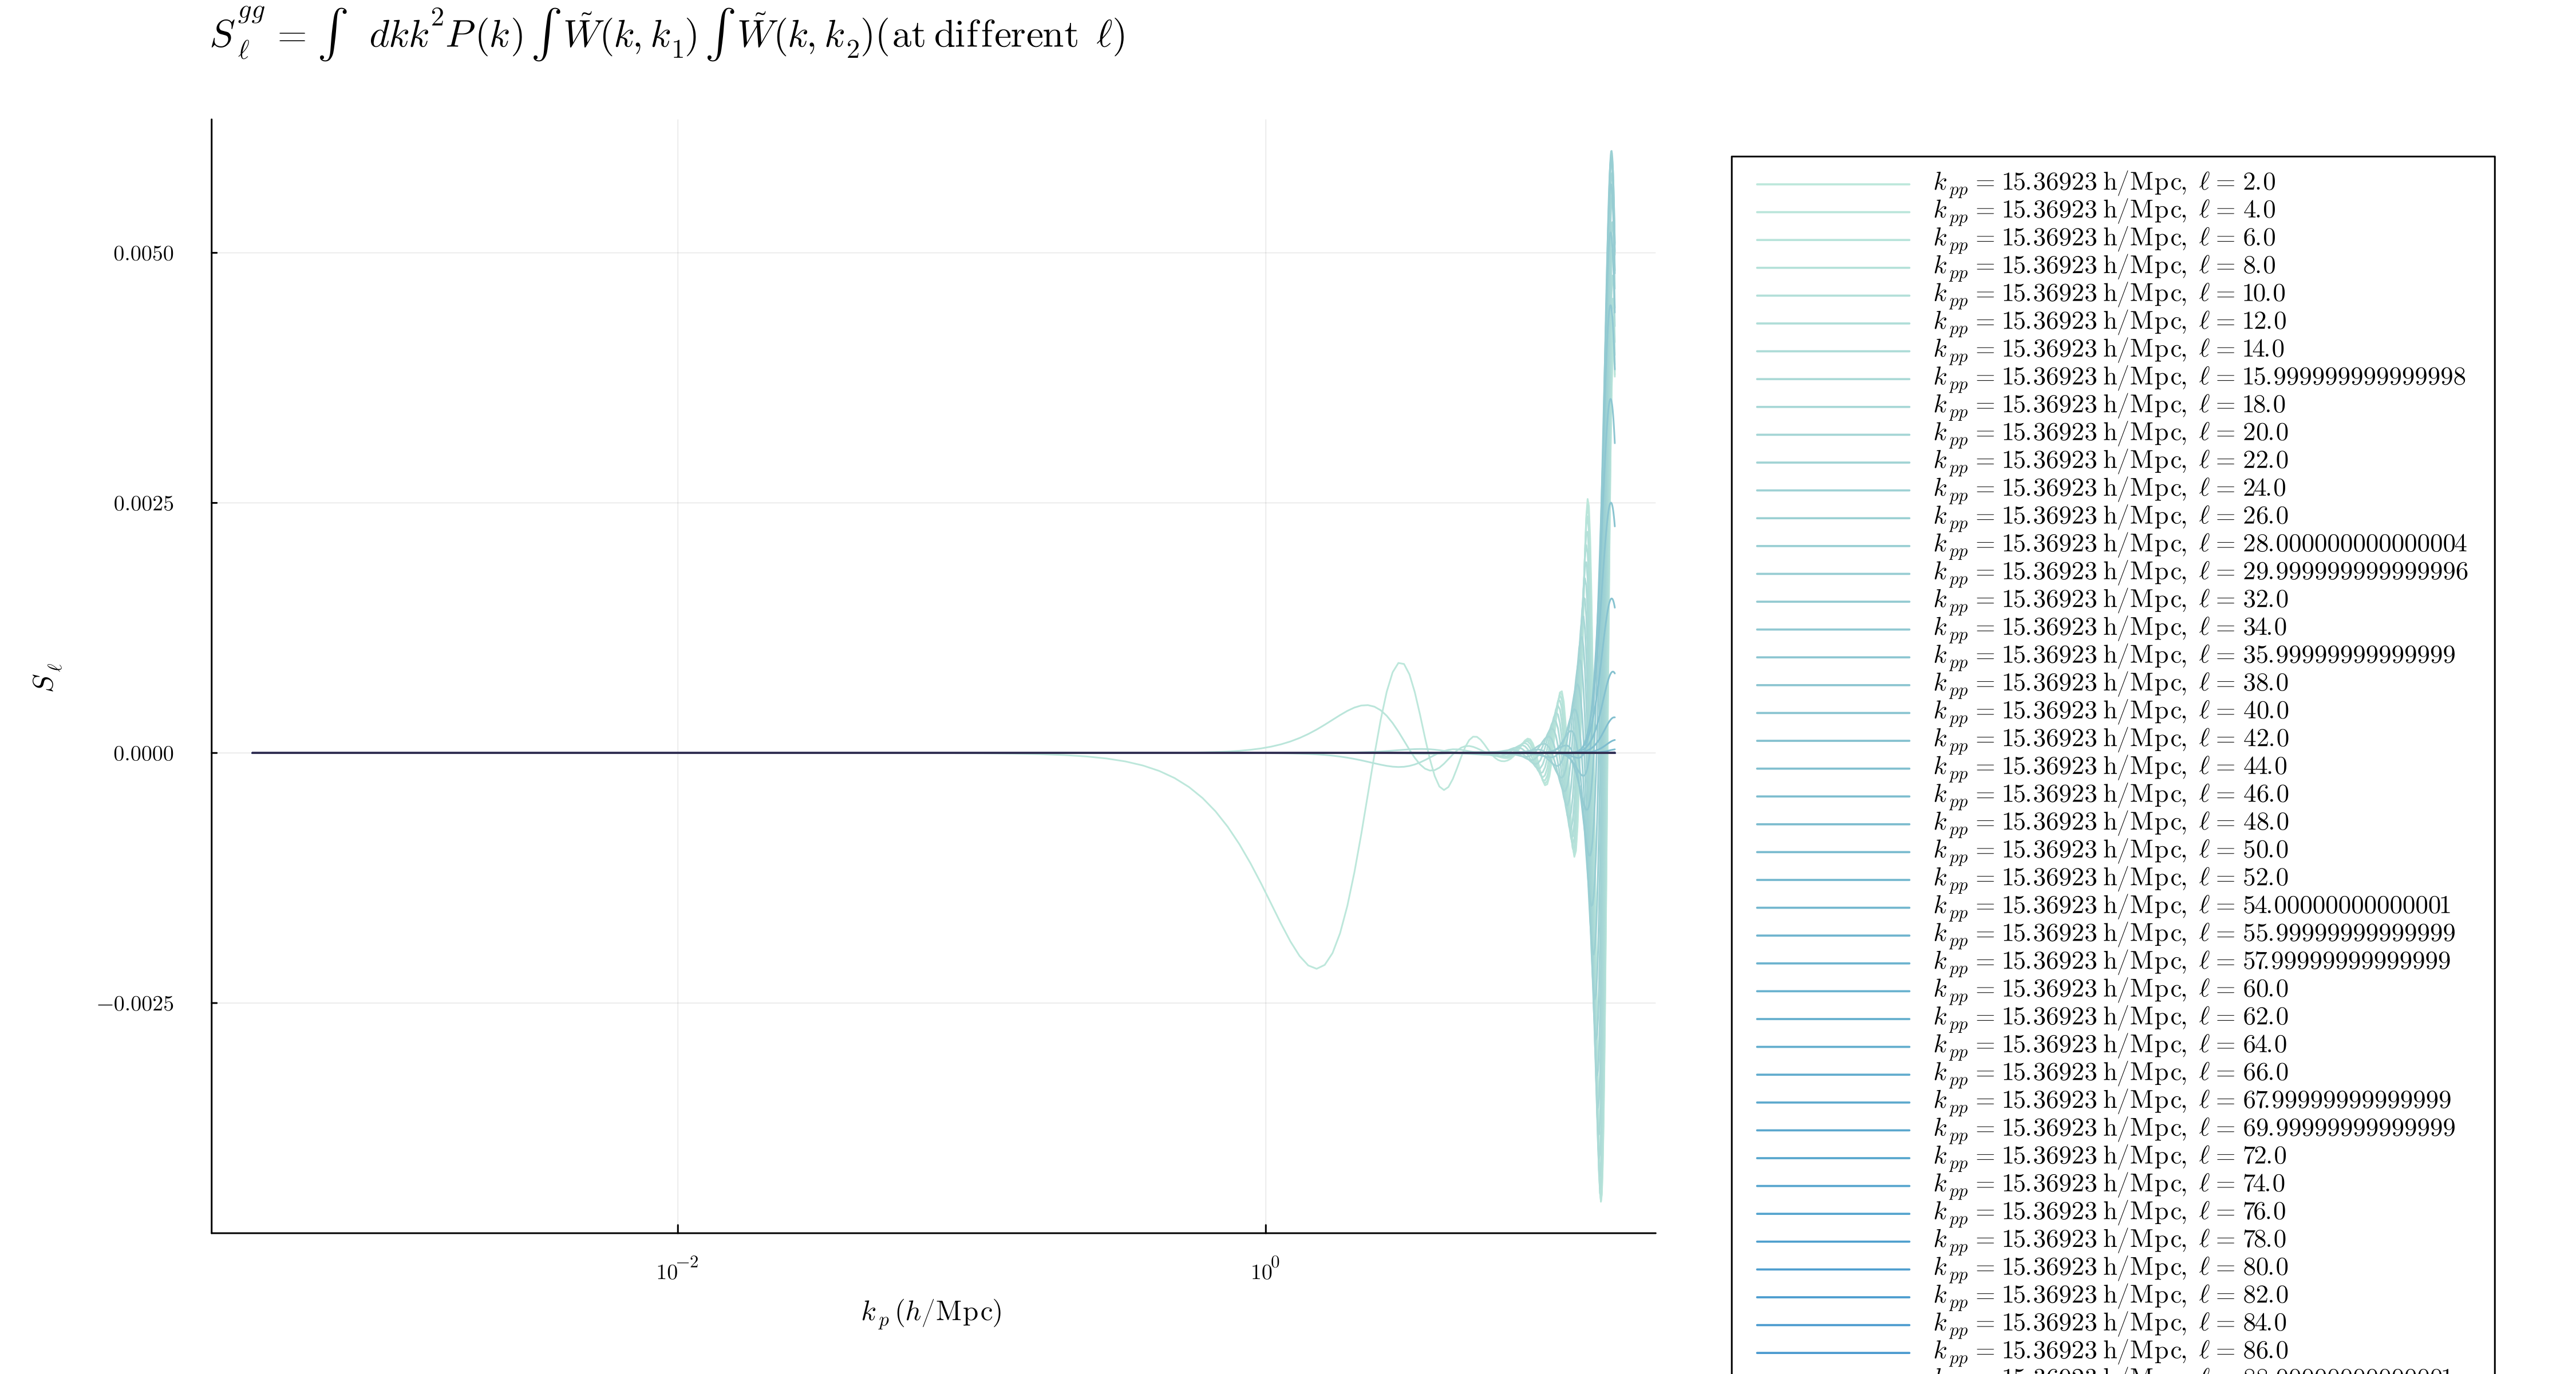

In [630]:
plt = plot()
ipp = 4
kpp = grids.kp_grid[ipp]
color_palette = cgrad(:seaborn_icefire_gradient, grid_data.ℓ) 
println("ℓ changes at each iteration")
println("k_1 (k_p) varies at each iteration")
println("k_2 (k_pp) is kept fixed for every iteration")
for il in 1:length(grid_data.ℓ)
    plot!(grids.kp_grid, S_lkk_gg[:,ipp,il],
    color = color_palette[il],
    label = L"k_{pp} = %$(round(kpp, digits=5)) \; \mathrm{h/Mpc}, \; ℓ = %$(grid_data.ℓ[il])",
    linestyle = :solid)
end
plot!(xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
      ylabel = L"S_\ell"
      ,xscale = :log10
     )
plot!( title = L"S_\ell^{gg} = \int dk k^2 P(k) \int \tilde W(k, k_1) \int \tilde W(k, k_2) (\mathrm{at} \; \mathrm{different} \; \; \ell )",
      titlefontsize = 20,
      titleposition = :left, legend = nothing,
      legendposition = :outertopright, 
      size=plot_theme.size_Cl; plot_theme.shared_style...)

In [631]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/kp_vs_Sl_kpp_$kpp"*"_loop_on_ell.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/Sl_plots/kp_vs_Sl_kpp_15.369232368966493_loop_on_ell.png"

ℓ changes at each iteration
k_1 (k_p) varies at each iteration
k_2 (k_pp) is kept fixed for every iteration


[ Info: Saved animation to /Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/Sl_plots/kpp_vs_Sl_idxell_loop_on_ℓ_kp_15.246537160242612.gif


Plots.AnimatedGif("/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/Sl_plots/kpp_vs_Sl_idxell_loop_on_ℓ_kp_15.246537160242612.gif")
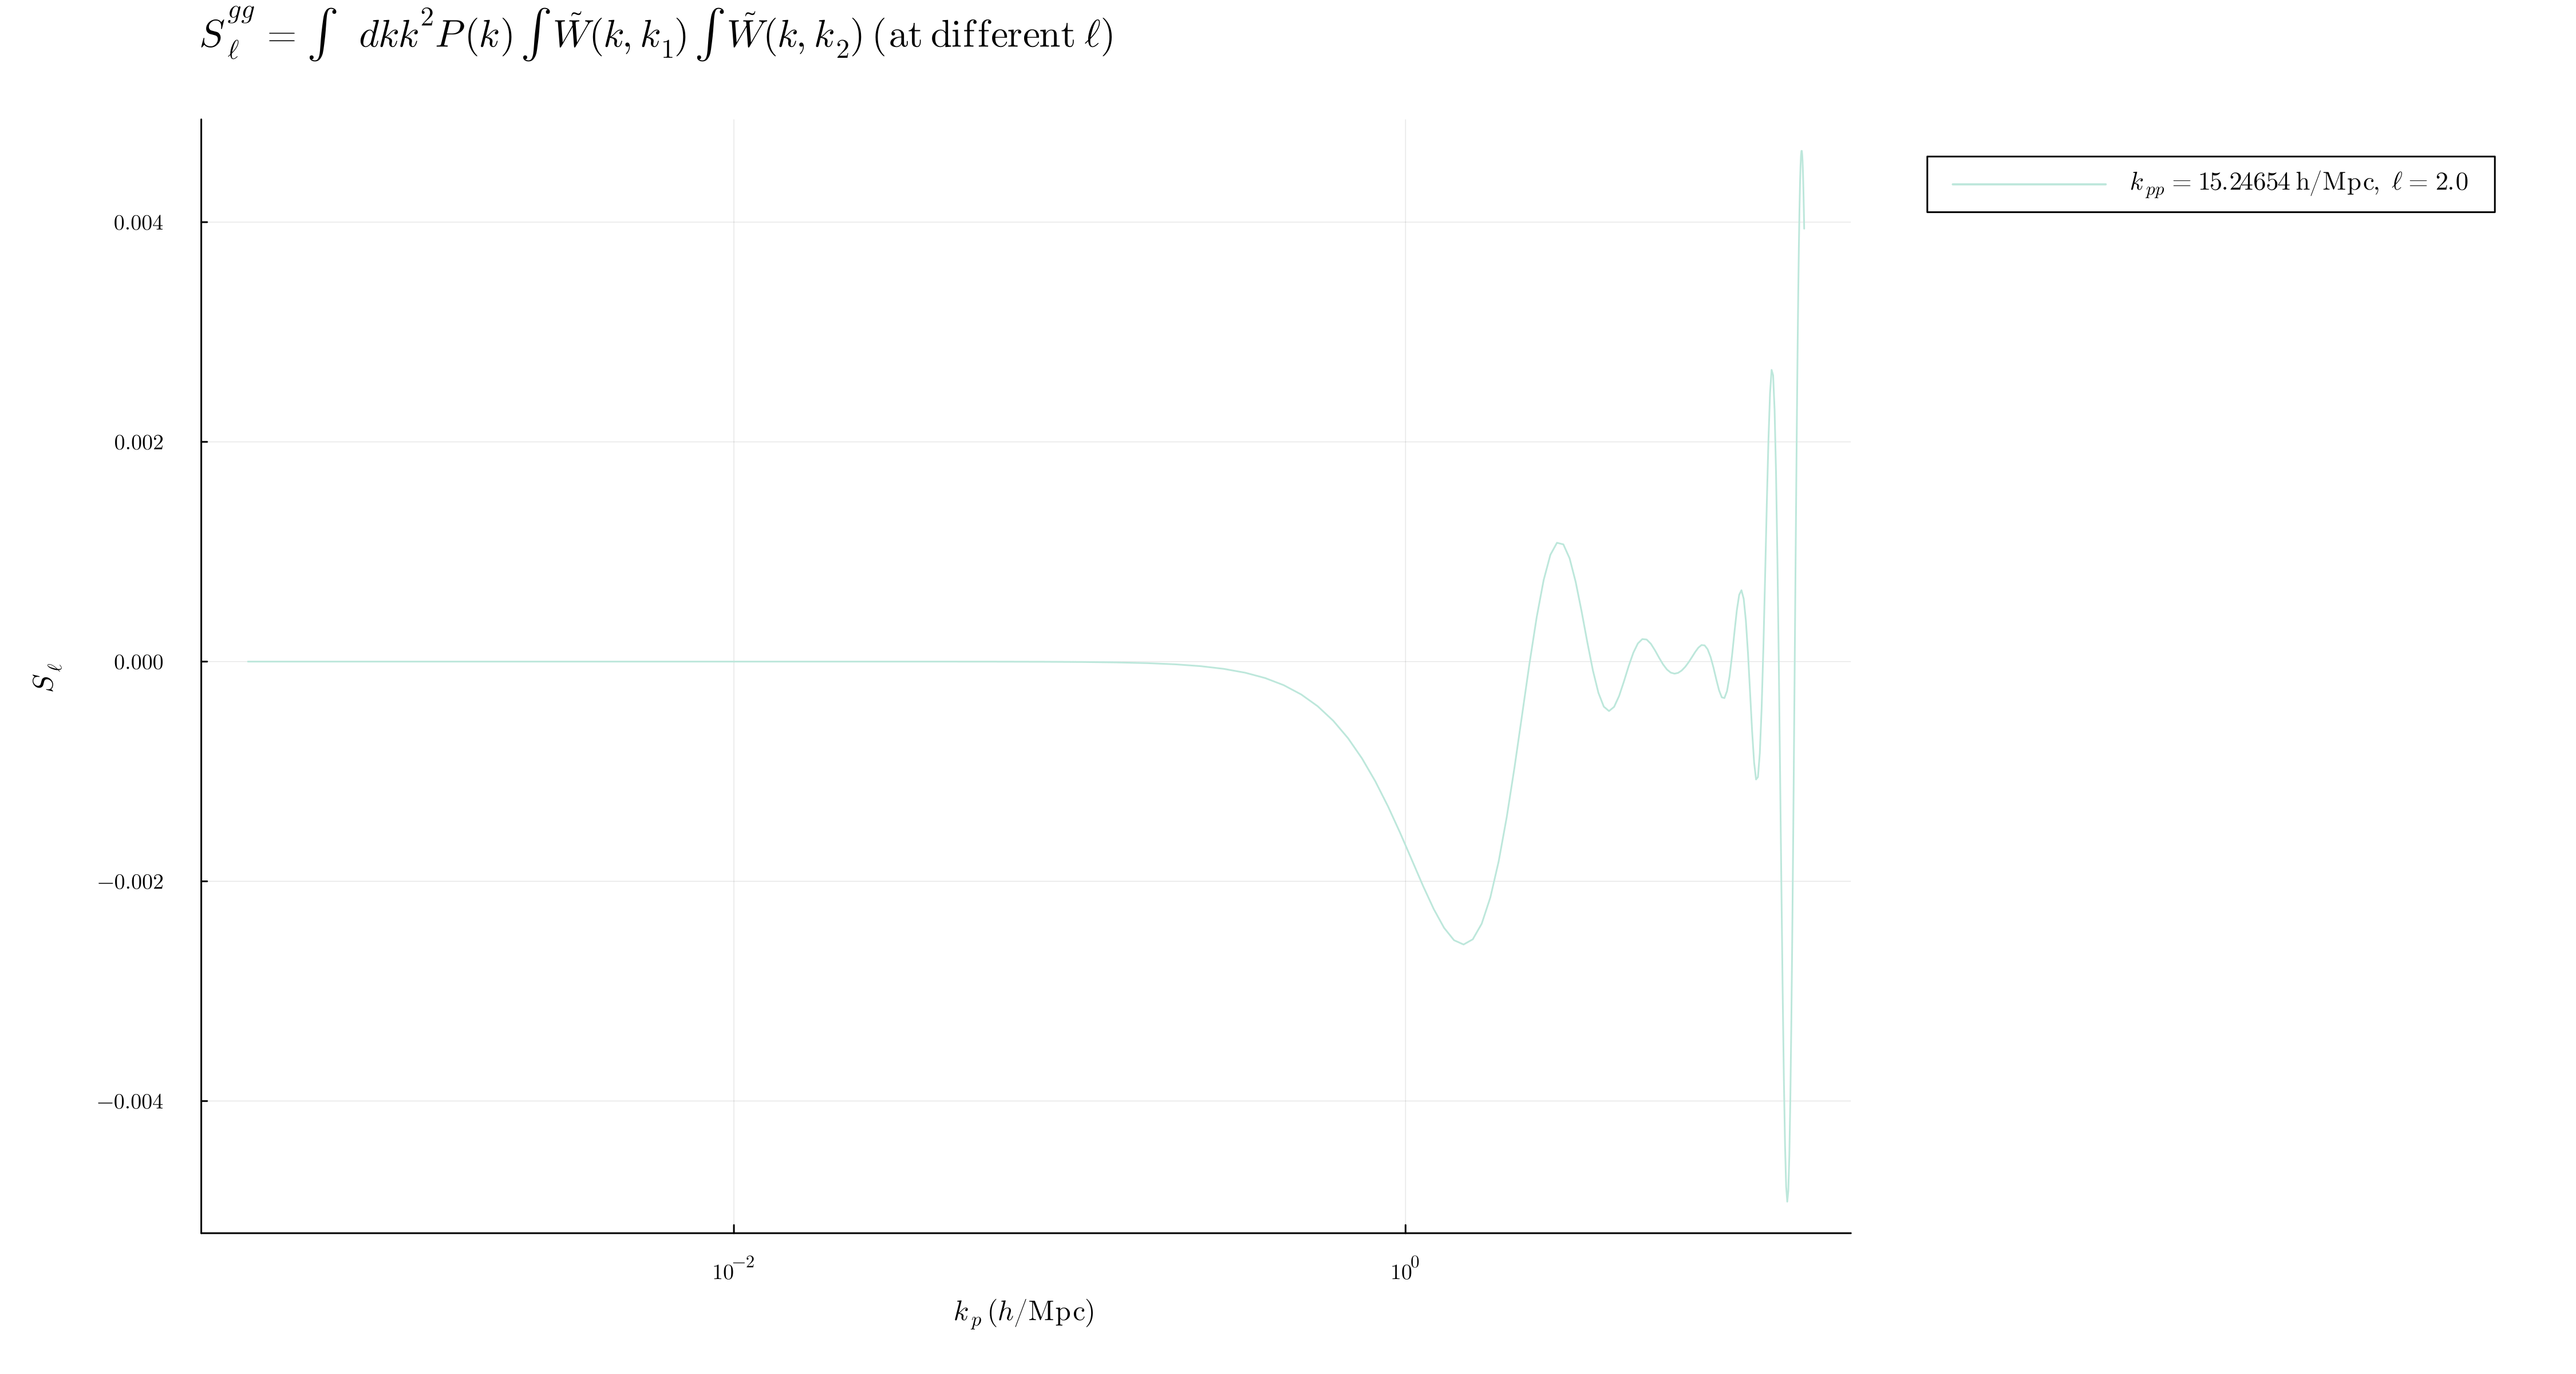

In [632]:
plt = plot(
    xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
    ylabel = L"S_\ell",
    xscale = :log10,
    title = L"S_\ell^{gg} = \int dk k^2 P(k) \int \tilde W(k, k_1) \int \tilde W(k, k_2) \; (\mathrm{at} \; \mathrm{different} \; \ell)",
    titlefontsize = 16,
    titleposition = :left, 
    legend = nothing,
    legendposition = :outertopright, 
    size = plot_theme.size_Cl; 
    plot_theme.shared_style...
)

ipp = 10
kpp = grids.kp_grid[ipp]
color_palette = cgrad(:seaborn_icefire_gradient, length(grid_data.ℓ)) 

println("ℓ changes at each iteration")
println("k_1 (k_p) varies at each iteration")
println("k_2 (k_pp) is kept fixed for every iteration")

anim = @animate for il in 1:10:length(grid_data.ℓ)
    plot!(
        plt,
        grids.kp_grid, 
        S_lkk_gg[:, ipp, il],
        color = color_palette[il], # Changed from [ipp] to [il] so colors actually transition
        label = L"k_{pp} = %$(round(kpp, digits=5)) \; \mathrm{h/Mpc}, \; ℓ = %$(grid_data.ℓ[il])",
        linestyle = :solid
    )
end

gif(anim, joinpath(paths.plot_subdir, "Sl_plots/kpp_vs_Sl_idxell_loop_on_ℓ_kp_$kpp"*".gif"), fps = 1)

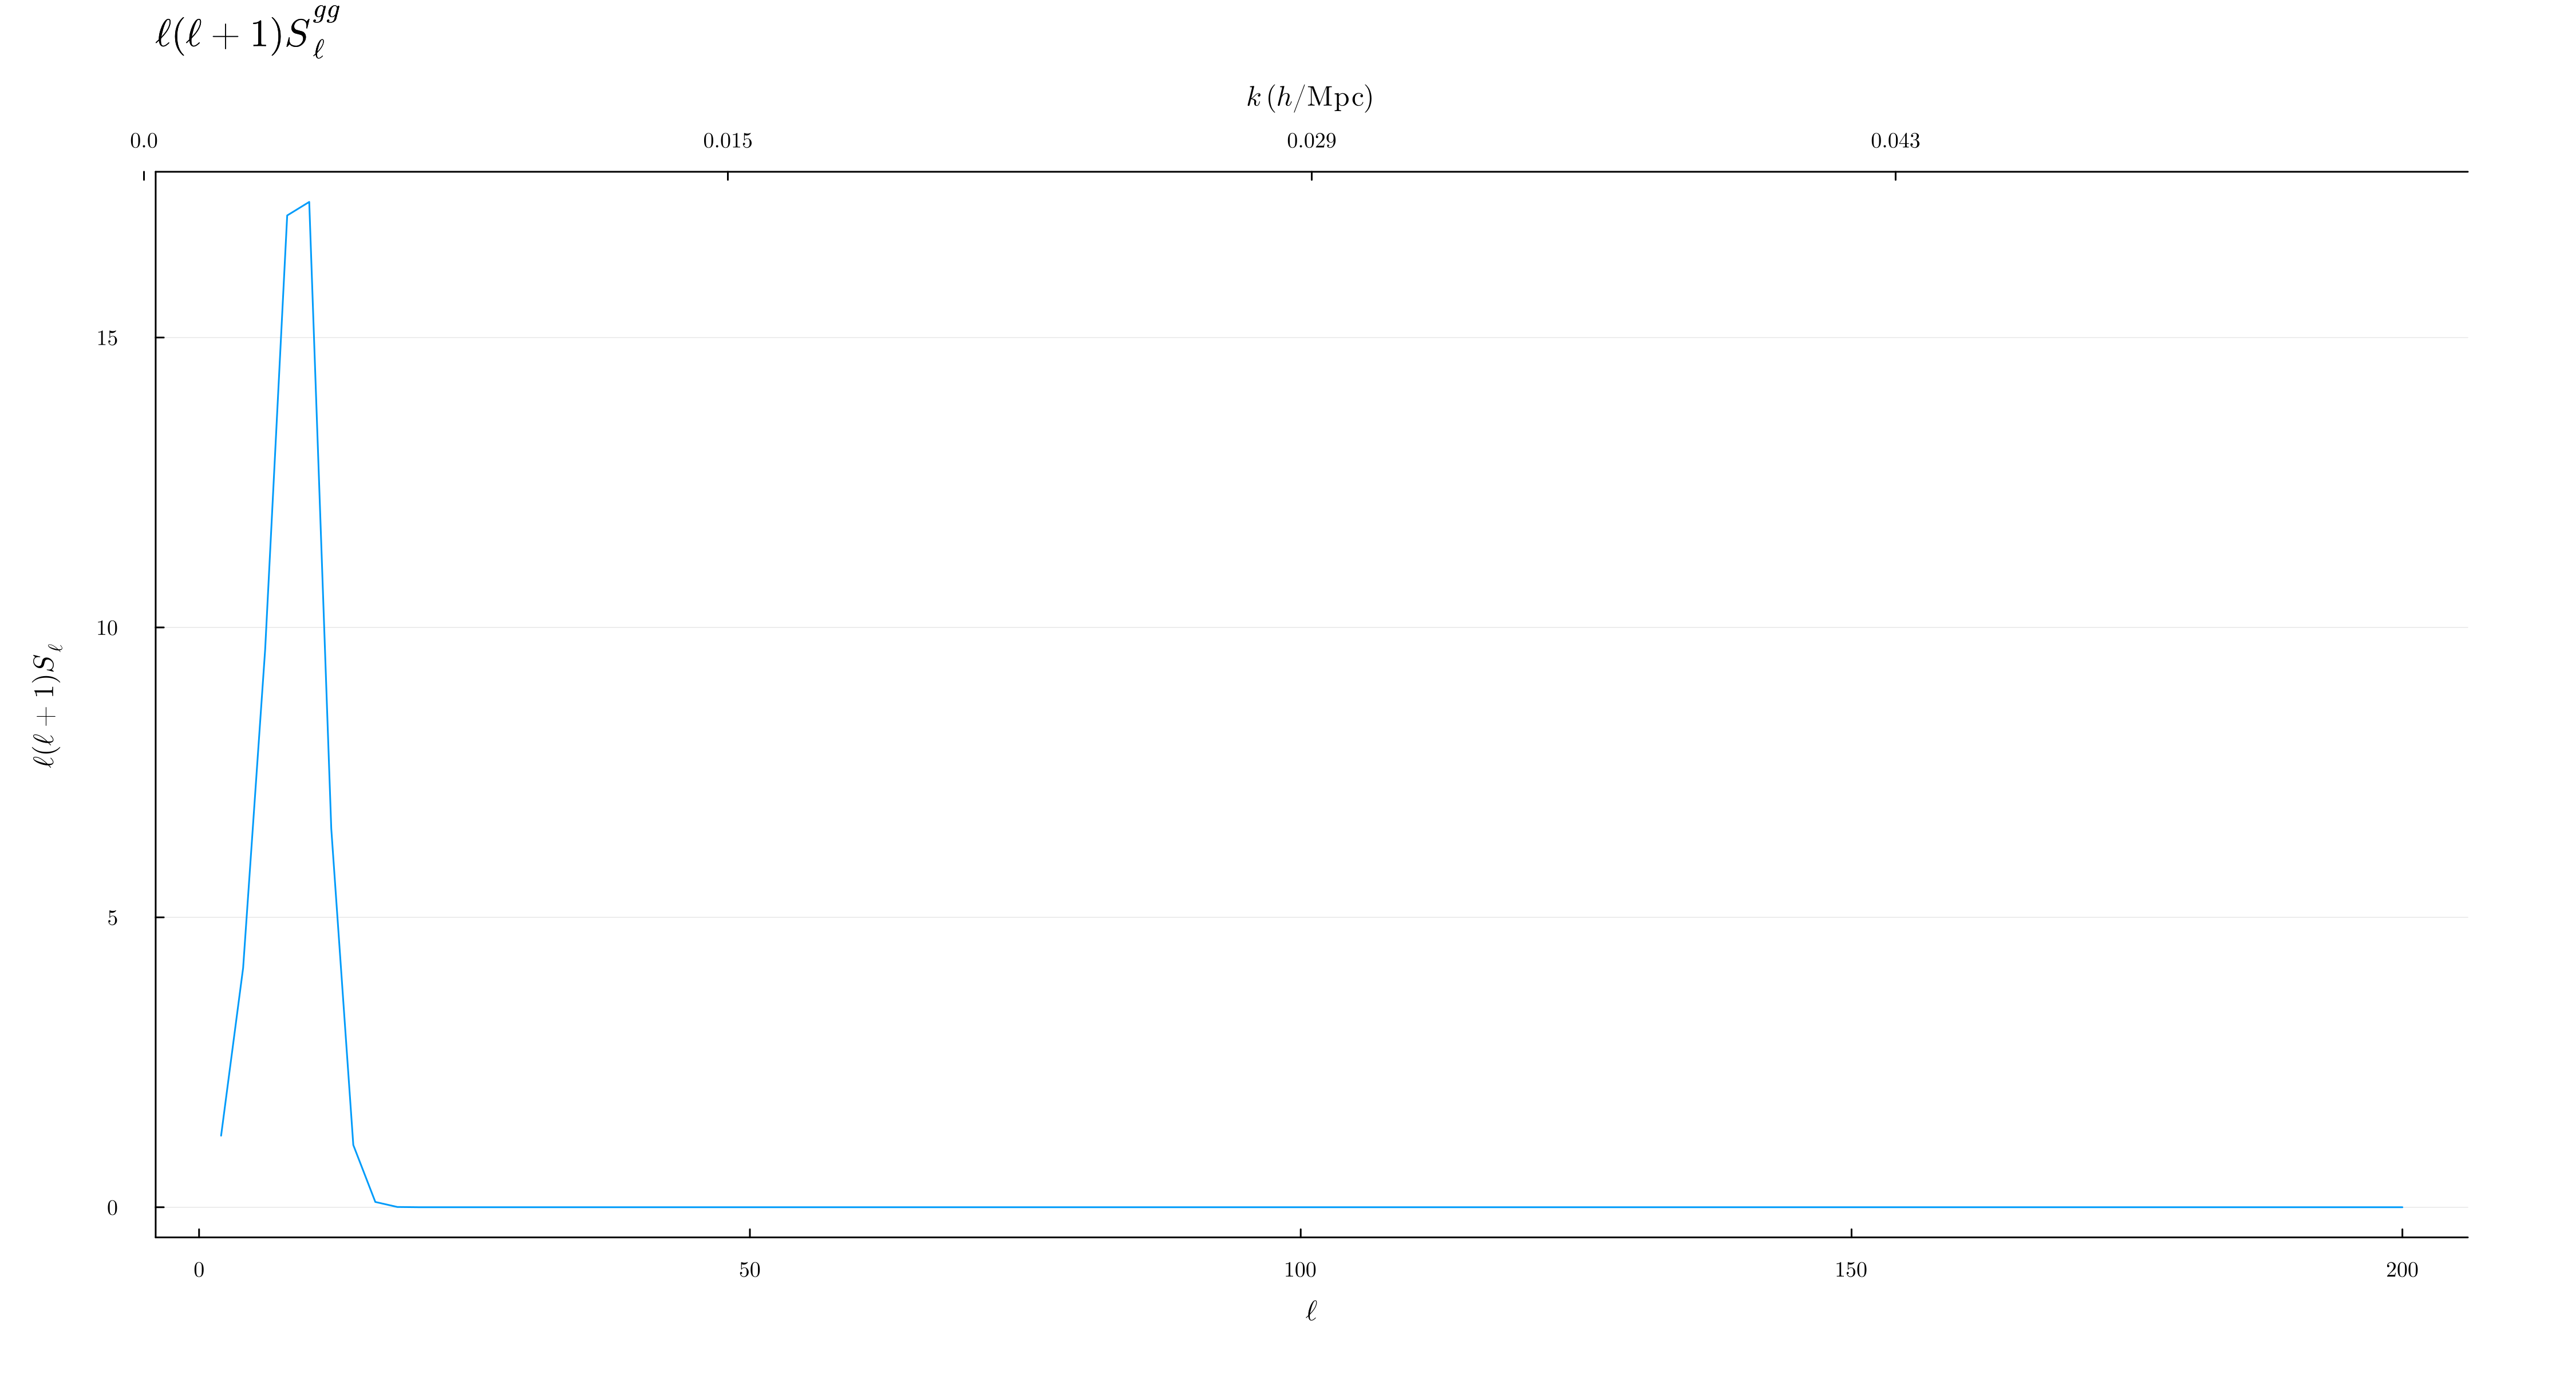

In [633]:
plt = plot()
ip = 95
ipp = 95
k_p = grids.k_grid[ip]
k_pp = grids.kp_grid[ipp]
plot(
    grid_data.ℓ,
    S_lkk_gg[ip, ipp, :] .* grid_data.ℓ .* (grid_data.ℓ .+ 1),
    xaxis = L"\ell",
    yaxis = L"\ell(\ell+1)S_\ell",
)

plot!(twiny(),
      xaxis = L"k \; (h/\mathrm{Mpc})",
      xticks = (ℓ_ticks, k_ticklabels),
      xlims = (minimum(grid_data.ℓ), maximum(grid_data.ℓ)),
      label = ""
     )

plot!(label = "Beyond BLAST", 
    legend = false, colorbar = true, colorbar_title = L"j", clims = (1, grid_data.Nkp),
    title = L"\ell(\ell+1)S_\ell^{gg}",
    size=plot_theme.size_Cl, titlefontsize=20, 
    titleposition = :left;
    plot_theme.shared_style...
    )

In [634]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/ell_vs_Sl_kp_kpp_$k_p"*"_"*"$k_pp.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_132207/plots/Sl_plots/ell_vs_Sl_kp_kpp_4.618234947440806_4.618234947440806.png"

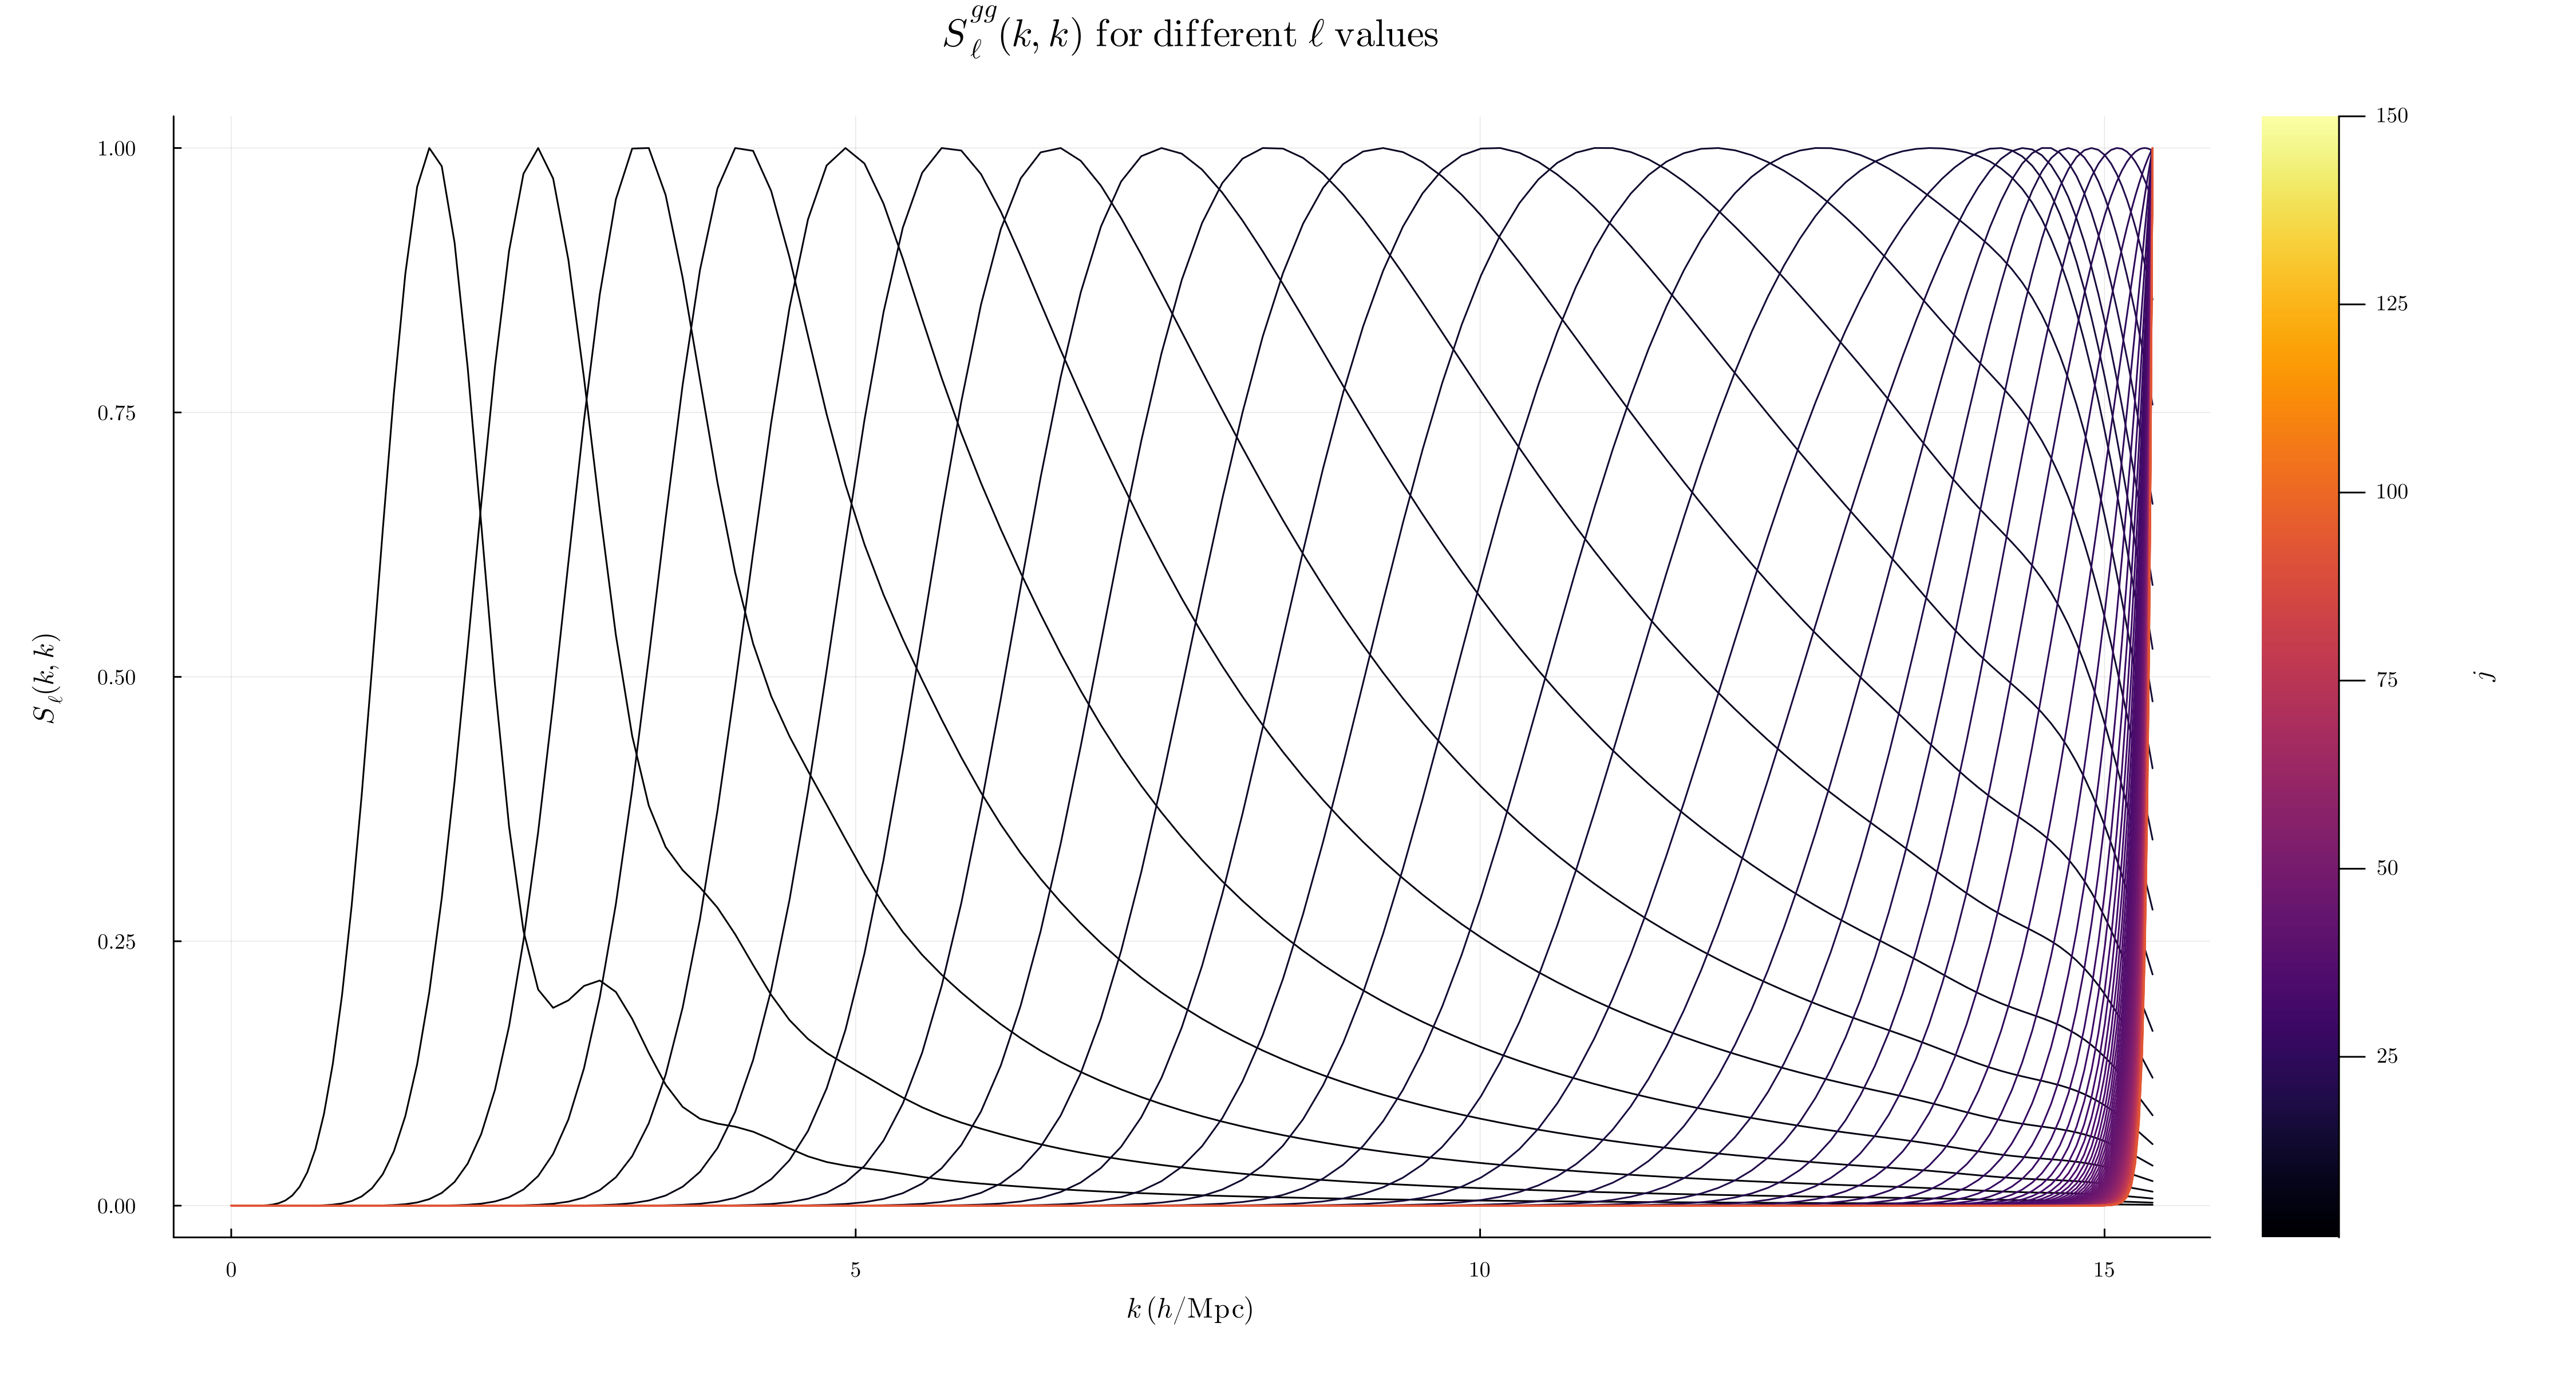

In [635]:
diagS = [diag(S_lkk_gg[:, :, i]) for i in 1:size(S_lkk_gg, 3)]

nshow = 100
idx = round.(Int, range(1, size(S_lkk_gg, 3), length=nshow))

p = plot(
    xlabel = L"k \; (h/\mathrm{Mpc})",
    ylabel = L"S_\ell(k,k)",
    title  = L"S_\ell^{gg}(k,k)\ \mathrm{for\ different}\ \ell\ \mathrm{values}",
    colorbar_title = L"j",
    clims = (1, grid_data.Nkp),                   
    legend = false,
    colorbar = true,
    lw = 2,
    size=plot_theme.size_Cl; 
    plot_theme.shared_style...
)
colors = cgrad(:seaborn_icefire_gradient, nshow)
for ii in idx
    plot!(p, grids.kp_grid, diagS[ii]/maximum(diagS[ii]), line_z = ii, 
    color = colors[ii],;
        label = L"\ell = %$(grid_data.ℓ[ii])")
end

p

In [636]:
println(grids.k_grid[147])
println(grid_data.ℓ[2])

println(S_lkk_gg[5,5,2])
println(S_lkk_gg[146,146,2])

0.01574015850603505
4.0
0.0038956736439645693
4.220487384865793e-18
